# 🏗️ Arquitetura de Benchmarking Multimodal: Frente 8 (Sistemas Híbridos e Deep Generative Learning)

O objetivo desta seção é executar o processo de benchmarking para a detecção de anomalias acústicas. Esta arquitetura evoluiu para o **Cenário 2 (Edição Avançada)**, integrando baselines estatísticos, redes sequenciais profundas e modelos generativos para cobrir as lacunas de detecção em ambientes industriais complexos.

## 🛡️ 1. Pré-processamento e Saneamento Digital (DSP)
* **Filtro HHT + UKF (Unscented Kalman Filter):** Aplicação de Decomposição em Modos Empíricos (EMD) aliada à filtragem não-linear de Kalman para isolar assinaturas mecânicas puras, mitigando ruídos não-estacionários.
* **Protocolo de Split Industrial (Frente 6):** Separação rigorosa de treino e teste baseada no **ID do arquivo (Grouped Split)**, garantindo que janelas de um mesmo áudio nunca vazem entre os conjuntos (**Zero Data Leakage**).

## 🔬 2. Feature Engineering: Os 6 Experimentos de Extração
Os sinais são processados através de seis frentes analíticas para alimentar diferentes famílias de modelos:
* **Exp 1 (Mel + RPCA):** Foco em componentes esparsas de anomalia via matrizes de imagem.
* **Exp 2 (MFCC Dinâmico):** Captura timbre e aceleração sonora (Delta/Delta-Delta).
* **Exp 3 (CWT + RPCA):** Transformada de Wavelet para detecção de transientes ultrarrápidos.
* **Exp 4 (Híbrido Clássico):** Fusão de dados esparsos, dinâmicos e métricas físicas (RMS, Kurtosis, Skewness).
* **Exp 5 (Híbrido Avançado + NMF):** Modelagem aditiva para mensurar a incerteza de reconstrução acústica.
* **Exp 6 (STFT Log 64x64):** Leitura espectral bruta e redimensionada para comparação direta de resolução.

## 🛰️ 3. Outlier Exposure (OE) & Calibração (Frente 7)
* **Reforço de Fronteira:** Uso de **Pseudo-Anomalias (Mixup)** e exposição a ruídos externos reais (DCASE) para treinar os modelos contra dados fora de distribuição.
* **Limiar Estatístico (Gamma):** Calibração automatizada do limiar de decisão baseada na distribuição Gamma dos scores normais, visando o controle estrito de alarmes falsos (FPR Alvo).

## ⚙️ 4. Super Loop de Benchmarking Competitivo (Frente 8)
Avaliação comparativa entre quatro categorias de modelos:
1. **Supervisionados:** XGBoost e GRU (Redes Recorrentes).
2. **Baselines Leves:** Isolation Forest e Distância de Mahalanobis (Baixo custo computacional).
3. **Deep Autoencoders:** Tiny-AST (Transformadores) e **LSTM-AE** (Reconstrução temporal).
4. **Generativos:** **VAE (Variational Autoencoder)** para modelagem probabilística da normalidade.

---
**Objetivo Final:** Gerar o `df_bench` para identificar o modelo com o melhor **Score DCASE Proxy** (equilíbrio entre AUC e pAUC), priorizando a segurança do ativo (Recall) sem comprometer a eficiência operacional (Baixo Falso Positivo).

In [4]:
# 1. Instalação 100% Silenciosa
!pip install -q librosa xgboost seaborn EMD-signal pywavelets filterpy > /dev/null 2>&1
!pip install -q "dill<0.3.9" "multiprocess<0.70.17" > /dev/null 2>&1

# 2. Importação do Ecossistema Matemático e de IA
import gc
import os
import time
import pywt
import torch
import shutil
import joblib
import librosa
import zipfile
import warnings
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
from PyEMD import EMD
import torch.nn as nn
from tqdm import tqdm
import librosa.display
from pathlib import Path
import scipy.stats as stats
import torch.optim as optim
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
import torch.nn.functional as F
from matplotlib.patches import Rectangle
from xgboost import XGBClassifier
from scipy.stats import kurtosis, skew
from torch.utils.data import DataLoader, TensorDataset
from filterpy.kalman import MerweScaledSigmaPoints, UnscentedKalmanFilter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.decomposition import NMF
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

# 3. Importação Específica do Filtro Anti-Ruído (HHT)
from PyEMD import EMD

# 4. Configurações Globais do Notebook
warnings.filterwarnings('ignore')
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="deep")

CPU_THREADS = max(1, (os.cpu_count() or 2) - 1)
torch.set_num_threads(CPU_THREADS)

print("✅ Ambiente local/Colab configurado com sucesso!")
print(f"🧠 Threads de CPU disponíveis para treino: {CPU_THREADS}")
print(f"☁️ Execução em Colab: {IN_COLAB}")


✅ Ambiente local/Colab configurado com sucesso!
🧠 Threads de CPU disponíveis para treino: 1
☁️ Execução em Colab: True


## 1 - Dataset de rolamentos (Kaggle) para treino e validação e os arquivos coletados por nós para o **teste final.**

In [5]:
# 1. Configuração híbrida: Colab ou máquina local
print("🔐 Configurando origem dos dados...")

def get_total_ram_gb():
    try:
        page_size = os.sysconf("SC_PAGE_SIZE")
        phys_pages = os.sysconf("SC_PHYS_PAGES")
        return max(1, round((page_size * phys_pages) / (1024 ** 3)))
    except (ValueError, OSError, AttributeError):
        return 8

TOTAL_RAM_GB = get_total_ram_gb()

if IN_COLAB:
    drive.mount('/content/drive', force_remount=True)
    ROOT_PROJETO = Path('/content/drive/MyDrive/PROJETO APLICADO - Acoustic Anomaly Detection (AAD)/Arquivos de audio')
    EXTRACT_PATH = Path('/content/kaggle_data')
else:
    ROOT_PROJETO = Path(os.getenv('AAD_ROOT', str(Path.cwd()))).expanduser()
    EXTRACT_PATH = Path(os.getenv('AAD_EXTRACT_PATH', str(ROOT_PROJETO / 'kaggle_data'))).expanduser()

PATH_KAGGLE_ZIP = Path(os.getenv('AAD_KAGGLE_ZIP', str(ROOT_PROJETO / 'archive.zip'))).expanduser()
TEST_DIR = Path(os.getenv('AAD_TEST_DIR', str(ROOT_PROJETO / 'teste'))).expanduser()
SR_TARGET = 10000

default_limit = 120 if TOTAL_RAM_GB <= 8 else 250 if TOTAL_RAM_GB <= 16 else 400
MAX_SAMPLES_PER_CLASS = int(os.getenv('AAD_MAX_SAMPLES_PER_CLASS', str(default_limit)))

oe_default_max_files = 40 if TOTAL_RAM_GB <= 8 else 80 if TOTAL_RAM_GB <= 16 else 160
oe_default_max_windows = 256 if TOTAL_RAM_GB <= 8 else 640 if TOTAL_RAM_GB <= 16 else 1200
oe_default_max_per_group = 8 if TOTAL_RAM_GB <= 8 else 12 if TOTAL_RAM_GB <= 16 else 20

OE_REAL_DIRS = [Path(item.strip()).expanduser() for item in os.getenv('AAD_OE_DIRS', '').split(',') if item.strip()]
OE_REAL_DCASE_ROOTS = [Path(item.strip()).expanduser() for item in os.getenv('AAD_OE_DCASE_ROOTS', '').split(',') if item.strip()]
OE_REAL_ENABLED = os.getenv('AAD_OE_ENABLED', '1' if (OE_REAL_DIRS or OE_REAL_DCASE_ROOTS) else '0').strip().lower() in {'1', 'true', 'yes', 'sim'}
OE_REAL_MAX_FILES = int(os.getenv('AAD_OE_MAX_FILES', str(oe_default_max_files)))
OE_REAL_MAX_WINDOWS = int(os.getenv('AAD_OE_MAX_WINDOWS', str(oe_default_max_windows)))
OE_REAL_MAX_FILES_PER_GROUP = int(os.getenv('AAD_OE_MAX_FILES_PER_GROUP', str(oe_default_max_per_group)))
OE_REAL_DCASE_MAX_TRAIN_DIRS = int(os.getenv('AAD_OE_DCASE_MAX_TRAIN_DIRS', '6'))
OE_REAL_SEED = int(os.getenv('AAD_OE_SEED', '42'))
OE_REAL_ALLOWED_EXTS = {'.wav', '.flac', '.ogg', '.mp3', '.csv', '.npy'}

print(f"📁 ROOT_PROJETO: {ROOT_PROJETO}")
print(f"📦 ZIP Kaggle: {PATH_KAGGLE_ZIP}")
print(f"🧪 Pasta teste: {TEST_DIR}")
print(f"💾 RAM detectada: {TOTAL_RAM_GB} GB | Limite por classe: {MAX_SAMPLES_PER_CLASS}")
print(f"🛰️ Frente 7 | OE real: {'ATIVO' if OE_REAL_ENABLED and (OE_REAL_DIRS or OE_REAL_DCASE_ROOTS) else 'inativo'} | dirs={len(OE_REAL_DIRS)} | dcase_roots={len(OE_REAL_DCASE_ROOTS)} | max_files={OE_REAL_MAX_FILES} | max_por_grupo={OE_REAL_MAX_FILES_PER_GROUP} | max_janelas={OE_REAL_MAX_WINDOWS}")

# 2. Extração do ZIP (apenas se necessário)
if PATH_KAGGLE_ZIP.exists() and not EXTRACT_PATH.exists():
    print("📦 Extraindo base do Kaggle...")
    with zipfile.ZipFile(PATH_KAGGLE_ZIP, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Extração finalizada!")
elif not PATH_KAGGLE_ZIP.exists():
    print(f"⚠️ ZIP do Kaggle não encontrado em {PATH_KAGGLE_ZIP}. Vou procurar a pasta já extraída.")

candidate_dataset_dirs = [
    EXTRACT_PATH / 'Dataset',
    EXTRACT_PATH,
    ROOT_PROJETO / 'Dataset',
    ROOT_PROJETO,
]
path_ds = next((p for p in candidate_dataset_dirs if p.exists()), None)
if path_ds is None:
    raise FileNotFoundError(
        'Dataset não encontrado. Ajuste AAD_ROOT, AAD_KAGGLE_ZIP ou AAD_EXTRACT_PATH antes de continuar.'
    )

# 3. Carregamento Seletivo (Kaggle -> Treino | Pasta Teste -> Prova Real)
X_train, y_train = [], []
X_blind, y_blind = [], []
X_oe_real = []
blind_file_names = []
train_file_names = []
train_source_groups = []
train_source_folders = []
oe_real_file_names = []
oe_real_source_groups = []
oe_real_source_folders = []
train_protocol_rows = []
oe_real_rows = []
map_kag = {'Normal': 0, 'Inner Race Fault': 1, 'Outer Race Fault': 1}


def load_external_signal_file(file_path, sr=SR_TARGET):
    suffix = file_path.suffix.lower()
    if suffix in {'.wav', '.flac', '.ogg', '.mp3'}:
        signal, _ = librosa.load(file_path, sr=sr)
        return signal.astype(np.float32)
    if suffix == '.csv':
        df = pd.read_csv(file_path)
        numeric = df.select_dtypes(include=[np.number])
        if numeric.empty:
            raise ValueError(f'CSV sem coluna numérica: {file_path.name}')
        return numeric.iloc[:, 0].to_numpy(dtype=np.float32)
    if suffix == '.npy':
        arr = np.load(file_path)
        return np.asarray(arr, dtype=np.float32).flatten()
    raise ValueError(f'Extensão não suportada para OE real: {suffix}')


def sample_paths_with_cap(paths, max_items, seed):
    paths = list(paths)
    if max_items <= 0 or len(paths) <= max_items:
        return paths
    rng = np.random.default_rng(seed)
    keep_idx = np.sort(rng.choice(len(paths), size=max_items, replace=False))
    return [paths[int(i)] for i in keep_idx]


def discover_dcase_train_dirs(root_path):
    root_path = Path(root_path).expanduser()
    discovered = []

    if not root_path.exists():
        return discovered

    direct_candidates = []
    if root_path.name == 'train' and root_path.is_dir():
        direct_candidates.append(root_path)
    if (root_path / 'train').is_dir():
        direct_candidates.append(root_path / 'train')
    if (root_path / 'raw').is_dir():
        direct_candidates.extend(sorted(p for p in (root_path / 'raw').glob('*/train') if p.is_dir()))
    direct_candidates.extend(sorted(p for p in root_path.glob('*/train') if p.is_dir()))

    if not direct_candidates:
        direct_candidates = sorted(
            p for p in root_path.rglob('train')
            if p.is_dir() and any(child.is_file() and child.suffix.lower() == '.wav' for child in p.iterdir())
        )

    seen = set()
    for candidate in direct_candidates:
        resolved = candidate.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        if any(child.is_file() and child.suffix.lower() == '.wav' for child in candidate.iterdir()):
            discovered.append(candidate)

    return discovered


def list_dcase_train_audio_files(train_dir):
    train_dir = Path(train_dir)
    files = [
        p for p in sorted(train_dir.iterdir())
        if p.is_file() and p.suffix.lower() == '.wav' and '_train_' in p.name.lower()
    ]
    if files:
        return files
    return [
        p for p in sorted(train_dir.rglob('*.wav'))
        if p.is_file() and 'test' not in {part.lower() for part in p.parts} and 'attribute' not in p.name.lower()
    ]

print(f"\n📊 Lendo Kaggle (Limite de {MAX_SAMPLES_PER_CLASS} amostras por classe)...")
for pasta, label in map_kag.items():
    p = path_ds / pasta
    if p.exists():
        arquivos = sorted([f for f in p.iterdir() if f.suffix.lower() == '.csv'])
        for f in tqdm(arquivos[:MAX_SAMPLES_PER_CLASS], desc=f"Processando {pasta}"):
            try:
                df = pd.read_csv(f)
                signal = df.select_dtypes(include=[np.number]).iloc[:, 0].to_numpy(dtype=np.float32)
                X_train.append(signal)
                y_train.append(label)
                train_file_names.append(f.name)
                train_source_folders.append(pasta)
                train_source_groups.append(f"{pasta}/{f.stem}")
                train_protocol_rows.append({
                    'source_index': len(train_file_names) - 1,
                    'source_file': f.name,
                    'source_folder': pasta,
                    'group_id': f"{pasta}/{f.stem}",
                    'class_label': int(label),
                    'class_name': 'Anômalo' if int(label) == 1 else 'Normal',
                })
            except Exception as e:
                print(f"⚠️ Falha ao ler {f.name}: {e}")

print(f"\n🎯 Lendo a PASTA TESTE em {TEST_DIR}...")
if TEST_DIR.exists():
    for f in tqdm(sorted(TEST_DIR.iterdir()), desc="Lendo Teste"):
        if f.suffix.lower() == '.wav':
            sig, _ = librosa.load(f, sr=SR_TARGET)
            X_blind.append(sig.astype(np.float32))
            y_blind.append(0 if 'normal' in f.name.lower() else 1)
            blind_file_names.append(f.name)
else:
    print("⚠️ Pasta de teste não encontrada. A validação final ficará indisponível até você apontar AAD_TEST_DIR.")

if OE_REAL_ENABLED and (OE_REAL_DIRS or OE_REAL_DCASE_ROOTS):
    print("\n🛰️ Frente 7 | Carregando Outlier Exposure real...")
    oe_loaded = 0
    oe_source_entries = []

    for root in OE_REAL_DIRS:
        oe_source_entries.append({
            'kind': 'generic',
            'root': root,
            'source_folder': root.name,
            'display_name': root.name,
        })

    dcase_train_dirs = []
    for dcase_root in OE_REAL_DCASE_ROOTS:
        discovered_dirs = discover_dcase_train_dirs(dcase_root)
        if not discovered_dirs:
            print(f"⚠️ Nenhuma pasta train do DCASE encontrada em: {dcase_root}")
            continue
        for train_dir in discovered_dirs:
            if len(dcase_train_dirs) >= OE_REAL_DCASE_MAX_TRAIN_DIRS:
                break
            machine_name = train_dir.parent.name if train_dir.name == 'train' else train_dir.name
            dcase_train_dirs.append((train_dir, machine_name))
        if len(dcase_train_dirs) >= OE_REAL_DCASE_MAX_TRAIN_DIRS:
            break

    for train_dir, machine_name in dcase_train_dirs:
        oe_source_entries.append({
            'kind': 'dcase_train',
            'root': train_dir,
            'source_folder': f'dcase_{machine_name}',
            'display_name': f'DCASE {machine_name}',
        })

    for source_idx, source_entry in enumerate(oe_source_entries):
        if oe_loaded >= OE_REAL_MAX_FILES:
            break
        root = Path(source_entry['root']).expanduser()
        if not root.exists():
            print(f"⚠️ Diretório de OE real não encontrado: {root}")
            continue

        if source_entry['kind'] == 'dcase_train':
            candidate_files = list_dcase_train_audio_files(root)
        else:
            candidate_files = [
                p for p in sorted(root.rglob('*'))
                if p.is_file() and p.suffix.lower() in OE_REAL_ALLOWED_EXTS
            ]

        candidate_files = sample_paths_with_cap(
            candidate_files,
            OE_REAL_MAX_FILES_PER_GROUP,
            OE_REAL_SEED + (source_idx * 17),
        )

        for file_path in tqdm(candidate_files, desc=f"OE real | {source_entry['display_name']}", unit='arquivo'):
            if oe_loaded >= OE_REAL_MAX_FILES:
                break

            try:
                signal = load_external_signal_file(file_path, sr=SR_TARGET)
                if signal.size == 0:
                    continue
            except Exception as e:
                print(f"⚠️ Falha ao ler OE real {file_path.name}: {e}")
                continue

            rel = file_path.relative_to(root)
            group_id = f"{source_entry['source_folder']}/{rel.with_suffix('').as_posix()}"

            X_oe_real.append(np.asarray(signal, dtype=np.float32))
            oe_real_file_names.append(file_path.name)
            oe_real_source_groups.append(group_id)
            oe_real_source_folders.append(source_entry['source_folder'])
            oe_real_rows.append({
                'source_file': file_path.name,
                'source_folder': source_entry['source_folder'],
                'group_id': group_id,
                'label': 'OE real DCASE' if source_entry['kind'] == 'dcase_train' else 'OE real',
            })
            oe_loaded += 1

    df_oe_real_sources = pd.DataFrame(oe_real_rows)
else:
    df_oe_real_sources = pd.DataFrame()

print(f"\n✅ SUCESSO NO CARREGAMENTO!")
df_train_sources = pd.DataFrame(train_protocol_rows)
print(f"📈 Sinais para Treino: {len(X_train)}")
print(f"🧱 Arquivos únicos disponíveis para a Frente 6: {len(set(train_source_groups))}")
print(f"🛡️ Sinais para Teste Cego: {len(X_blind)}")
print(f"🛰️ Sinais OE reais carregados: {len(X_oe_real)}")
if not df_train_sources.empty:
    print("📋 Auditoria rápida dos arquivos carregados (nível fonte):")
    display(
        df_train_sources.groupby(['source_folder', 'class_name'])
        .size()
        .rename('Arquivos')
        .reset_index()
    )
if not df_oe_real_sources.empty:
    print("🛰️ Auditoria rápida das fontes reais de Outlier Exposure:")
    display(
        df_oe_real_sources.groupby(['source_folder', 'label'])
        .size()
        .rename('Arquivos')
        .reset_index()
    )
elif OE_REAL_ENABLED:
    print("⚠️ Frente 7 configurada, mas nenhuma fonte real foi carregada. Revise `AAD_OE_DIRS` e/ou `AAD_OE_DCASE_ROOTS`.")


🔐 Configurando origem dos dados...
Mounted at /content/drive
📁 ROOT_PROJETO: /content/drive/MyDrive/PROJETO APLICADO - Acoustic Anomaly Detection (AAD)/Arquivos de audio
📦 ZIP Kaggle: /content/drive/MyDrive/PROJETO APLICADO - Acoustic Anomaly Detection (AAD)/Arquivos de audio/archive.zip
🧪 Pasta teste: /content/drive/MyDrive/PROJETO APLICADO - Acoustic Anomaly Detection (AAD)/Arquivos de audio/teste
💾 RAM detectada: 13 GB | Limite por classe: 250
🛰️ Frente 7 | OE real: inativo | dirs=0 | dcase_roots=0 | max_files=80 | max_por_grupo=12 | max_janelas=640
📦 Extraindo base do Kaggle...
✅ Extração finalizada!

📊 Lendo Kaggle (Limite de 250 amostras por classe)...


Processando Outer Race Fault: 100%|██████████| 250/250 [00:09<00:00, 26.89it/s]



🎯 Lendo a PASTA TESTE em /content/drive/MyDrive/PROJETO APLICADO - Acoustic Anomaly Detection (AAD)/Arquivos de audio/teste...


Lendo Teste: 100%|██████████| 25/25 [00:37<00:00,  1.51s/it]


✅ SUCESSO NO CARREGAMENTO!
📈 Sinais para Treino: 750
🧱 Arquivos únicos disponíveis para a Frente 6: 750
🛡️ Sinais para Teste Cego: 25
🛰️ Sinais OE reais carregados: 0
📋 Auditoria rápida dos arquivos carregados (nível fonte):


,source_folder,class_name,Arquivos
0,Inner Race Fault,Anômalo,250
1,Normal,Normal,250
2,Outer Race Fault,Anômalo,250


# 2 - Visualização da onda sonora em estado bruto (Normal/Anômala)

📊 Extraindo amostras do Kaggle para visualização técnica...
Sinal Normal encontrado no índice: 0
Sinal Anômalo (Inner Race Fault) encontrado no índice: 250
Sinal Anômalo (Outer Race Fault) encontrado no índice: 251


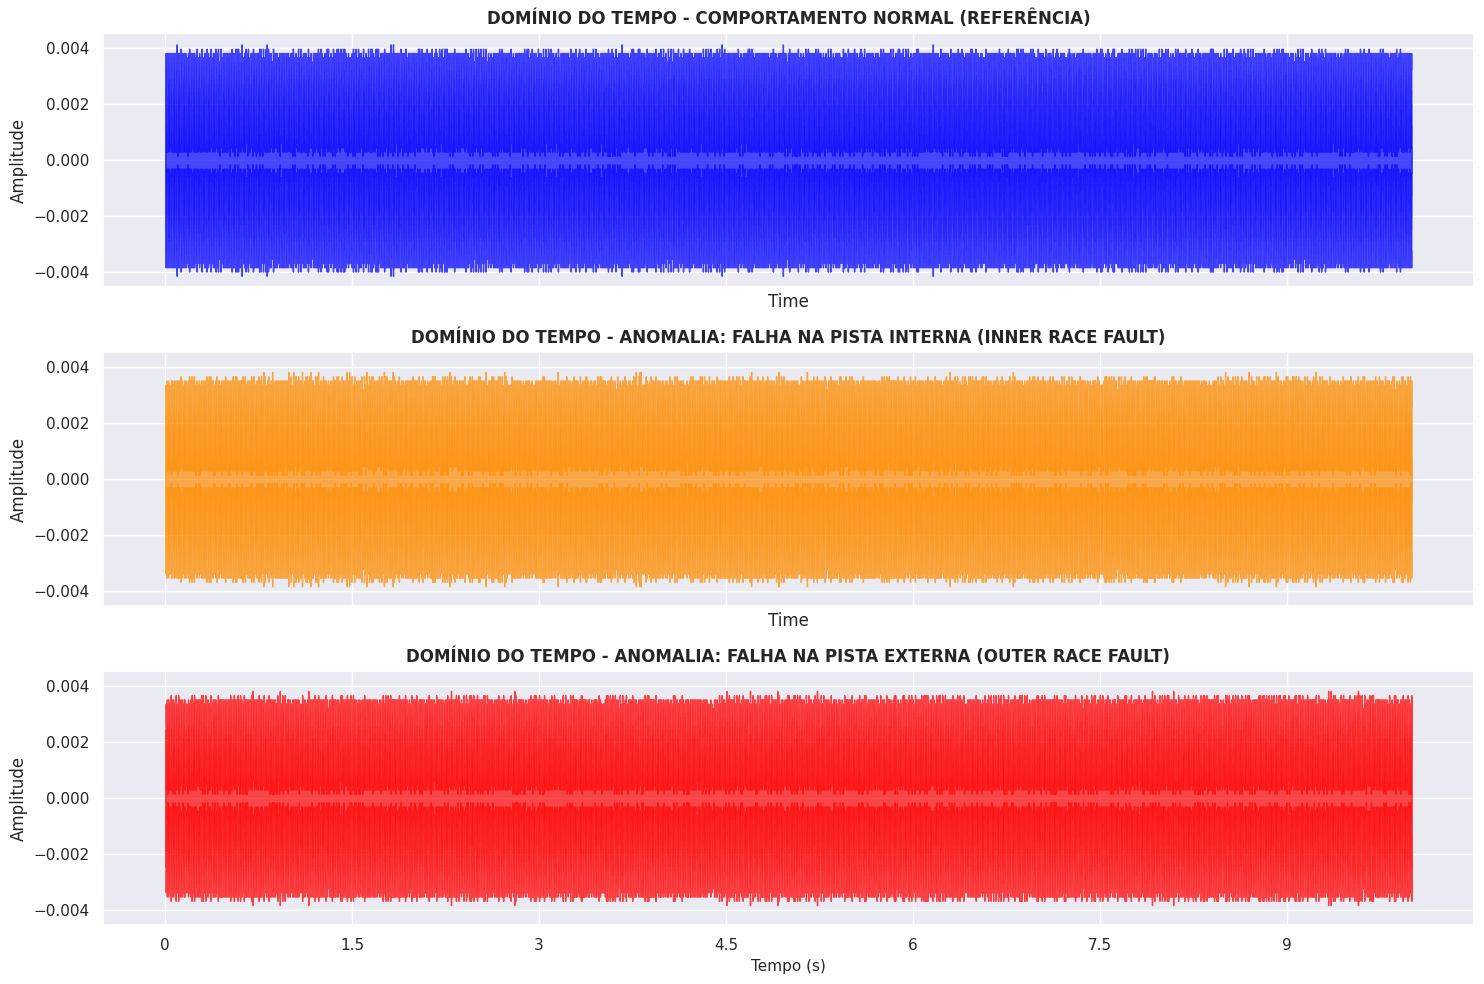

In [6]:
print("📊 Extraindo amostras do Kaggle para visualização técnica...")

# Ensure SR_TARGET is used as sr
sr = SR_TARGET

# Find indices for normal and anomalous signals robustly
normal_signal = None
inner_signal = None
outer_signal = None
anomaly_signal = None

# Attempt to find a normal signal (label 0)
normal_indices = [i for i, label in enumerate(y_train) if label == 0]
if normal_indices:
    normal_signal = X_train[normal_indices[0]]
    print(f"Sinal Normal encontrado no índice: {normal_indices[0]}")
else:
    print("Aviso: Nenhum sinal 'Normal' (label 0) encontrado em X_train/y_train para visualização.")

# Attempt to find anomalous signals (label 1)
anomalous_indices = [i for i, label in enumerate(y_train) if label == 1]
if len(anomalous_indices) > 0:
    inner_signal = X_train[anomalous_indices[0]]
    anomaly_signal = inner_signal # Default anomaly signal for RPCA/NMF later
    print(f"Sinal Anômalo (Inner Race Fault) encontrado no índice: {anomalous_indices[0]}")

    # Try to find a second distinct anomalous signal for outer_signal, if available
    if len(anomalous_indices) > 1:
        outer_signal = X_train[anomalous_indices[1]]
        print(f"Sinal Anômalo (Outer Race Fault) encontrado no índice: {anomalous_indices[1]}")
    else:
        outer_signal = inner_signal # Use the same if only one available
        print("Apenas um sinal anômalo encontrado; usando-o para Inner e Outer Race Fault.")
else:
    print("Aviso: Nenhum sinal 'Anômalo' (label 1) encontrado em X_train/y_train para visualização.")
    # If no anomalous signals, the notebook will effectively halt or plot empty.
    # It's crucial for the rest of the notebook that anomaly_signal is defined if possible.
    # If there are no anomalous signals, the next cell will fail.

# If no anomaly_signal could be found at all, raise an error or inform the user that subsequent cells will fail.
if anomaly_signal is None:
    print("ERRO: Não foi possível encontrar nenhum sinal anômalo. As próximas células que dependem de 'anomaly_signal' falharão.")


# =========================================================
# 3. PLOTAGEM TÉCNICA (Painel Triplo)
# =========================================================
fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True, sharey=True)

# Onda Sonora - Comportamento Normal
if normal_signal is not None:
    librosa.display.waveshow(y=normal_signal, sr=sr, ax=ax[0], color='blue', alpha=0.7)
    ax[0].set_title('DOMÍNIO DO TEMPO - COMPORTAMENTO NORMAL (REFERÊNCIA)', fontsize=12, fontweight='bold')
    ax[0].set_ylabel('Amplitude')
else:
    ax[0].set_title('DOMÍNIO DO TEMPO - COMPORTAMENTO NORMAL (SINAL NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')
    ax[0].set_ylabel('Amplitude') # Keep label for consistency

# Onda Sonora - Falha na Pista Interna (Inner Race)
if inner_signal is not None:
    librosa.display.waveshow(y=inner_signal, sr=sr, ax=ax[1], color='darkorange', alpha=0.7)
    ax[1].set_title('DOMÍNIO DO TEMPO - ANOMALIA: FALHA NA PISTA INTERNA (INNER RACE FAULT)', fontsize=12, fontweight='bold')
    ax[1].set_ylabel('Amplitude')
else:
    ax[1].set_title('DOMÍNIO DO TEMPO - ANOMALIA: FALHA NA PISTA INTERNA (SINAL NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')
    ax[1].set_ylabel('Amplitude')

# Onda Sonora - Falha na Pista Externa (Outer Race)
if outer_signal is not None:
    librosa.display.waveshow(y=outer_signal, sr=sr, ax=ax[2], color='red', alpha=0.7)
    ax[2].set_title('DOMÍNIO DO TEMPO - ANOMALIA: FALHA NA PISTA EXTERNA (OUTER RACE FAULT)', fontsize=12, fontweight='bold')
    ax[2].set_xlabel('Tempo (s)', fontsize=11)
    ax[2].set_ylabel('Amplitude')
else:
    ax[2].set_title('DOMÍNIO DO TEMPO - ANOMALIA: FALHA NA PISTA EXTERNA (SINAL NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')
    ax[2].set_xlabel('Tempo (s)', fontsize=11)
    ax[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

# 3 - HHT (Limpeza/Isolamento)

In [7]:
def _ukf_state_transition(x, dt):
    return np.array([x[0] + dt * x[1], x[1]], dtype=np.float64)


def _ukf_measurement_model(x):
    return np.array([x[0]], dtype=np.float64)


def _run_ukf_pass(signal, dt, process_var, measurement_var, alpha, beta, kappa):
    points = MerweScaledSigmaPoints(n=2, alpha=alpha, beta=beta, kappa=kappa)
    ukf = UnscentedKalmanFilter(
        dim_x=2,
        dim_z=1,
        dt=dt,
        fx=_ukf_state_transition,
        hx=_ukf_measurement_model,
        points=points,
    )

    signal_var = np.var(signal) + 1e-9
    ukf.x = np.array([signal[0], 0.0], dtype=np.float64)
    ukf.P = np.diag([signal_var * 5.0 + 1e-6, 1.0])
    ukf.Q = np.array(
        [
            [process_var, 0.0],
            [0.0, process_var * 0.25 + 1e-9],
        ],
        dtype=np.float64,
    )
    ukf.R = np.array([[measurement_var]], dtype=np.float64)

    estimates = np.empty(len(signal), dtype=np.float64)
    for i, sample in enumerate(signal):
        ukf.predict()
        ukf.update(np.array([sample], dtype=np.float64))
        estimates[i] = ukf.x[0]

    return estimates


def apply_hht_denoising(signal, sr=10000, max_imfs=2):
    """
    Aplica a Transformada de Hilbert-Huang (via EMD) para denoising e isolamento
    de um sinal de áudio, retornando o primeiro componente (IMF 0).
    """
    signal_64 = np.asarray(signal, dtype=np.float64).flatten()
    if signal_64.size < 8:
        return signal_64.astype(np.float32)

    emd_inst = EMD()

    try:
        imfs = emd_inst.emd(signal_64, max_imf=max_imfs)
        if imfs is not None and np.ndim(imfs) == 2 and imfs.shape[0] > 0:
            return imfs[0].astype(np.float32)
        return signal_64.astype(np.float32)
    except Exception:
        return signal_64.astype(np.float32)


def apply_ukf_denoising(
    signal,
    sr=10000,
    process_noise_scale=0.02,
    measurement_noise_scale=0.15,
    alpha=0.1,
    beta=2.0,
    kappa=0.0,
    bidirectional=True,
):
    """
    Frente 3 de DSP: filtro UKF para suavizar o ruído de sensor preservando a dinâmica do sinal.
    O estado é modelado como [amplitude, velocidade], uma formulação clássica para 1D sensor fusion.
    """
    signal_64 = np.asarray(signal, dtype=np.float64).flatten()
    if signal_64.size < 8:
        return signal_64.astype(np.float32)

    signal_var = np.var(signal_64) + 1e-9
    process_var = max(signal_var * process_noise_scale, 1e-9)
    measurement_var = max(signal_var * measurement_noise_scale, 1e-9)
    dt = 1.0 / max(sr, 1)

    forward = _run_ukf_pass(signal_64, dt, process_var, measurement_var, alpha, beta, kappa)
    if bidirectional:
        backward = _run_ukf_pass(signal_64[::-1], dt, process_var, measurement_var, alpha, beta, kappa)[::-1]
        filtered = 0.5 * (forward + backward)
    else:
        filtered = forward

    return filtered.astype(np.float32)


def apply_hht_ukf_denoising(signal, sr=10000):
    """
    Pipeline híbrido recomendado:
    1. HHT expõe os transientes de falha.
    2. UKF estabiliza o piso de ruído sem apagar os impactos principais.
    """
    hht_signal = apply_hht_denoising(signal, sr=sr, max_imfs=2)
    return apply_ukf_denoising(
        hht_signal,
        sr=sr,
        process_noise_scale=0.01,
        measurement_noise_scale=0.08,
        bidirectional=True,
    )


DSP_FRONT_OPTIONS = {
    "hht": apply_hht_denoising,
    "ukf": apply_ukf_denoising,
    "hht_ukf": apply_hht_ukf_denoising,
}

print("✅ Frente DSP 1: HHT pronta para o pipeline.")
print("✅ Frente DSP 3: UKF pronta para o pipeline.")
print("✅ Frente híbrida HHT + UKF pronta para uso experimental.")


✅ Frente DSP 1: HHT pronta para o pipeline.
✅ Frente DSP 3: UKF pronta para o pipeline.
✅ Frente híbrida HHT + UKF pronta para uso experimental.


⚙️ Processando as frentes DSP para os sinais de demonstração...


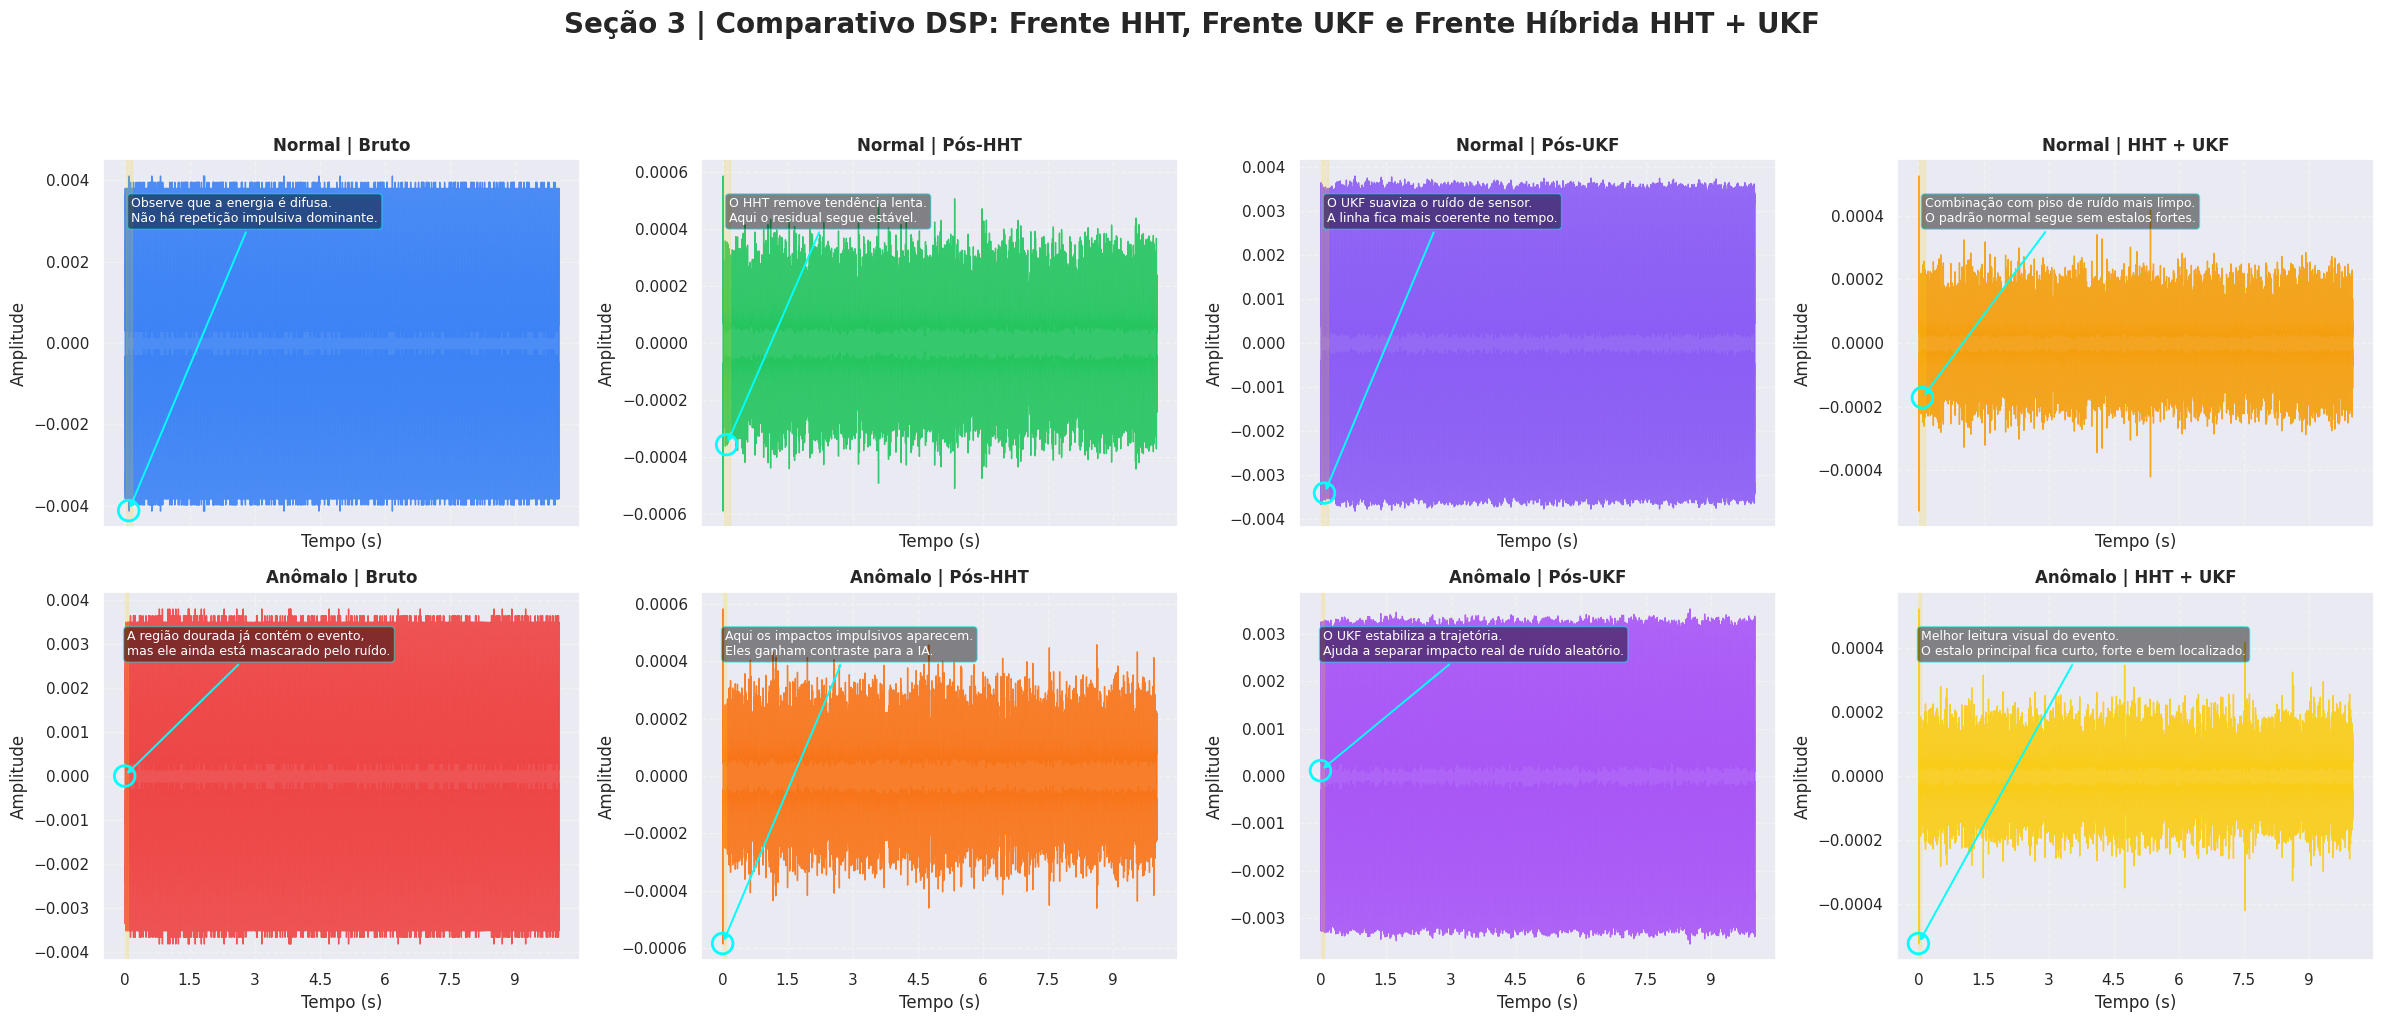


 📊 RELATÓRIO DIDÁTICO DO DSP
1. HHT: excelente para expor transientes curtos ligados a atrito, choque e impacto.
2. UKF: excelente para estabilizar ruído de sensor e preservar continuidade dinâmica.
3. HHT + UKF: recomendado quando você quer expor a falha e ao mesmo tempo reduzir o piso de ruído.
4. O círculo ciano marca o ponto de maior energia local; a faixa dourada mostra a janela que merece inspeção.
5. Para sinais normais, queremos residual baixo e sem repetição impulsiva. Para sinais anômalos, buscamos estalos concentrados.


In [8]:
# =========================================================
# 3. DIAGNÓSTICO VISUAL: HHT vs UKF vs HHT + UKF
# =========================================================

print("⚙️ Processando as frentes DSP para os sinais de demonstração...")

signal_normal_raw = normal_signal
signal_anomaly_raw = anomaly_signal
sr_visual = SR_TARGET


def get_focus_window(signal, sr=10000, window_ms=140):
    if signal is None or len(signal) == 0:
        return 0.0, 0.15, 0.05

    envelope = np.abs(np.asarray(signal, dtype=np.float32))
    peak_idx = int(np.argmax(envelope))
    peak_time = peak_idx / sr
    half_window = window_ms / 2000.0
    t_start = max(0.0, peak_time - half_window)
    t_end = min(len(signal) / sr, peak_time + half_window)
    return t_start, t_end, peak_time


def plot_waveform_panel(ax, signal, sr, title, color, focus_window, annotation_text):
    if signal is None:
        ax.set_title(f"{title} (NÃO DISPONÍVEL)", fontsize=12, fontweight='bold', color='gray')
        ax.set_xlabel('Tempo (s)')
        ax.grid(True, linestyle='--', alpha=0.25)
        return

    librosa.display.waveshow(y=signal, sr=sr, ax=ax, color=color, alpha=0.9)
    t_start, t_end, peak_time = focus_window
    ax.axvspan(t_start, t_end, color='gold', alpha=0.16)

    peak_idx = min(int(peak_time * sr), len(signal) - 1)
    peak_amp = signal[peak_idx]
    text_x = min(len(signal) / sr * 0.72, peak_time + 0.06)
    text_y = 0.72 * np.max(np.abs(signal)) if np.max(np.abs(signal)) > 0 else 0.2

    ax.scatter([peak_time], [peak_amp], s=220, facecolors='none', edgecolors='cyan', linewidths=2)
    ax.annotate(
        annotation_text,
        xy=(peak_time, peak_amp),
        xytext=(text_x, text_y),
        fontsize=9,
        color='white',
        arrowprops=dict(arrowstyle='->', color='cyan', lw=1.4),
        bbox=dict(boxstyle='round,pad=0.3', fc='black', ec='cyan', alpha=0.45),
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, linestyle='--', alpha=0.35)


signal_normal_hht = apply_hht_denoising(signal_normal_raw, sr=sr_visual) if signal_normal_raw is not None else None
signal_normal_ukf = apply_ukf_denoising(signal_normal_raw, sr=sr_visual) if signal_normal_raw is not None else None
signal_normal_hht_ukf = apply_hht_ukf_denoising(signal_normal_raw, sr=sr_visual) if signal_normal_raw is not None else None

signal_anomaly_hht = apply_hht_denoising(signal_anomaly_raw, sr=sr_visual) if signal_anomaly_raw is not None else None
signal_anomaly_ukf = apply_ukf_denoising(signal_anomaly_raw, sr=sr_visual) if signal_anomaly_raw is not None else None
signal_anomaly_hht_ukf = apply_hht_ukf_denoising(signal_anomaly_raw, sr=sr_visual) if signal_anomaly_raw is not None else None

normal_focus = get_focus_window(signal_normal_raw, sr=sr_visual)
anomaly_focus = get_focus_window(
    signal_anomaly_hht_ukf if signal_anomaly_hht_ukf is not None else signal_anomaly_raw,
    sr=sr_visual,
)

fig, ax = plt.subplots(2, 4, figsize=(24, 10), sharex='col')

plot_waveform_panel(
    ax[0, 0],
    signal_normal_raw,
    sr_visual,
    'Normal | Bruto',
    '#3b82f6',
    normal_focus,
    'Observe que a energia é difusa.\nNão há repetição impulsiva dominante.',
)
plot_waveform_panel(
    ax[0, 1],
    signal_normal_hht,
    sr_visual,
    'Normal | Pós-HHT',
    '#22c55e',
    normal_focus,
    'O HHT remove tendência lenta.\nAqui o residual segue estável.',
)
plot_waveform_panel(
    ax[0, 2],
    signal_normal_ukf,
    sr_visual,
    'Normal | Pós-UKF',
    '#8b5cf6',
    normal_focus,
    'O UKF suaviza o ruído de sensor.\nA linha fica mais coerente no tempo.',
)
plot_waveform_panel(
    ax[0, 3],
    signal_normal_hht_ukf,
    sr_visual,
    'Normal | HHT + UKF',
    '#f59e0b',
    normal_focus,
    'Combinação com piso de ruído mais limpo.\nO padrão normal segue sem estalos fortes.',
)

plot_waveform_panel(
    ax[1, 0],
    signal_anomaly_raw,
    sr_visual,
    'Anômalo | Bruto',
    '#ef4444',
    anomaly_focus,
    'A região dourada já contém o evento,\nmas ele ainda está mascarado pelo ruído.',
)
plot_waveform_panel(
    ax[1, 1],
    signal_anomaly_hht,
    sr_visual,
    'Anômalo | Pós-HHT',
    '#f97316',
    anomaly_focus,
    'Aqui os impactos impulsivos aparecem.\nEles ganham contraste para a IA.',
)
plot_waveform_panel(
    ax[1, 2],
    signal_anomaly_ukf,
    sr_visual,
    'Anômalo | Pós-UKF',
    '#a855f7',
    anomaly_focus,
    'O UKF estabiliza a trajetória.\nAjuda a separar impacto real de ruído aleatório.',
)
plot_waveform_panel(
    ax[1, 3],
    signal_anomaly_hht_ukf,
    sr_visual,
    'Anômalo | HHT + UKF',
    '#facc15',
    anomaly_focus,
    'Melhor leitura visual do evento.\nO estalo principal fica curto, forte e bem localizado.',
)

plt.suptitle(
    'Seção 3 | Comparativo DSP: Frente HHT, Frente UKF e Frente Híbrida HHT + UKF',
    fontsize=20,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n" + "=" * 92)
print(" 📊 RELATÓRIO DIDÁTICO DO DSP")
print("=" * 92)
print("1. HHT: excelente para expor transientes curtos ligados a atrito, choque e impacto.")
print("2. UKF: excelente para estabilizar ruído de sensor e preservar continuidade dinâmica.")
print("3. HHT + UKF: recomendado quando você quer expor a falha e ao mesmo tempo reduzir o piso de ruído.")
print("4. O círculo ciano marca o ponto de maior energia local; a faixa dourada mostra a janela que merece inspeção.")
print("5. Para sinais normais, queremos residual baixo e sem repetição impulsiva. Para sinais anômalos, buscamos estalos concentrados.")
print("=" * 92)


# GERANDO X_train_hht e y_train_hht

In [9]:
# Frente configurável de DSP antes da segmentação
X_subset = X_train
y_subset = y_train

DSP_FRONT = os.getenv('AAD_DSP_FRONT', 'hht_ukf').strip().lower()
DSP_FRONT_LABELS = {
    'hht': 'HHT',
    'ukf': 'UKF',
    'hht_ukf': 'HHT + UKF',
}

if DSP_FRONT not in DSP_FRONT_OPTIONS:
    raise ValueError(
        f"Frente DSP inválida: {DSP_FRONT}. Use uma entre {list(DSP_FRONT_OPTIONS.keys())}."
    )

def process_signals_with_front(signals, front_name, sr=SR_TARGET, max_len=20000, desc_prefix='Filtrando Sinais'):
    if front_name not in DSP_FRONT_OPTIONS:
        raise ValueError(
            f"Frente DSP inválida: {front_name}. Use uma entre {list(DSP_FRONT_OPTIONS.keys())}."
        )

    dsp_processor = DSP_FRONT_OPTIONS[front_name]
    processed_signals = []

    for sig in tqdm(signals, desc=f"{desc_prefix} ({DSP_FRONT_LABELS[front_name]})"):
        try:
            signal_short = sig[:min(len(sig), max_len)].astype(np.float32)
            signal_dsp = dsp_processor(signal_short, sr=sr)
            processed_signals.append(np.asarray(signal_dsp, dtype=np.float32))
        except Exception as e:
            print(
                f"Erro ao processar sinal com {DSP_FRONT_LABELS[front_name]}: {e}. "
                "Anexando sinal original truncado."
            )
            processed_signals.append(sig[:min(len(sig), max_len)].astype(np.float32))

    return processed_signals

print(f"⚡ Iniciando Processamento DSP com a frente '{DSP_FRONT_LABELS[DSP_FRONT]}'...")
print("   Opções disponíveis: hht | ukf | hht_ukf")

X_train_dsp_signals = process_signals_with_front(
    X_subset,
    DSP_FRONT,
    sr=SR_TARGET,
    max_len=20000,
    desc_prefix='Filtrando Sinais'
)
y_train_dsp = np.array(y_subset, dtype=np.int64)

DSP_FRONT_ATIVO = DSP_FRONT
DSP_FRONT_ATIVO_LABEL = DSP_FRONT_LABELS[DSP_FRONT]
X_train_dsp = X_train_dsp_signals

# Alias legados para nao quebrar secoes antigas; prefira os nomes DSP.
X_train_hht = X_train_dsp_signals
y_train_hht = y_train_dsp

print(f"\n✅ PROCESSAMENTO DSP CONCLUÍDO!")
print(f"📊 Variável principal 'X_train_dsp_signals' pronta com {len(X_train_dsp_signals)} sinais.")
print("🔁 Alias legado ativo: `X_train_hht` / `y_train_hht` (somente compatibilidade com células antigas).")
print(f"🧪 Frente ativa nesta execução: {DSP_FRONT_ATIVO_LABEL}")
print("🧭 Para comparar as três frentes na Frente 5, use:")
print("   export AAD_COMPARE_ALL_DSP_FRONTS=1")
print("   ou export AAD_DSP_BENCHMARK_FRONTS='hht,ukf,hht_ukf'")


⚡ Iniciando Processamento DSP com a frente 'HHT + UKF'...
   Opções disponíveis: hht | ukf | hht_ukf


Filtrando Sinais (HHT + UKF): 100%|██████████| 750/750 [2:06:30<00:00, 10.12s/it]


✅ PROCESSAMENTO DSP CONCLUÍDO!
📊 Variável principal 'X_train_dsp_signals' pronta com 750 sinais.
🔁 Alias legado ativo: `X_train_hht` / `y_train_hht` (somente compatibilidade com células antigas).
🧪 Frente ativa nesta execução: HHT + UKF
🧭 Para comparar as três frentes na Frente 5, use:
   export AAD_COMPARE_ALL_DSP_FRONTS=1
   ou export AAD_DSP_BENCHMARK_FRONTS='hht,ukf,hht_ukf'


# 4 - Criação das janelas deslizantes.


[PASSO 1] Fatiando áudios pós-DSP com janela deslizante...


Fatiando Janelas: 100%|██████████| 750/750 [00:00<00:00, 157830.92áudio/s]



[PASSO 2] Extraindo features estruturais para 750 fatias...


Extraindo Features: 100%|██████████| 750/750 [01:43<00:00,  7.24fatia/s]



[PASSO 3] Pré-visualização didática da Frente 4 (Mixup)...


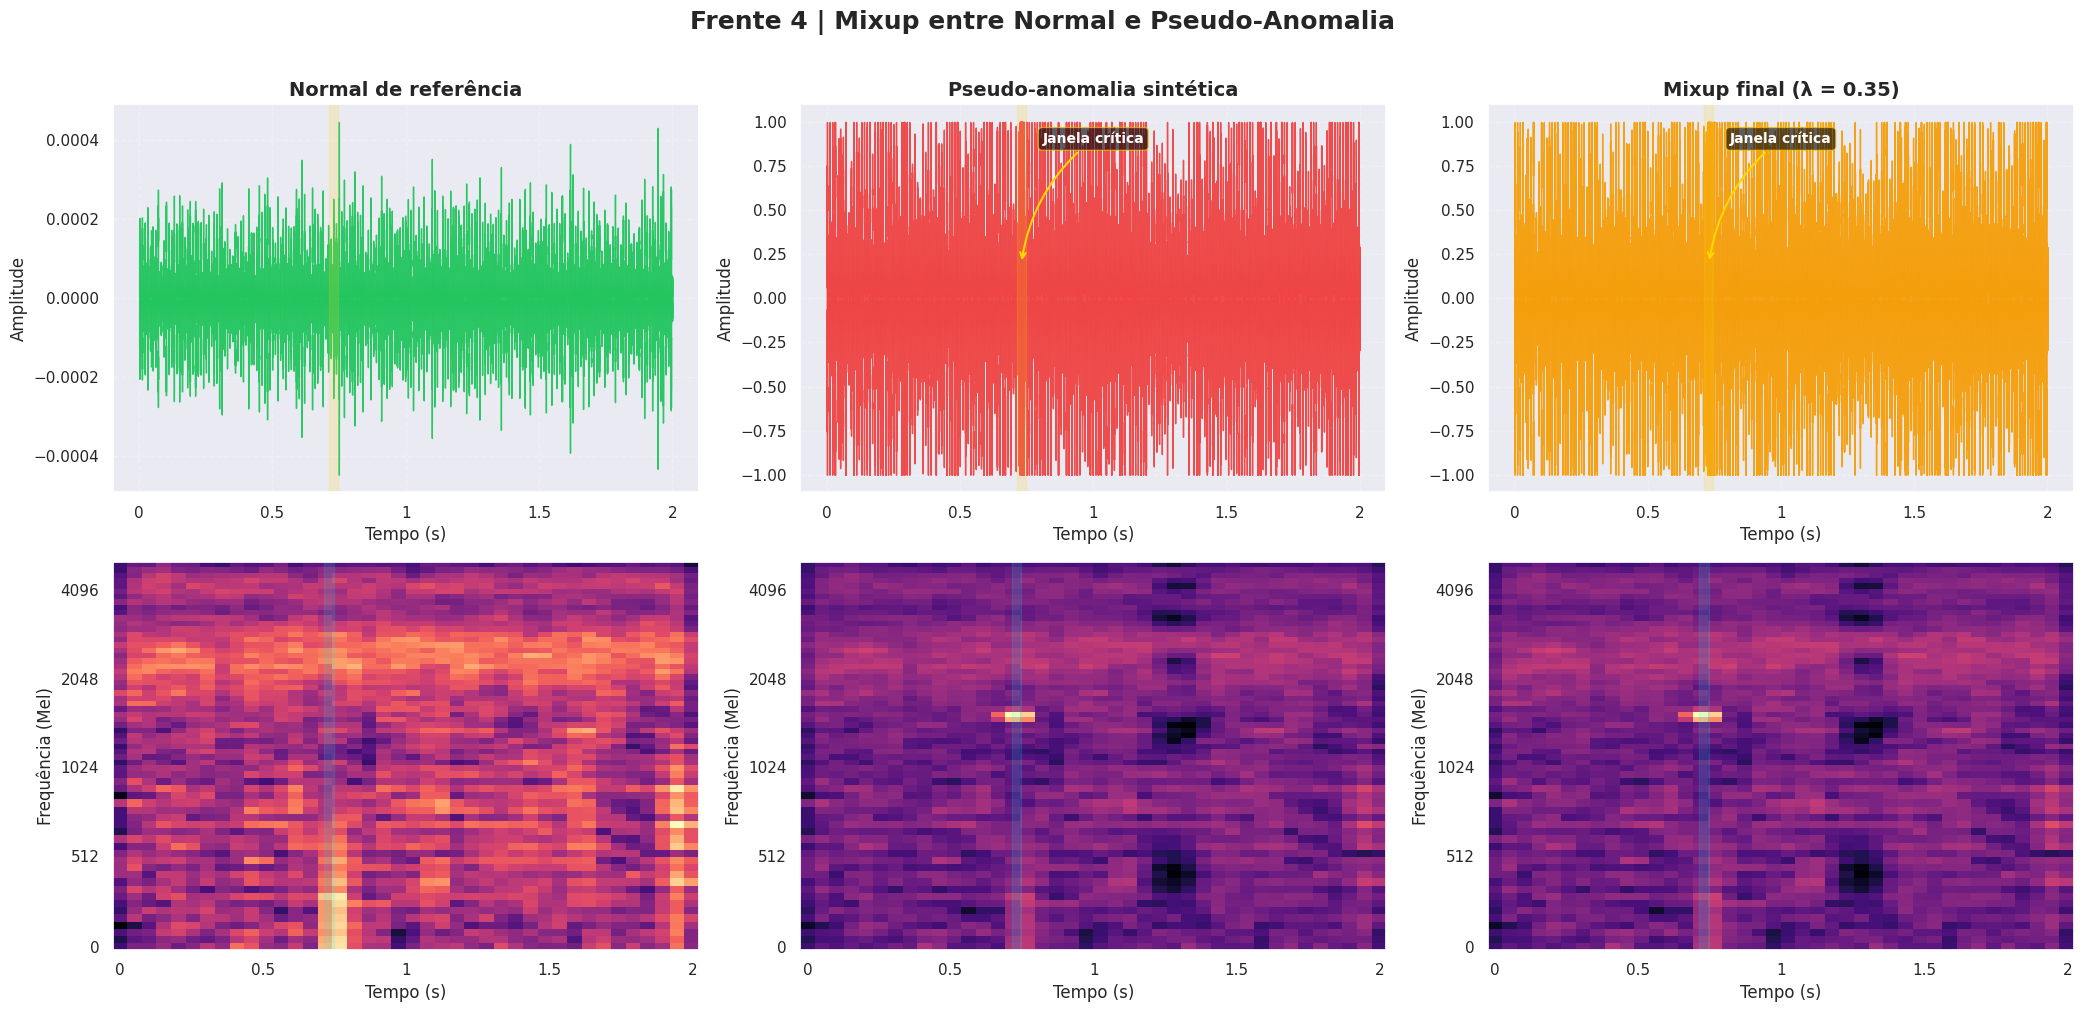

,Sinal,Leitura
0,Normal,Referência da máquina sem defeito explícito
1,Pseudo-anomalia,"Evento sintético entre 0.713s e 0.747s, com po..."
2,Mixup,Combinação convexa com λ=0.35; serve para ensi...



🎯 DATASET ESTRUTURAL GERADO COM SUCESSO!
-> Tensor Mel (CNN): (750, 1, 64, 64)
-> Vetor MFCC (XGBoost): (750, 26)
-> Tensor CWT Wavelet: (750, 1, 64, 64)
-> Erro NMF (Exp 5): (750,)
-> Frente 4 Mixup ativa: True


In [10]:
def build_signal_metadata(file_names=None, labels=None, groups=None, folders=None):
    labels = np.asarray(labels if labels is not None else [], dtype=np.int64)
    total = int(len(labels))

    file_names = list(file_names) if file_names is not None else [f'arquivo_{i:04d}.csv' for i in range(total)]
    groups = list(groups) if groups is not None else [Path(name).stem for name in file_names]
    folders = list(folders) if folders is not None else ['desconhecido'] * total

    if not (len(file_names) == len(groups) == len(folders) == total):
        raise ValueError("Os metadados de origem precisam ter o mesmo tamanho da lista de sinais.")

    metadata = []
    for idx, (name, label, group, folder) in enumerate(zip(file_names, labels, groups, folders)):
        metadata.append({
            'source_index': int(idx),
            'source_file': str(name),
            'source_folder': str(folder),
            'group_id': str(group),
            'class_label': int(label),
            'class_name': 'Anômalo' if int(label) == 1 else 'Normal',
        })
    return metadata

def apply_sliding_window_to_list(
    audio_list,
    labels_list,
    sr=10000,
    window_size=2.0,
    overlap=0.5,
    metadata_list=None,
    return_metadata=False,
):
    step = int(window_size * sr * (1 - overlap))
    w_len = int(window_size * sr)
    all_segments, all_labels = [], []
    all_metadata = []

    for i, audio in enumerate(tqdm(audio_list, desc="Fatiando Janelas", unit="áudio")):
        label = int(labels_list[i])
        base_metadata = {}
        if metadata_list is not None and i < len(metadata_list):
            candidate = metadata_list[i]
            if isinstance(candidate, dict):
                base_metadata = dict(candidate)
            else:
                base_metadata = {'group_id': str(candidate), 'source_file': str(candidate)}

        if 'group_id' not in base_metadata:
            base_metadata['group_id'] = f'arquivo_{i:04d}'
        if 'source_file' not in base_metadata:
            base_metadata['source_file'] = str(base_metadata['group_id'])
        if 'source_folder' not in base_metadata:
            base_metadata['source_folder'] = 'desconhecido'
        base_metadata['source_index'] = int(base_metadata.get('source_index', i))
        base_metadata['class_label'] = label
        base_metadata['class_name'] = 'Anômalo' if label == 1 else 'Normal'

        if len(audio) < w_len:
            audio = np.pad(audio, (0, w_len - len(audio)))

        for window_idx, start in enumerate(range(0, len(audio) - w_len + 1, step)):
            all_segments.append(audio[start : start + w_len].astype(np.float32, copy=False))
            all_labels.append(label)

            if return_metadata:
                window_meta = dict(base_metadata)
                window_meta.update({
                    'window_index': int(window_idx),
                    'start_sample': int(start),
                    'end_sample': int(start + w_len),
                    'start_s': round(start / sr, 4),
                    'end_s': round((start + w_len) / sr, 4),
                    'window_size_s': float(window_size),
                    'overlap': float(overlap),
                })
                all_metadata.append(window_meta)

    segments = np.array(all_segments, dtype=np.float32)
    labels = np.array(all_labels, dtype=np.int64)

    if return_metadata:
        return segments, labels, pd.DataFrame(all_metadata)
    return segments, labels

def build_grouped_protocol_split(
    window_metadata_df,
    test_size=0.30,
    random_state=42,
    group_col='group_id',
    label_col='class_label',
):
    if not isinstance(window_metadata_df, pd.DataFrame) or window_metadata_df.empty:
        raise ValueError("A Frente 6 precisa de um DataFrame de metadados das janelas.")

    df = window_metadata_df.copy().reset_index(drop=True)
    required_cols = {group_col, label_col, 'source_file', 'source_folder', 'class_name'}
    missing_cols = required_cols.difference(df.columns)
    if missing_cols:
        raise ValueError(f"Metadados insuficientes para a Frente 6: {sorted(missing_cols)}")

    label_consistency = df.groupby(group_col)[label_col].nunique()
    if (label_consistency > 1).any():
        raise RuntimeError("Um mesmo arquivo foi associado a mais de uma classe. Revise os metadados antes do split.")

    source_df = (
        df[[group_col, label_col, 'class_name', 'source_file', 'source_folder']]
        .drop_duplicates(subset=[group_col])
        .reset_index(drop=True)
    )

    unique_groups = source_df[group_col].to_numpy()
    group_labels = source_df[label_col].to_numpy()

    can_stratify = (
        len(np.unique(group_labels)) > 1
        and np.min(np.bincount(group_labels)) >= 2
        and len(unique_groups) >= 4
    )
    stratify_labels = group_labels if can_stratify else None

    train_groups, test_groups = train_test_split(
        unique_groups,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_labels,
    )

    train_mask = df[group_col].isin(train_groups).to_numpy()
    test_mask = df[group_col].isin(test_groups).to_numpy()
    train_idx = np.flatnonzero(train_mask)
    test_idx = np.flatnonzero(test_mask)

    if len(train_idx) == 0 or len(test_idx) == 0:
        raise RuntimeError("A Frente 6 gerou um split vazio. Ajuste o tamanho do teste ou o número de arquivos.")

    shared_groups = sorted(set(train_groups).intersection(set(test_groups)))

    audit_df = df[[group_col, 'source_file', 'source_folder', 'class_name']].copy()
    audit_df['Split'] = np.where(train_mask, 'Treino', 'Teste')

    file_summary = (
        audit_df.drop_duplicates(subset=[group_col])
        .groupby(['Split', 'class_name'])
        .size()
        .rename('Arquivos')
        .reset_index()
    )
    window_summary = (
        audit_df.groupby(['Split', 'class_name'])
        .size()
        .rename('Janelas')
        .reset_index()
    )
    summary_table = (
        pd.merge(file_summary, window_summary, on=['Split', 'class_name'], how='outer')
        .fillna(0)
        .rename(columns={'class_name': 'Classe'})
        .sort_values(['Split', 'Classe'])
        .reset_index(drop=True)
    )
    if not summary_table.empty:
        summary_table[['Arquivos', 'Janelas']] = summary_table[['Arquivos', 'Janelas']].astype(int)

    source_table = (
        audit_df.drop_duplicates(subset=[group_col])
        .sort_values(['Split', 'Classe' if 'Classe' in audit_df.columns else 'class_name', 'source_file'])
        .reset_index(drop=True)
    )

    return {
        'train_idx': train_idx.astype(np.int64),
        'test_idx': test_idx.astype(np.int64),
        'train_groups': list(train_groups),
        'test_groups': list(test_groups),
        'shared_group_count': int(len(shared_groups)),
        'shared_groups': shared_groups,
        'summary_table': summary_table,
        'audit_table': source_table,
        'protocol_label': 'holdout agrupado por arquivo de origem',
        'grouping_label': 'arquivo de origem',
    }

def apply_cwt(signal, sr, wavelet='morl', scales=None):
    if scales is None:
        max_scale = len(signal) / (2 * sr)
        scales = np.arange(1, int(max_scale * 10), 1) if int(max_scale * 10) > 1 else np.array([1])
    coefficients, frequencies = pywt.cwt(signal, scales, wavelet, sampling_period=1 / sr)
    return coefficients, frequencies

def safe_normalize_audio(signal):
    signal = np.asarray(signal, dtype=np.float32)
    peak = np.max(np.abs(signal)) + 1e-9
    return (signal / peak).astype(np.float32)

def create_pseudo_anomaly(signal, sr=10000, rng=None, return_metadata=False):
    rng = rng or np.random.default_rng(42)
    x = np.asarray(signal, dtype=np.float32).copy()

    if x.size < 128:
        metadata = {
            'event_start_s': 0.0,
            'event_end_s': min(len(x) / max(sr, 1), 0.01),
            'carrier_freq_hz': 0.0,
            'strategy': 'sinal_curto_sem_perturbacao'
        }
        return (x, metadata) if return_metadata else x

    n = len(x)
    sig_std = float(np.std(x) + 1e-6)

    event_len = int(rng.integers(max(64, int(0.03 * sr)), max(65, int(0.12 * sr))))
    event_start = int(rng.integers(0, max(1, n - event_len)))
    event_end = min(n, event_start + event_len)

    burst_t = np.arange(event_end - event_start) / sr
    carrier_freq = float(rng.uniform(250.0, min(sr / 3, 2400.0)))
    burst = np.sin(2 * np.pi * carrier_freq * burst_t + rng.uniform(0, 2 * np.pi))
    burst *= np.hanning(max(8, burst.size))
    burst *= rng.uniform(2.0, 4.5) * sig_std
    x[event_start:event_end] += burst.astype(np.float32)

    patch_len = int(rng.integers(max(64, int(0.05 * sr)), max(65, int(0.18 * sr))))
    patch_start = int(rng.integers(0, max(1, n - patch_len)))
    patch_end = min(n, patch_start + patch_len)
    patch = x[patch_start:patch_end].copy()

    if patch.size > 8:
        operation_id = int(rng.integers(0, 3))
        if operation_id == 0:
            patch = patch[::-1]
            strategy = 'burst + inversão local'
        elif operation_id == 1:
            patch = np.roll(patch, int(rng.integers(4, max(5, patch.size // 3))))
            strategy = 'burst + deslocamento local'
        else:
            order = np.arange(patch.size)
            rng.shuffle(order)
            patch = patch[order]
            strategy = 'burst + embaralhamento local'
        x[patch_start:patch_end] = 0.65 * x[patch_start:patch_end] + 0.35 * patch.astype(np.float32)
    else:
        strategy = 'burst localizado'

    x = np.clip(x, -3.0 * (sig_std + 1e-6), 3.0 * (sig_std + 1e-6))
    x = safe_normalize_audio(x)

    metadata = {
        'event_start_s': round(event_start / sr, 4),
        'event_end_s': round(event_end / sr, 4),
        'event_center_s': round(((event_start + event_end) / 2) / sr, 4),
        'carrier_freq_hz': round(carrier_freq, 1),
        'patch_start_s': round(patch_start / sr, 4),
        'patch_end_s': round(patch_end / sr, 4),
        'strategy': strategy,
    }
    return (x.astype(np.float32), metadata) if return_metadata else x.astype(np.float32)

def mixup_audio_pair(normal_signal, pseudo_signal, alpha=0.4, rng=None, lam_bounds=(0.35, 0.85)):
    rng = rng or np.random.default_rng(42)
    lam = float(np.clip(rng.beta(alpha, alpha), lam_bounds[0], lam_bounds[1]))
    mixed = lam * np.asarray(normal_signal, dtype=np.float32) + (1.0 - lam) * np.asarray(pseudo_signal, dtype=np.float32)
    return safe_normalize_audio(mixed), lam

def create_mixup_dataset(normal_segments, sr=10000, mixup_ratio=0.2, alpha=0.4, max_samples=800, seed=42):
    normal_segments = np.asarray(normal_segments, dtype=np.float32)
    if normal_segments.size == 0 or mixup_ratio <= 0:
        return np.empty((0,), dtype=np.float32), np.empty((0,), dtype=np.int64), pd.DataFrame()

    rng = np.random.default_rng(seed)
    total = min(int(np.ceil(len(normal_segments) * mixup_ratio)), max_samples)
    if total <= 0:
        return np.empty((0,), dtype=np.float32), np.empty((0,), dtype=np.int64), pd.DataFrame()

    replace = len(normal_segments) < total
    chosen_idx = rng.choice(len(normal_segments), size=total, replace=replace)

    mix_segments = []
    rows = []
    for sample_id, base_idx in enumerate(chosen_idx, start=1):
        base_signal = normal_segments[int(base_idx)]
        pseudo_signal, meta = create_pseudo_anomaly(base_signal, sr=sr, rng=rng, return_metadata=True)
        mixed_signal, lam = mixup_audio_pair(base_signal, pseudo_signal, alpha=alpha, rng=rng)
        mix_segments.append(mixed_signal.astype(np.float32))
        rows.append({
            'Amostra': sample_id,
            'Indice_Base': int(base_idx),
            'Lambda': round(lam, 4),
            'Evento (s)': f"{meta['event_start_s']:.3f}-{meta['event_end_s']:.3f}",
            'Portadora (Hz)': meta['carrier_freq_hz'],
            'Estratégia': meta['strategy'],
        })

    return (
        np.array(mix_segments, dtype=np.float32),
        np.ones(len(mix_segments), dtype=np.int64),
        pd.DataFrame(rows),
    )

def extract_features(X_segments, sr=10000, n_mels=64, fixed_img_dims=(64, 64)):
    feats_mel, feats_mfcc_stats, feats_cwt = [], [], []
    feats_nmf_error = []

    min_scale = 1
    max_scale = len(X_segments[0]) / (2 * sr)
    if max_scale < min_scale:
        max_scale = min_scale + 1
    fixed_scales = np.geomspace(min_scale, max_scale, num=fixed_img_dims[0])

    for audio in tqdm(X_segments, desc="Extraindo Features", unit="fatia"):
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)

        try:
            nmf_model = NMF(n_components=3, init='nndsvda', random_state=42, max_iter=200)
            W = nmf_model.fit_transform(mel)
            H = nmf_model.components_
            mel_reconstructed = np.dot(W, H)
            erro_reconstrucao = np.mean((mel - mel_reconstructed) ** 2)
            feats_nmf_error.append(np.float32(erro_reconstrucao))
        except Exception:
            feats_nmf_error.append(np.float32(0.0))

        mel_db = librosa.power_to_db(mel, ref=np.max)
        if mel_db.shape[1] > fixed_img_dims[1]:
            mel_db = mel_db[:, :fixed_img_dims[1]]
        else:
            mel_db = np.pad(mel_db, ((0, 0), (0, fixed_img_dims[1] - mel_db.shape[1])))
        feats_mel.append(mel_db[np.newaxis, ...].astype(np.float32))

        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        feats_mfcc_stats.append(np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)]).astype(np.float32))

        coefficients, _ = apply_cwt(audio, sr=sr, scales=fixed_scales)
        coefficients_abs = np.abs(coefficients)
        zoom_factors = (
            fixed_img_dims[0] / coefficients_abs.shape[0],
            fixed_img_dims[1] / coefficients_abs.shape[1],
        )
        resized_cwt = zoom(coefficients_abs, zoom_factors, order=1)
        feats_cwt.append(resized_cwt[np.newaxis, ...].astype(np.float32))

    return (
        np.array(feats_mel, dtype=np.float32),
        np.array(feats_mfcc_stats, dtype=np.float32),
        np.array(feats_cwt, dtype=np.float32),
        np.array(feats_nmf_error, dtype=np.float32),
    )

def plot_mixup_preview(normal_signal, pseudo_signal, mixup_signal, meta, lam, sr=10000):
    fig, axes = plt.subplots(2, 3, figsize=(21, 10))
    titles = [
        'Normal de referência',
        'Pseudo-anomalia sintética',
        f'Mixup final (λ = {lam:.2f})',
    ]
    signals = [normal_signal, pseudo_signal, mixup_signal]
    colors = ['#22c55e', '#ef4444', '#f59e0b']
    t0, t1 = meta['event_start_s'], meta['event_end_s']

    for col, (title, signal, color) in enumerate(zip(titles, signals, colors)):
        librosa.display.waveshow(signal, sr=sr, ax=axes[0, col], color=color, alpha=0.95)
        axes[0, col].axvspan(t0, t1, color='gold', alpha=0.16)
        axes[0, col].set_title(title, fontsize=14, fontweight='bold')
        axes[0, col].set_xlabel('Tempo (s)')
        axes[0, col].set_ylabel('Amplitude')
        axes[0, col].grid(True, linestyle='--', alpha=0.25)

        # CORREÇÃO APLICADA AQUI: Uso de axes fraction para evitar vazamento
        axes[0, col].annotate(
            'Janela crítica',
            xy=((t0 + t1) / 2, 0.2),       # Aponta para o centro da anomalia na amplitude
            xytext=(0.5, 0.9),             # Posiciona o texto no topo central (relativo ao eixo)
            textcoords='axes fraction',    # Coordenadas fixas de 0 a 1 dentro do gráfico
            ha='center',
            fontsize=10,
            fontweight='bold',
            color='white',
            arrowprops=dict(
                arrowstyle='->',
                connectionstyle="arc3,rad=.2",
                color='gold',
                lw=1.5
            ),
            bbox=dict(boxstyle='round,pad=0.3', fc='black', ec='gold', alpha=0.6),
        )

        mel = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=64)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(
            mel_db,
            sr=sr,
            x_axis='time',
            y_axis='mel',
            ax=axes[1, col],
            cmap='magma',
        )
        axes[1, col].axvspan(t0, t1, color='cyan', alpha=0.12)
        axes[1, col].set_xlabel('Tempo (s)')
        axes[1, col].set_ylabel('Frequência (Mel)')

    plt.suptitle('Frente 4 | Mixup entre Normal e Pseudo-Anomalia', fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# =========================================================
# EXECUÇÃO DO PIPELINE INTEGRADO
# =========================================================

# Variáveis globais de ambiente (ajuste conforme necessário)
SR_TARGET = 10000
MIXUP_ENABLED = os.getenv('AAD_ENABLE_MIXUP', '1').strip().lower() in {'1', 'true', 'yes', 'sim'}
MIXUP_RATIO = float(os.getenv('AAD_MIXUP_RATIO', '0.20'))
MIXUP_ALPHA = float(os.getenv('AAD_MIXUP_ALPHA', '0.40'))
MIXUP_MAX_SAMPLES = int(os.getenv('AAD_MIXUP_MAX_SAMPLES', '800'))
MIXUP_SEED = int(os.getenv('AAD_MIXUP_SEED', '42'))
MIXUP_TARGET_FPR = float(os.getenv('AAD_MIXUP_TARGET_FPR', '0.10'))

print("\n[PASSO 1] Fatiando áudios pós-DSP com janela deslizante...")
# Certifique-se de que X_train_hht e y_train_hht existam no seu ambiente
X_win, y_win = apply_sliding_window_to_list(X_train_hht, y_train_hht, sr=SR_TARGET, window_size=2.0)

print(f"\n[PASSO 2] Extraindo features estruturais para {len(X_win)} fatias...")
X_mel, X_mfcc_stats, X_cwt, X_nmf_error = extract_features(X_win, sr=SR_TARGET)

print("\n[PASSO 3] Pré-visualização didática da Frente 4 (Mixup)...")
normal_segments_preview = X_win[y_win == 0]

if MIXUP_ENABLED and len(normal_segments_preview) > 0:
    preview_rms = np.array([np.sqrt(np.mean(seg ** 2)) for seg in normal_segments_preview[: min(64, len(normal_segments_preview))]])
    preview_idx = int(np.argmax(preview_rms)) if preview_rms.size > 0 else 0
    preview_base = normal_segments_preview[preview_idx]

    preview_pseudo, preview_meta = create_pseudo_anomaly(
        preview_base,
        sr=SR_TARGET,
        rng=np.random.default_rng(MIXUP_SEED + 7),
        return_metadata=True,
    )

    preview_mixup, preview_lambda = mixup_audio_pair(
        preview_base,
        preview_pseudo,
        alpha=MIXUP_ALPHA,
        rng=np.random.default_rng(MIXUP_SEED + 19),
    )

    plot_mixup_preview(preview_base, preview_pseudo, preview_mixup, preview_meta, preview_lambda, sr=SR_TARGET)

    df_mixup_preview = pd.DataFrame([
        {
            'Sinal': 'Normal',
            'Leitura': 'Referência da máquina sem defeito explícito',
        },
        {
            'Sinal': 'Pseudo-anomalia',
            'Leitura': f"Evento sintético entre {preview_meta['event_start_s']:.3f}s e {preview_meta['event_end_s']:.3f}s, com portadora em {preview_meta['carrier_freq_hz']:.1f} Hz",
        },
        {
            'Sinal': 'Mixup',
            'Leitura': f"Combinação convexa com λ={preview_lambda:.2f}; serve para ensinar ao modelo zonas intermediárias entre normal e falha",
        },
    ])
    display(df_mixup_preview)
else:
    print("Mixup desativado ou sem janelas normais suficientes para a visualização.")

print("\n" + "=" * 70)
print("🎯 DATASET ESTRUTURAL GERADO COM SUCESSO!")
print(f"-> Tensor Mel (CNN): {X_mel.shape}")
print(f"-> Vetor MFCC (XGBoost): {X_mfcc_stats.shape}")
print(f"-> Tensor CWT Wavelet: {X_cwt.shape}")
print(f"-> Erro NMF (Exp 5): {X_nmf_error.shape}")
print(f"-> Frente 4 Mixup ativa: {MIXUP_ENABLED}")
print("=" * 70)

# 5 - Criação das matrizes

*   5.1 - MEL

In [11]:
# =========================================================
# NOTA DIDÁTICA: Entendendo a Extração do Espectrograma de Mel
# =========================================================
# O trecho abaixo ilustra a lógica matemática que consolidou o Tensor X_mel.

def generate_mel_spectrogram_for_segment(audio_segment, sr=10000, n_mels=64, fixed_img_dims=(64, 64)):
    """
    Função de referência para geração de imagens acústicas padronizadas (64x64).
    """
    # 1. Mapeamento de Energia Acústica (Mel Scale)
    mel = librosa.feature.melspectrogram(y=audio_segment, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 2. Padronização do Tensor (Corte ou Padding para 64x64)
    if mel_db.shape[1] > fixed_img_dims[1]:
        mel_db = mel_db[:, :fixed_img_dims[1]]
    else:
        mel_db = np.pad(mel_db, ((0,0), (0, fixed_img_dims[1] - mel_db.shape[1])))

    # Adiciona dimensão de canal (1, 64, 64) para compatibilidade com CNNs
    return mel_db[np.newaxis, ...]

# Validação de Integridade do Tensor Final na RAM
print(f"✅ O Tensor `X_mel` encontra-se sanitizado e alocado na memória!")
print(f"-> Formato (Shape) oficial: {X_mel.shape}")
print(f"-> Total de fatias para o experimento: {X_mel.shape[0]}")
print(f"-> Resolução Acústica: {X_mel.shape[2]} mels x {X_mel.shape[3]} frames.")

✅ O Tensor `X_mel` encontra-se sanitizado e alocado na memória!
-> Formato (Shape) oficial: (750, 1, 64, 64)
-> Total de fatias para o experimento: 750
-> Resolução Acústica: 64 mels x 64 frames.


*   5.2 - MFCC

In [12]:
# =========================================================
# NOTA DIDÁTICA: Entendendo a Extração de MFCCs (Timbre Mecânico)
# =========================================================
# Ilustração da lógica matemática que consolidou a matriz X_mfcc_stats.

def generate_mfcc_stats_for_segment(audio_segment, sr=10000, n_mfcc=13):
    """
    Extrai a 'impressão digital' do áudio usando coeficientes cepstrais.
    """
    # 1. Cálculo dos coeficientes MFCC (Mapeia a cavidade e ressonância)
    mfcc = librosa.feature.mfcc(y=audio_segment, sr=sr, n_mfcc=n_mfcc)

    # 2. Consolidação Estatística (Média e Desvio Padrão)
    # Gera um vetor de 26 posições (13 Médias + 13 Desvios)
    mfcc_stats = np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])

    return mfcc_stats

# Validação de Integridade na RAM
print(f"✅ A matriz global `X_mfcc_stats` encontra-se sanitizada e alocada!")
print(f"-> Formato (Shape) oficial: {X_mfcc_stats.shape}")
print(f"-> Total de fatias processadas: {X_mfcc_stats.shape[0]}")
print(f"-> Atributos por fatia: {X_mfcc_stats.shape[1]} (13 Médias + 13 Desvios Padrão).")

✅ A matriz global `X_mfcc_stats` encontra-se sanitizada e alocada!
-> Formato (Shape) oficial: (750, 26)
-> Total de fatias processadas: 750
-> Atributos por fatia: 26 (13 Médias + 13 Desvios Padrão).


*   5.3 - CWT

In [13]:
# =========================================================
# NOTA DIDÁTICA: Entendendo a Extração da CWT (Wavelets)
# =========================================================
# Ilustração da lógica de redimensionamento e interpolação bilinear.

def generate_cwt_for_segment(audio_segment, sr=10000, fixed_img_dims=(64, 64)):
    """
    Gera escalogramas (CWT) padronizados para análise de transientes.
    """
    # 1. Definição Dinâmica de Escalas (Logarítmicas)
    min_scale = 1
    max_scale = max(min_scale + 1, len(audio_segment) / (2 * sr))
    scales = np.geomspace(min_scale, max_scale, num=fixed_img_dims[0])

    # 2. Aplicação da Transformada Wavelet (Mãe: Morlet)
    coefficients, _ = apply_cwt(audio_segment, sr=sr, scales=scales)
    coefficients_abs = np.abs(coefficients)

    # 3. Interpolação Bilinear (Zoom) para 64x64
    if coefficients_abs.shape != fixed_img_dims:
        # Normalização para o redimensionamento
        max_val = np.max(coefficients_abs)
        norm_cwt = coefficients_abs / max_val if max_val > 0 else coefficients_abs

        zoom_factors = (fixed_img_dims[0] / norm_cwt.shape[0],
                        fixed_img_dims[1] / norm_cwt.shape[1])
        resized_cwt = zoom(norm_cwt, zoom_factors, order=1)
    else:
        resized_cwt = coefficients_abs

    # Retorna o Tensor (Canal, Escala, Tempo)
    return resized_cwt[np.newaxis, ...]

# Validação de Integridade na RAM
print(f"✅ A matriz global `X_cwt` encontra-se sanitizada e alocada!")
print(f"-> Formato (Shape) oficial: {X_cwt.shape}")
print(f"-> Total de fatias para o experimento: {X_cwt.shape[0]}")
print(f"-> Resolução do Escalograma: {X_cwt.shape[2]} escalas x {X_cwt.shape[3]} frames.")

✅ A matriz global `X_cwt` encontra-se sanitizada e alocada!
-> Formato (Shape) oficial: (750, 1, 64, 64)
-> Total de fatias para o experimento: 750
-> Resolução do Escalograma: 64 escalas x 64 frames.


## 6 - Extração de canais



*   6.1 - Canal A: Tira a média da matriz Sparse do RPCA.

In [14]:
# =========================================================
# CANAL A: EXTRATOR DE ENERGIA DE ANOMALIAS (RPCA)
# =========================================================

def get_channel_A_feature(signal, sr=10000):
    """
    CANAL A (Espectral): Isola eventos acústicos anômalos via RPCA.
    Separa o ruído estacionário (L) dos transientes de falha (S).
    """
    # 1. Extração do Espectrograma de Mel (Padronizado 64x64 para consistência)
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Ajuste de shape para garantir que seja processável pelo RPCA
    # (O RPCA gosta de matrizes o mais 'quadradas' possíveis)
    if mel_db.shape[1] > 64:
        mel_db = mel_db[:, :64]
    elif mel_db.shape[1] < 64:
        mel_db = np.pad(mel_db, ((0,0), (0, 64 - mel_db.shape[1])))

    try:
        # 2. Separação de Matrizes via RPCA (Decomposição L + S)
        # L = Background estável | S = Eventos raros/impactos
        L_db, S_db = rpca_ialm(mel_db)

        # 3. Retorna a energia média acumulada na Matriz Esparsa (S)
        # No diagnóstico de rolamentos, a matriz S contém a 'assinatura do defeito'
        energia_anomalia = np.mean(np.abs(S_db))
    except Exception as e:
        # Fallback caso a convergência do RPCA falhe em um sinal muito ruidoso
        energia_anomalia = 0.0

    return energia_anomalia

print("✅ Canal A (Extrator RPCA / Matriz Esparsa) configurado e pronto para uso!")

✅ Canal A (Extrator RPCA / Matriz Esparsa) configurado e pronto para uso!


*   6.2 - Canal B: Calcula MFCCs + Deltas do sinal da janela.

In [15]:
# =========================================================
# CANAL B: EXTRATOR DINÂMICO DE TIMBRE (MFCC + DELTAS)
# =========================================================

def get_channel_B_feature(signal, sr=10000, n_mfcc=13):
    """
    CANAL B (Dinâmico/Timbre): Captura a assinatura vocal e a variação temporal.
    Inclui MFCC (estático), Deltas (velocidade) e Delta-Deltas (aceleração).
    """
    # 1. Extração da "Assinatura Vocal" base
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)

    # 2. Primeira Derivada (Deltas): Velocidade da mudança espectral
    # width=3 para garantir que funcione em janelas curtas
    mfccs_delta = librosa.feature.delta(mfccs, width=3)

    # 3. Segunda Derivada (Delta-Deltas): Aceleração da mudança (impactos)
    mfccs_delta2 = librosa.feature.delta(mfccs, order=2, width=3)

    # 4. Consolidação do Super-Vetor (39 atributos)
    # Combinamos a média de cada um para um diagnóstico global da fatia
    feature_vector = np.concatenate([
        np.mean(mfccs, axis=1),
        np.mean(mfccs_delta, axis=1),
        np.mean(mfccs_delta2, axis=1)
    ])

    return feature_vector

print("✅ Canal B (Extrator Dinâmico / MFCC + Deltas) configurado e pronto para uso.")

✅ Canal B (Extrator Dinâmico / MFCC + Deltas) configurado e pronto para uso.


*   6.3 - Canal C: Calcula RMS, Kurtosis, Skewness da janela.

In [16]:
# =========================================================
# CANAL C: EXTRATOR ESTATÍSTICO/FÍSICO (TEMPORAL)
# =========================================================

def get_channel_C_feature(signal):
    """
    CANAL C (Estatístico/Físico): Captura a energia e os impactos mecânicos puros.
    Analisa a 'forma' da onda de vibração no tempo.
    """
    # 1. Energia Global da Vibração (Root Mean Square)
    # Reflete o nível de ruído total; aumenta conforme a falha piora.
    rms = librosa.feature.rms(y=signal)

    # 2. Kurtosis (Curtose): Sensível a impactos impulsivos (falhas em rolamentos).
    # Se o valor subir (ex: > 3), há picos de impacto anormais.
    kurt = kurtosis(signal)

    # 3. Skewness (Assimetria): Detecta se o sinal está 'pendendo' para um lado.
    # Comum em problemas de lubrificação ou desalinhamento.
    skewn = skew(signal)

    # 4. Agrega em um vetor de 3 dimensões (Potência, Impacto, Assimetria)
    return np.array([np.mean(rms), kurt, skewn])

print("✅ Canal C (Extrator Estatístico / RMS + Kurtosis + Skewness) configurado!")

✅ Canal C (Extrator Estatístico / RMS + Kurtosis + Skewness) configurado!


## 7. Pré-processamento e Separação de Fontes


### 🧮 Etapa de Separação de Fontes: Algoritmo RPCA (Robust PCA)

Aplicamos o algoritmo **RPCA** (via método *Inexact Augmented Lagrange Multiplier - IALM*) para decompor a matriz do espectrograma acústico em duas partes fundamentais:

* **Matriz de Baixo Posto (Low-Rank):** Captura o som estacionário, repetitivo e previsível (o ruído de fundo constante do motor/fábrica).
* **Matriz Esparsa (Sparse):** Isola os eventos transientes, imprevisíveis e de curta duração (os estalos, atritos e anomalias mecânicas). O nosso modelo focará nesta matriz.


In [17]:
def rpca_ialm(D, mu_multiplier=1.25, max_iter=100, tol=1e-5):
    """
    Implementação matemática do Inexact Augmented Lagrange Multiplier (IALM) para RPCA.
    D = L + S (Low-Rank + Sparse)
    """
    # 1. Inicialização de Pesos e Matrizes
    # Adicionado 1e-7 para evitar divisão por zero em sinais silenciosos
    norm_fro = np.linalg.norm(D, 'fro') + 1e-7
    Y = D / np.maximum(np.linalg.norm(D, 2), np.linalg.norm(D, np.inf) / 1e-5)
    L = np.zeros_like(D)
    S = np.zeros_like(D)

    mu = mu_multiplier / (np.linalg.norm(D, 2) + 1e-7)
    rho = 1.5
    lam = 1 / np.sqrt(np.max(D.shape))

    # 2. O Loop de Otimização
    for _ in range(max_iter):
        # Passo 1: Atualiza S (Soft Thresholding - Isola as anomalias)
        temp_T = D - L + (1/mu) * Y
        epsilon = lam / mu
        # Operador de limiarização suave (Shrinkage operator)
        S = np.maximum(temp_T - epsilon, 0) + np.minimum(temp_T + epsilon, 0)

        # Passo 2: Atualiza L (Singular Value Thresholding - Isola o ruído constante)
        U, sigmas, V = np.linalg.svd(D - S + (1/mu) * Y, full_matrices=False)
        svp = (sigmas > 1/mu).sum()

        if svp >= 1:
            sigmas_reduced = sigmas[:svp] - 1/mu
            L = U[:, :svp] @ np.diag(sigmas_reduced) @ V[:svp, :]
        else:
            L = np.zeros_like(D)

        # Passo 3: Atualiza Multiplicadores
        Z = D - L - S
        Y = Y + mu * Z
        mu = min(mu * rho, 1e7)

        # Passo 4: Condição de parada
        if np.linalg.norm(Z, 'fro') / norm_fro < tol:
            break

    return L, S

print("✅ Algoritmo RPCA (IALM) compilado e pronto para separar as fontes de áudio.")

✅ Algoritmo RPCA (IALM) compilado e pronto para separar as fontes de áudio.


# 7.1 Visualização dos sinais

✅ Sinais localizados! Normal (index 0), Anômalo (index 250)
🔬 Frente DSP ativa no pipeline: HHT + UKF
📦 Base usada nesta seção: `X_train_dsp_signals`
⚙️ Decompondo sinais via RPCA...


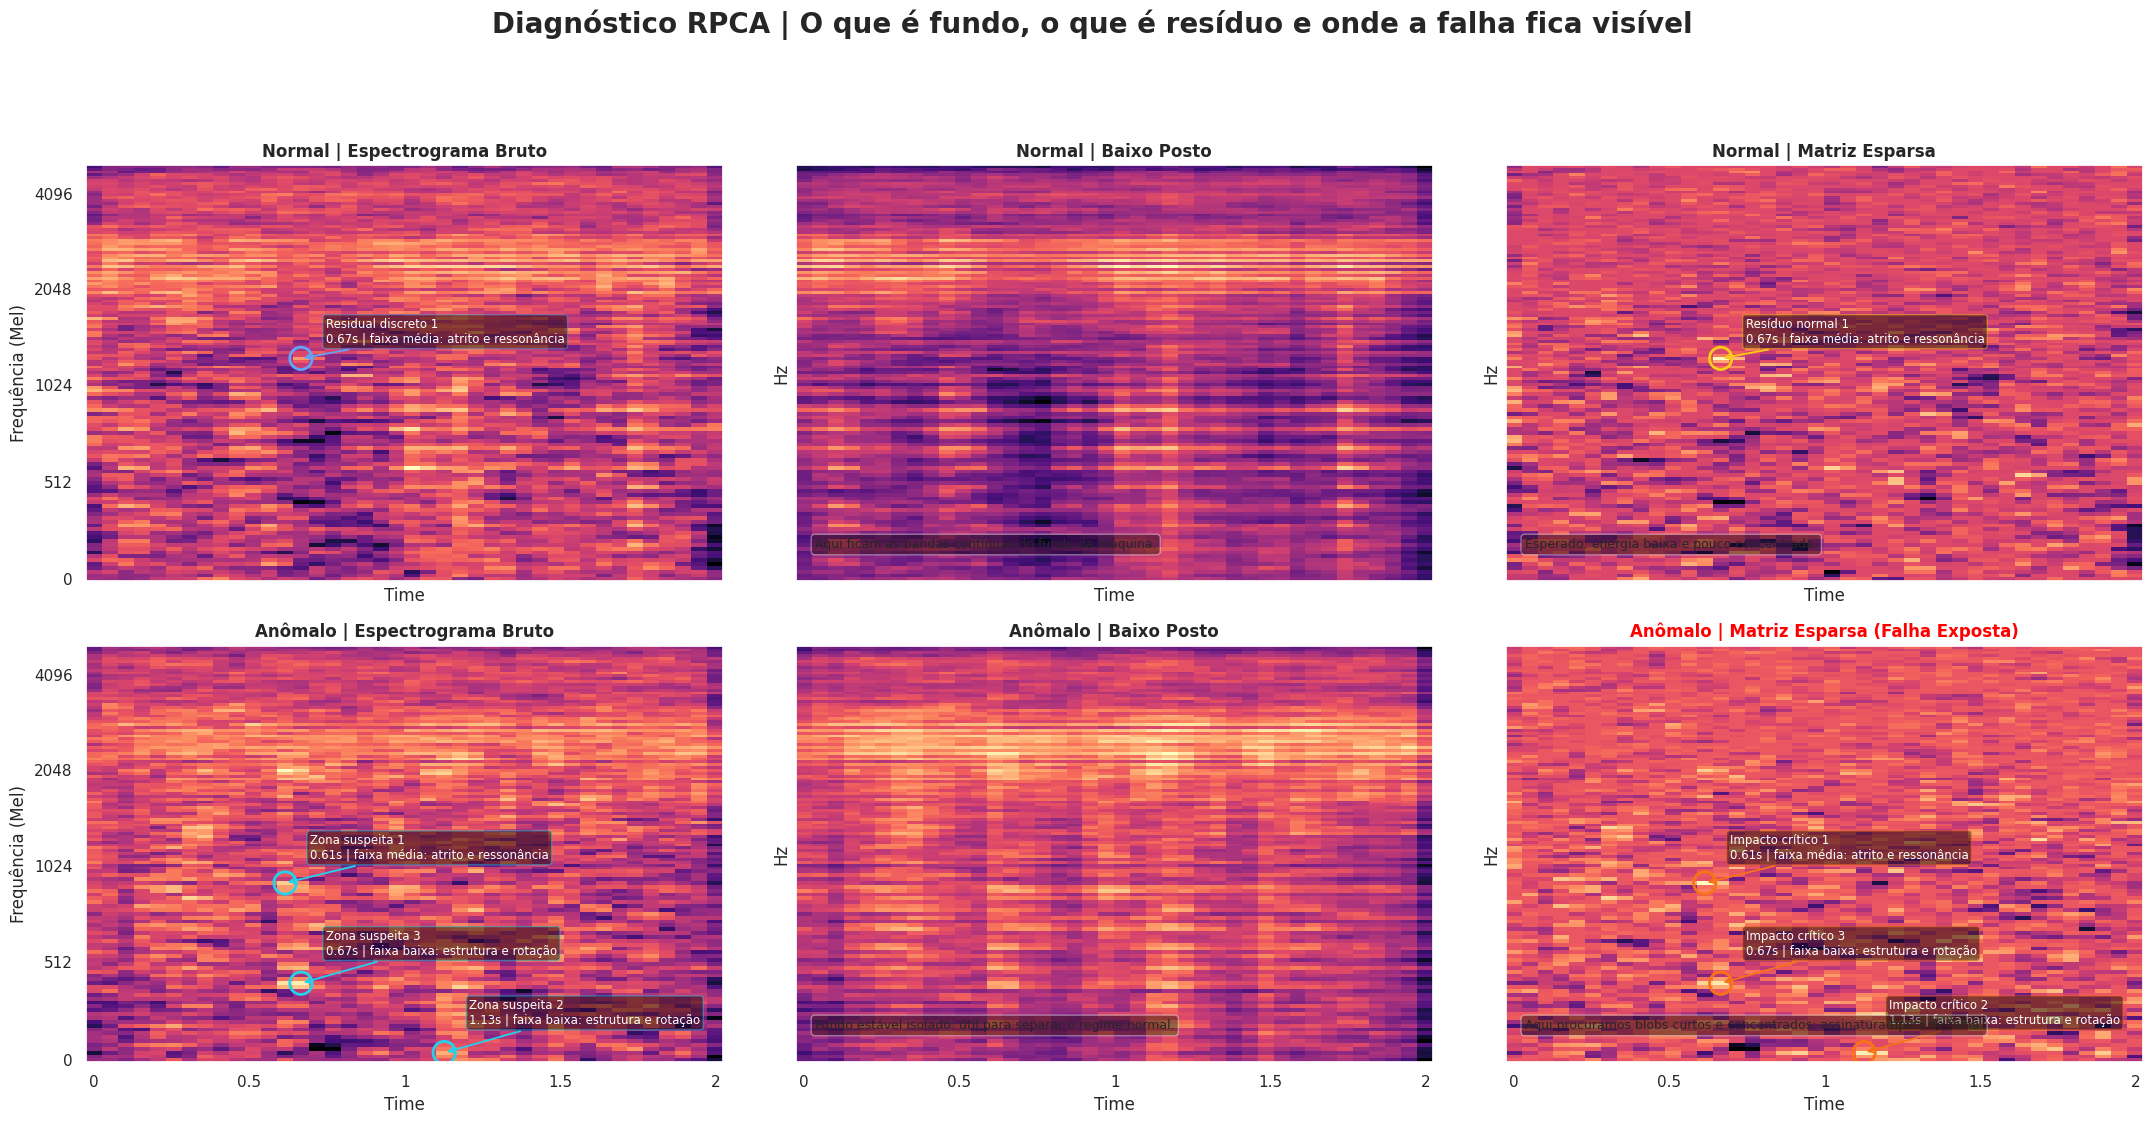

,Hotspot,Tempo (s),Faixa relevante,Intensidade,Leitura técnica
0,H1,0.614,faixa média: atrito e ressonância,5.4065,"pico impulsivo localizado, forte candidato a e..."
1,H2,1.126,faixa baixa: estrutura e rotação,4.9918,"pico impulsivo localizado, forte candidato a e..."
2,H3,0.666,faixa baixa: estrutura e rotação,4.7455,"pico impulsivo localizado, forte candidato a e..."



 📊 LEITURA DIDÁTICA DO RPCA
1. Espectrograma bruto: mostra tudo misturado — operação normal, ruído de fundo e possíveis impactos.
2. Baixo posto (L): concentra o conteúdo persistente e quase estacionário da máquina.
3. Matriz esparsa (S): concentra eventos raros, curtos e localizados — exatamente onde a falha costuma aparecer.
4. Os círculos marcam os pontos com maior energia residual; esses pontos merecem inspeção técnica e explicação XAI.


In [18]:
# =========================================================
# DIAGNÓSTICO VISUAL: DECOMPOSIÇÃO RPCA (L + S) COM LEITURA DIDÁTICA
# =========================================================

idx_normal = -1
normal_indices = np.where(y_train_dsp == 0)[0]
if len(normal_indices) > 0:
    idx_normal = normal_indices[0]
    signal_normal = X_train_dsp_signals[idx_normal]
else:
    signal_normal = None
    print("Aviso: Nenhum sinal 'Normal' encontrado em y_train_dsp para visualização RPCA.")

idx_anomaly = -1
anomaly_indices = np.where(y_train_dsp == 1)[0]
if len(anomaly_indices) > 0:
    idx_anomaly = anomaly_indices[0]
    signal_anomaly = X_train_dsp_signals[idx_anomaly]
else:
    signal_anomaly = None
    print("Aviso: Nenhum sinal 'Anômalo' encontrado em y_train_dsp para visualização RPCA.")

sr_visual = SR_TARGET
hop_visual = 512

if signal_normal is not None and signal_anomaly is not None:
    print(f"✅ Sinais localizados! Normal (index {idx_normal}), Anômalo (index {idx_anomaly})")
    print(f"🔬 Frente DSP ativa no pipeline: {globals().get('DSP_FRONT_ATIVO_LABEL', 'HHT')}")
    print("📦 Base usada nesta seção: `X_train_dsp_signals`")
elif signal_anomaly is not None:
    print(f"✅ Sinal anômalo localizado (index {idx_anomaly}). Nenhum sinal normal para comparação.")
else:
    print("❌ Erro: Nenhum sinal útil foi localizado para visualização RPCA.")


def describe_band(mel_idx, n_mels):
    ratio = mel_idx / max(1, n_mels - 1)
    if ratio < 0.33:
        return 'faixa baixa: estrutura e rotação'
    if ratio < 0.66:
        return 'faixa média: atrito e ressonância'
    return 'faixa alta: impacto rápido'


def find_top_hotspots(matrix, top_k=3, quantile=0.97, min_frame_gap=5, min_mel_gap=8):
    magnitude = np.abs(np.asarray(matrix, dtype=np.float32))
    if magnitude.size == 0 or np.max(magnitude) <= 0:
        return []

    threshold = np.quantile(magnitude, quantile)
    candidates = np.argwhere(magnitude >= threshold)
    if len(candidates) == 0:
        return []

    scores = magnitude[candidates[:, 0], candidates[:, 1]]
    order = np.argsort(scores)[::-1]
    hotspots = []
    for idx in order:
        mel_idx, frame_idx = candidates[idx]
        too_close = any(
            abs(frame_idx - h['frame_idx']) < min_frame_gap and abs(mel_idx - h['mel_idx']) < min_mel_gap
            for h in hotspots
        )
        if too_close:
            continue

        hotspots.append(
            {
                'mel_idx': int(mel_idx),
                'frame_idx': int(frame_idx),
                'score': float(magnitude[mel_idx, frame_idx]),
            }
        )
        if len(hotspots) >= top_k:
            break

    return hotspots


def hotspot_to_plot_coords(matrix, hotspot, sr=10000, hop_length=512):
    mel_freqs = librosa.mel_frequencies(n_mels=matrix.shape[0], fmax=sr / 2)
    time_value = librosa.frames_to_time(hotspot['frame_idx'], sr=sr, hop_length=hop_length)
    freq_value = float(mel_freqs[hotspot['mel_idx']])
    return time_value, freq_value


def annotate_hotspots(ax, matrix, hotspots, label_prefix, color):
    for i, hotspot in enumerate(hotspots, start=1):
        time_value, freq_value = hotspot_to_plot_coords(matrix, hotspot, sr=sr_visual, hop_length=hop_visual)
        band_label = describe_band(hotspot['mel_idx'], matrix.shape[0])
        ax.scatter([time_value], [freq_value], s=260, facecolors='none', edgecolors=color, linewidths=2)
        ax.annotate(
            f"{label_prefix} {i}\n{time_value:.2f}s | {band_label}",
            xy=(time_value, freq_value),
            xytext=(time_value + 0.08, freq_value + 150),
            fontsize=8.5,
            color='white',
            arrowprops=dict(arrowstyle='->', color=color, lw=1.3),
            bbox=dict(boxstyle='round,pad=0.25', fc='black', ec=color, alpha=0.45),
        )


mel_db_normal = None
if signal_normal is not None:
    mel_db_normal = librosa.power_to_db(
        librosa.feature.melspectrogram(
            y=signal_normal,
            sr=sr_visual,
            n_fft=2048,
            hop_length=hop_visual,
            n_mels=128,
        ),
        ref=np.max,
    )

mel_db_anomaly = None
if signal_anomaly is not None:
    mel_db_anomaly = librosa.power_to_db(
        librosa.feature.melspectrogram(
            y=signal_anomaly,
            sr=sr_visual,
            n_fft=2048,
            hop_length=hop_visual,
            n_mels=128,
        ),
        ref=np.max,
    )

print("⚙️ Decompondo sinais via RPCA...")
L_db_normal, S_db_normal = (rpca_ialm(mel_db_normal) if mel_db_normal is not None else (None, None))
L_db_anomaly, S_db_anomaly = (rpca_ialm(mel_db_anomaly) if mel_db_anomaly is not None else (None, None))

rpca_hotspots_normal = find_top_hotspots(np.maximum(S_db_normal, 0), top_k=1, quantile=0.995) if S_db_normal is not None else []
rpca_hotspots_anomaly = find_top_hotspots(np.maximum(S_db_anomaly, 0), top_k=3, quantile=0.97) if S_db_anomaly is not None else []

fig, ax = plt.subplots(2, 3, figsize=(22, 11), sharex=True, sharey=True)

if mel_db_normal is not None:
    librosa.display.specshow(mel_db_normal, sr=sr_visual, hop_length=hop_visual, x_axis='time', y_axis='mel', ax=ax[0, 0], cmap='magma')
    ax[0, 0].set_title('Normal | Espectrograma Bruto', fontsize=12, fontweight='bold')
    annotate_hotspots(ax[0, 0], mel_db_normal, rpca_hotspots_normal, 'Residual discreto', '#60a5fa')
else:
    ax[0, 0].set_title('Normal | Espectrograma Bruto (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')
ax[0, 0].set_ylabel('Frequência (Mel)')

if L_db_normal is not None:
    librosa.display.specshow(L_db_normal, sr=sr_visual, hop_length=hop_visual, x_axis='time', y_axis='mel', ax=ax[0, 1], cmap='magma')
    ax[0, 1].set_title('Normal | Baixo Posto', fontsize=12, fontweight='bold')
    ax[0, 1].text(0.03, 0.08, 'Aqui ficam as bandas contínuas do fundo da máquina.', transform=ax[0, 1].transAxes, fontsize=9, bbox=dict(boxstyle='round', fc='black', ec='white', alpha=0.4))
else:
    ax[0, 1].set_title('Normal | Baixo Posto (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')

if S_db_normal is not None:
    librosa.display.specshow(S_db_normal, sr=sr_visual, hop_length=hop_visual, x_axis='time', y_axis='mel', ax=ax[0, 2], cmap='magma')
    ax[0, 2].set_title('Normal | Matriz Esparsa', fontsize=12, fontweight='bold')
    annotate_hotspots(ax[0, 2], S_db_normal, rpca_hotspots_normal, 'Resíduo normal', '#facc15')
    ax[0, 2].text(0.03, 0.08, 'Esperado: energia baixa e pouco concentrada.', transform=ax[0, 2].transAxes, fontsize=9, bbox=dict(boxstyle='round', fc='black', ec='white', alpha=0.4))
else:
    ax[0, 2].set_title('Normal | Matriz Esparsa (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')

if mel_db_anomaly is not None:
    librosa.display.specshow(mel_db_anomaly, sr=sr_visual, hop_length=hop_visual, x_axis='time', y_axis='mel', ax=ax[1, 0], cmap='magma')
    ax[1, 0].set_title('Anômalo | Espectrograma Bruto', fontsize=12, fontweight='bold')
    annotate_hotspots(ax[1, 0], mel_db_anomaly, rpca_hotspots_anomaly, 'Zona suspeita', '#22d3ee')
else:
    ax[1, 0].set_title('Anômalo | Espectrograma Bruto (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')
ax[1, 0].set_ylabel('Frequência (Mel)')

if L_db_anomaly is not None:
    librosa.display.specshow(L_db_anomaly, sr=sr_visual, hop_length=hop_visual, x_axis='time', y_axis='mel', ax=ax[1, 1], cmap='magma')
    ax[1, 1].set_title('Anômalo | Baixo Posto', fontsize=12, fontweight='bold')
    ax[1, 1].text(0.03, 0.08, 'Fundo estável isolado: útil para separar o regime normal.', transform=ax[1, 1].transAxes, fontsize=9, bbox=dict(boxstyle='round', fc='black', ec='white', alpha=0.4))
else:
    ax[1, 1].set_title('Anômalo | Baixo Posto (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')

if S_db_anomaly is not None:
    librosa.display.specshow(S_db_anomaly, sr=sr_visual, hop_length=hop_visual, x_axis='time', y_axis='mel', ax=ax[1, 2], cmap='magma')
    ax[1, 2].set_title('Anômalo | Matriz Esparsa (Falha Exposta)', fontsize=12, fontweight='bold', color='red')
    annotate_hotspots(ax[1, 2], S_db_anomaly, rpca_hotspots_anomaly, 'Impacto crítico', '#f97316')
    ax[1, 2].text(0.03, 0.08, 'Aqui procuramos blobs curtos e concentrados: assinatura típica de falha.', transform=ax[1, 2].transAxes, fontsize=9, bbox=dict(boxstyle='round', fc='black', ec='white', alpha=0.4))
else:
    ax[1, 2].set_title('Anômalo | Matriz Esparsa (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')

plt.suptitle('Diagnóstico RPCA | O que é fundo, o que é resíduo e onde a falha fica visível', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

if rpca_hotspots_anomaly:
    df_rpca_hotspots = pd.DataFrame(
        [
            {
                'Hotspot': f'H{i}',
                'Tempo (s)': round(hotspot_to_plot_coords(S_db_anomaly, hotspot, sr=sr_visual, hop_length=hop_visual)[0], 3),
                'Faixa relevante': describe_band(hotspot['mel_idx'], S_db_anomaly.shape[0]),
                'Intensidade': round(hotspot['score'], 4),
                'Leitura técnica': 'pico impulsivo localizado, forte candidato a evento anômalo',
            }
            for i, hotspot in enumerate(rpca_hotspots_anomaly, start=1)
        ]
    )
    display(df_rpca_hotspots)

print("\n" + "=" * 96)
print(" 📊 LEITURA DIDÁTICA DO RPCA")
print("=" * 96)
print("1. Espectrograma bruto: mostra tudo misturado — operação normal, ruído de fundo e possíveis impactos.")
print("2. Baixo posto (L): concentra o conteúdo persistente e quase estacionário da máquina.")
print("3. Matriz esparsa (S): concentra eventos raros, curtos e localizados — exatamente onde a falha costuma aparecer.")
print("4. Os círculos marcam os pontos com maior energia residual; esses pontos merecem inspeção técnica e explicação XAI.")
print("=" * 96)


# 8. Implementação dos Modelos (Benchmarking Duplo)

* **Supervisionados:** XGBoost, GRU.
* **Não Supervisionados:** LSTM-AE, Tiny-AST (simulado via CNN-Transformer block).


In [19]:
# =========================================================
# 🧠 ARQUITETURAS DE DEEP LEARNING (PYTORCH) - REVISADAS
# =========================================================

# ---------------------------------------------------------
# A. GRU Model (Supervisionado)
# ---------------------------------------------------------
class AnomalyGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, output_dim=1):
        super(AnomalyGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.gru(x, h0)
        # Pega a última saída da sequência
        out = self.fc(out[:, -1, :])
        return out

# ---------------------------------------------------------
# B. LSTM Autoencoder Model (Não-Supervisionado)
# ---------------------------------------------------------
class LSTMAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2):
        super(LSTMAE, self).__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        # O decoder precisa reconstruir a dimensão original (input_dim)
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers, batch_first=True)

    def forward(self, x):
        enc_out, (h_n, c_n) = self.encoder(x)
        dec_out, _ = self.decoder(enc_out)
        return dec_out

# ---------------------------------------------------------
# C. VAE Convolucional Leve (Não-Supervisionado)
# ---------------------------------------------------------
class ConvVAE(nn.Module):
    def __init__(self, input_channels=1, input_h=64, input_w=64, latent_dim=24, base_channels=16):
        super(ConvVAE, self).__init__()
        self.input_channels = input_channels
        self.input_h = input_h
        self.input_w = input_w
        self.latent_dim = latent_dim
        self.base_channels = base_channels

        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, base_channels, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, input_h, input_w)
            encoded = self.encoder(dummy)
            self.encoded_shape = encoded.shape[1:]
            self.flat_dim = int(encoded.numel())

        self.fc_mu = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flat_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(base_channels, input_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
        )

    def encode(self, x):
        hidden = self.encoder(x).flatten(1)
        mu = self.fc_mu(hidden)
        logvar = self.fc_logvar(hidden)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + (eps * std)

    def decode(self, z):
        hidden = self.fc_decode(z).view(-1, *self.encoded_shape)
        return self.decoder(hidden)

    def forward(self, x, deterministic=False):
        mu, logvar = self.encode(x)
        z = mu if deterministic else self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar


# ---------------------------------------------------------
# D. Tiny-AST Model (Híbrido CNN + Transformer)
# ---------------------------------------------------------
class TinyAST(nn.Module):
    def __init__(self, input_channels=1, output_channels=1, num_mels=64, time_steps=64,
                 embed_dim=128, num_heads=4, num_transformer_layers=2):
        super(TinyAST, self).__init__()

        self.num_mels = num_mels
        self.time_steps = time_steps

        # --- ENCODER CNN ---
        self.conv_encoder = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Cálculo dinâmico das dimensões latentes
        self.latent_h = num_mels // 4
        self.latent_w = time_steps // 4
        self.flat_dim = 64 * self.latent_h * self.latent_w

        self.project_to_embed = nn.Linear(self.flat_dim, embed_dim)

        # --- TRANSFORMER (Atenção Global) ---
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)

        # --- DECODER CNN ---
        self.project_from_embed = nn.Linear(embed_dim, self.flat_dim)
        self.conv_decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, output_channels, kernel_size=2, stride=2)
        )

    def forward(self, x):
        batch_size = x.size(0)

        # 1. Encoder CNN
        x_enc = self.conv_encoder(x) # Shape: (B, 64, H/4, W/4)

        # 2. Transformer no espaço latente achatado
        x_flat = x_enc.view(batch_size, -1)
        x_embed = self.project_to_embed(x_flat).unsqueeze(1)
        x_trans = self.transformer_encoder(x_embed).squeeze(1)

        # 3. Decoder CNN
        x_dec_flat = self.project_from_embed(x_trans)
        x_dec_reshaped = x_dec_flat.view(batch_size, 64, self.latent_h, self.latent_w)
        x_out = self.conv_decoder(x_dec_reshaped)

        return x_out


# 9 - XAI e leitura física do espectrograma
Nesta etapa a análise visual fica mais didática e mais próxima da leitura manual que faríamos em bancada:

- `H1`, `H2` e `H3` marcam os hotspots que mais pesaram para a decisão do modelo.
- o retângulo de zoom mostra a região de maior confiança visual da anomalia.
- a curva temporal ajuda a entender se a evidência é um impacto isolado, um trem de pulsos ou um decaimento.
- o perfil por banda mostra se a energia suspeita está concentrada em baixa, média ou alta frequência.


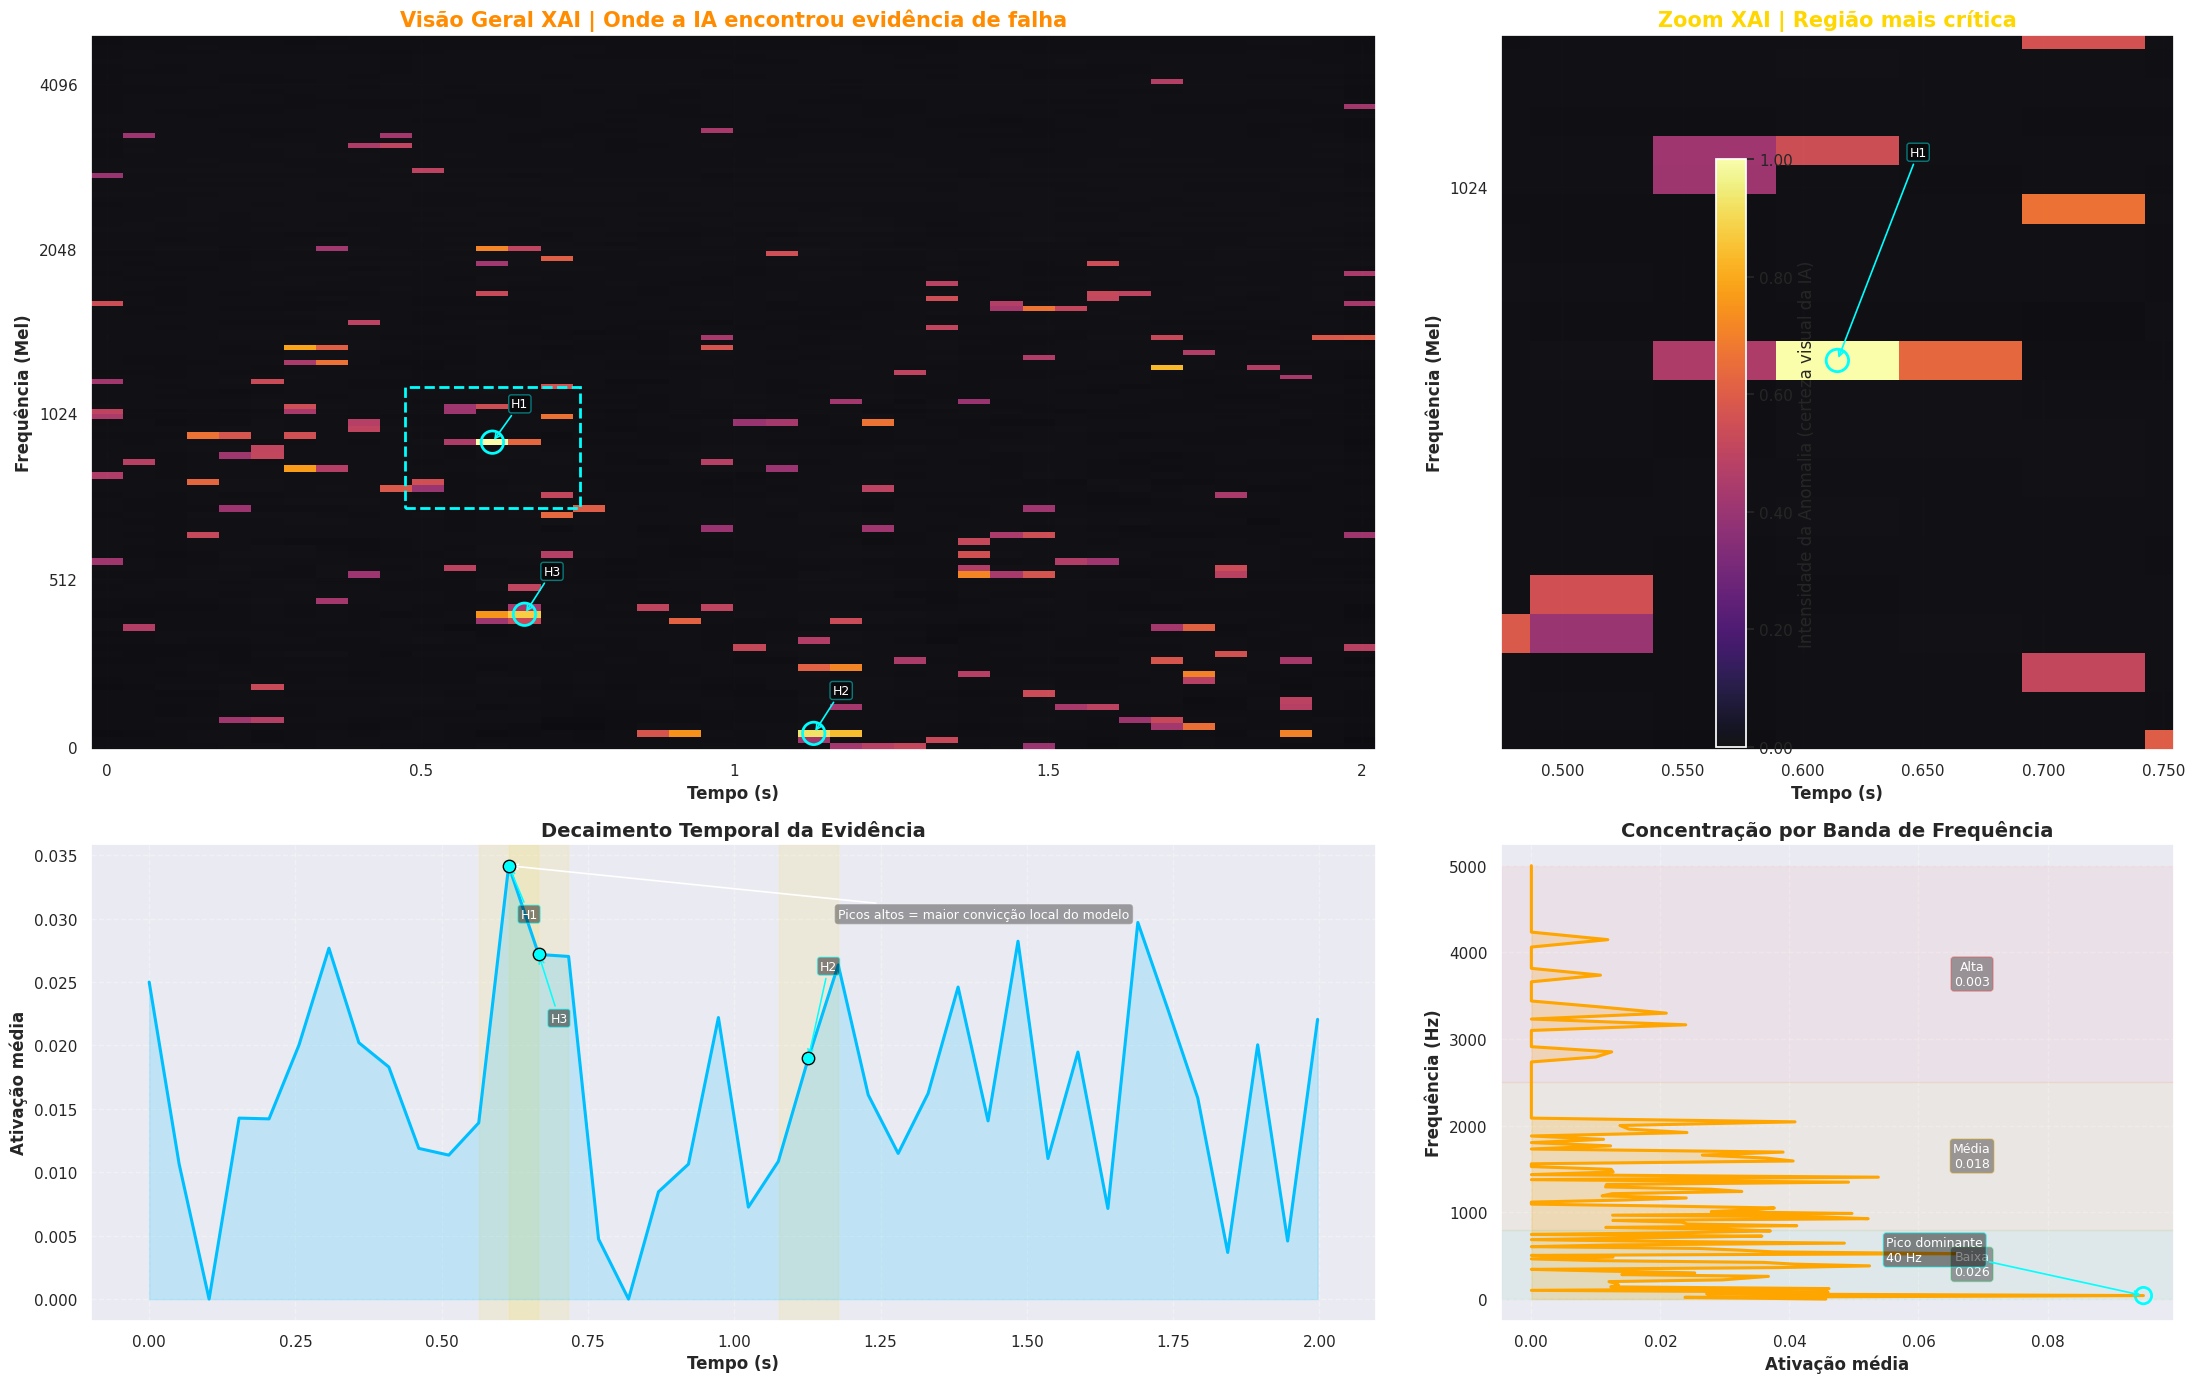

,Hotspot,Tempo (s),Faixa relevante,Intensidade normalizada,Leitura XAI
0,H1,0.614,faixa média: atrito e ressonância,5.4065,impacto principal: ponto que mais sustentou a ...
1,H2,1.126,faixa baixa: estrutura e rotação,4.9918,harmônico/resposta adjacente: reforça repetiçã...
2,H3,0.666,faixa baixa: estrutura e rotação,4.7455,eco temporal: sugere recorrência do mesmo meca...


,Faixa,Hz,Ativação média
0,Baixa,0-800,0.0258
1,Média,800-2500,0.0177
2,Alta,2500-4999,0.0031



 ✅ VISUALIZAÇÃO XAI CONCLUÍDA
1. O mapa em inferno mostra onde a IA encontrou evidência acima do limiar.
2. H1/H2/H3 destacam o núcleo da decisão, os reforços harmônicos e a recorrência temporal.
3. A curva temporal indica se a anomalia é curta, repetitiva ou com cauda de decaimento.
4. O perfil por banda mostra em qual faixa de frequência a falha concentrou mais energia.


In [20]:
xai_activation = np.maximum(S_db_anomaly, 0)
max_val = np.max(xai_activation)
if max_val > 0:
    xai_activation = xai_activation / max_val

xai_activation = np.where(xai_activation > 0.4, xai_activation, 0)
xai_hotspots = rpca_hotspots_anomaly if 'rpca_hotspots_anomaly' in globals() and len(rpca_hotspots_anomaly) > 0 else find_top_hotspots(xai_activation, top_k=3, quantile=0.96)

time_axis = librosa.frames_to_time(np.arange(xai_activation.shape[1]), sr=sr_visual, hop_length=hop_visual)
mel_freqs = librosa.mel_frequencies(n_mels=xai_activation.shape[0], fmax=sr_visual / 2)
time_profile = xai_activation.mean(axis=0)
band_profile = xai_activation.mean(axis=1)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(22, 14),
    gridspec_kw={'width_ratios': [2.1, 1.1], 'height_ratios': [1.5, 1.0]},
)

overview_ax = axes[0, 0]
zoom_ax = axes[0, 1]
decay_ax = axes[1, 0]
band_ax = axes[1, 1]

for ax in [overview_ax, zoom_ax]:
    librosa.display.specshow(
        mel_db_anomaly,
        sr=sr_visual,
        hop_length=hop_visual,
        x_axis='time',
        y_axis='mel',
        ax=ax,
        cmap='gray',
        alpha=0.28,
    )
    img = librosa.display.specshow(
        xai_activation,
        sr=sr_visual,
        hop_length=hop_visual,
        x_axis='time',
        y_axis='mel',
        ax=ax,
        cmap='inferno',
        alpha=0.92,
    )
    ax.set_ylabel('Frequência (Mel)', fontweight='bold')
    ax.set_xlabel('Tempo (s)', fontweight='bold')

overview_ax.set_title('Visão Geral XAI | Onde a IA encontrou evidência de falha', fontsize=15, fontweight='bold', color='darkorange')
zoom_ax.set_title('Zoom XAI | Região mais crítica', fontsize=15, fontweight='bold', color='gold')

zoom_rect = None
df_xai_hotspots = None

if xai_hotspots:
    main_hotspot = xai_hotspots[0]
    main_time, main_freq = hotspot_to_plot_coords(xai_activation, main_hotspot, sr=sr_visual, hop_length=hop_visual)

    x0 = max(0.0, main_time - 0.14)
    x1 = min(librosa.frames_to_time(xai_activation.shape[1], sr=sr_visual, hop_length=hop_visual), main_time + 0.14)
    y0 = max(0.0, float(mel_freqs[max(0, main_hotspot['mel_idx'] - 10)]))
    y1 = min(float(mel_freqs[-1]), float(mel_freqs[min(xai_activation.shape[0] - 1, main_hotspot['mel_idx'] + 10)]))

    zoom_rect = Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2.0, edgecolor='cyan', facecolor='none', linestyle='--')
    overview_ax.add_patch(zoom_rect)
    zoom_ax.set_xlim(x0, x1)
    zoom_ax.set_ylim(y0, y1)

    rows = []
    for i, hotspot in enumerate(xai_hotspots, start=1):
        hotspot_time, hotspot_freq = hotspot_to_plot_coords(xai_activation, hotspot, sr=sr_visual, hop_length=hop_visual)
        band_label = describe_band(hotspot['mel_idx'], xai_activation.shape[0])
        narrative = {
            1: 'impacto principal: ponto que mais sustentou a decisão do modelo',
            2: 'harmônico/resposta adjacente: reforça repetição do defeito',
            3: 'eco temporal: sugere recorrência do mesmo mecanismo físico',
        }.get(i, 'ponto secundário relevante')

        for ax in [overview_ax, zoom_ax]:
            ax.scatter([hotspot_time], [hotspot_freq], s=260, facecolors='none', edgecolors='cyan', linewidths=2)
            ax.annotate(
                f'H{i}',
                xy=(hotspot_time, hotspot_freq),
                xytext=(hotspot_time + 0.03, hotspot_freq + 120),
                fontsize=9,
                color='white',
                arrowprops=dict(arrowstyle='->', color='cyan', lw=1.2),
                bbox=dict(boxstyle='round,pad=0.2', fc='black', ec='cyan', alpha=0.45),
            )

        decay_ax.axvspan(max(0.0, hotspot_time - 0.05), hotspot_time + 0.05, color='gold', alpha=0.10)
        decay_ax.scatter([hotspot_time], [time_profile[min(len(time_profile) - 1, hotspot['frame_idx'])]], s=80, color='cyan', edgecolor='black', zorder=5)
        decay_ax.annotate(
            f'H{i}',
            xy=(hotspot_time, time_profile[min(len(time_profile) - 1, hotspot['frame_idx'])]),
            xytext=(hotspot_time + 0.02, time_profile.max() * (0.88 - (i - 1) * 0.12)),
            fontsize=9,
            color='white',
            arrowprops=dict(arrowstyle='->', color='cyan', lw=1.1),
            bbox=dict(boxstyle='round,pad=0.2', fc='black', ec='cyan', alpha=0.45),
        )

        rows.append(
            {
                'Hotspot': f'H{i}',
                'Tempo (s)': round(hotspot_time, 3),
                'Faixa relevante': band_label,
                'Intensidade normalizada': round(float(hotspot['score']), 4),
                'Leitura XAI': narrative,
            }
        )

    df_xai_hotspots = pd.DataFrame(rows)

decay_ax.plot(time_axis, time_profile, color='deepskyblue', linewidth=2.2)
decay_ax.fill_between(time_axis, 0, time_profile, color='deepskyblue', alpha=0.18)
decay_ax.set_title('Decaimento Temporal da Evidência', fontsize=14, fontweight='bold')
decay_ax.set_xlabel('Tempo (s)', fontweight='bold')
decay_ax.set_ylabel('Ativação média', fontweight='bold')
decay_ax.grid(True, linestyle='--', alpha=0.30)
if np.max(time_profile) > 0:
    decay_ax.annotate(
        'Picos altos = maior convicção local do modelo',
        xy=(time_axis[int(np.argmax(time_profile))], np.max(time_profile)),
        xytext=(time_axis[min(len(time_axis) - 1, int(len(time_axis) * 0.58))], np.max(time_profile) * 0.88),
        fontsize=9,
        color='white',
        arrowprops=dict(arrowstyle='->', color='white', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', fc='black', ec='white', alpha=0.35),
    )

band_ax.plot(band_profile, mel_freqs, color='orange', linewidth=2.2)
band_ax.fill_betweenx(mel_freqs, 0, band_profile, color='orange', alpha=0.20)
band_ax.set_title('Concentração por Banda de Frequência', fontsize=14, fontweight='bold')
band_ax.set_xlabel('Ativação média', fontweight='bold')
band_ax.set_ylabel('Frequência (Hz)', fontweight='bold')
band_ax.grid(True, linestyle='--', alpha=0.30)

freq_regions = [
    ('Baixa', 0.0, 800.0, '#22c55e'),
    ('Média', 800.0, 2500.0, '#eab308'),
    ('Alta', 2500.0, float(mel_freqs[-1]), '#ef4444'),
]
band_rows = []
for label, f0, f1, color in freq_regions:
    mask = (mel_freqs >= f0) & (mel_freqs < f1)
    if np.any(mask):
        region_energy = float(np.mean(band_profile[mask]))
        band_ax.axhspan(f0, f1, color=color, alpha=0.06)
        band_ax.text(
            band_profile.max() * 0.72 if band_profile.max() > 0 else 0.01,
            (f0 + f1) / 2,
            f'{label}\n{region_energy:.3f}',
            fontsize=9,
            color='white',
            va='center',
            ha='center',
            bbox=dict(boxstyle='round,pad=0.25', fc='black', ec=color, alpha=0.35),
        )
        band_rows.append({'Faixa': label, 'Hz': f'{int(f0)}-{int(f1)}', 'Ativação média': round(region_energy, 4)})

if np.max(band_profile) > 0:
    peak_idx = int(np.argmax(band_profile))
    peak_freq = float(mel_freqs[peak_idx])
    peak_energy = float(band_profile[peak_idx])
    band_ax.scatter([peak_energy], [peak_freq], s=140, facecolors='none', edgecolors='cyan', linewidths=2)
    band_ax.annotate(
        f'Pico dominante\n{peak_freq:.0f} Hz',
        xy=(peak_energy, peak_freq),
        xytext=(peak_energy * 0.58 + 1e-6, min(float(mel_freqs[-1]), peak_freq + 400)),
        fontsize=9,
        color='white',
        arrowprops=dict(arrowstyle='->', color='cyan', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.25', fc='black', ec='cyan', alpha=0.45),
    )

df_xai_bandas = pd.DataFrame(band_rows)

plt.colorbar(img, ax=[overview_ax, zoom_ax], format='%.2f', label='Intensidade da Anomalia (certeza visual da IA)')
plt.tight_layout()
plt.show()

if df_xai_hotspots is not None:
    display(df_xai_hotspots)
if not df_xai_bandas.empty:
    display(df_xai_bandas)

print("\n" + "=" * 88)
print(" ✅ VISUALIZAÇÃO XAI CONCLUÍDA")
print("=" * 88)
print("1. O mapa em inferno mostra onde a IA encontrou evidência acima do limiar.")
print("2. H1/H2/H3 destacam o núcleo da decisão, os reforços harmônicos e a recorrência temporal.")
print("3. A curva temporal indica se a anomalia é curta, repetitiva ou com cauda de decaimento.")
print("4. O perfil por banda mostra em qual faixa de frequência a falha concentrou mais energia.")
print("=" * 88)


# 10. Frentes 5, 6, 7, 8, 8.2, 8.3 e 8.4 | Avaliação estrita, protocolo industrial, OE real e baselines incrementais
Esta etapa combina sete camadas complementares:

- a `Frente 5 - Avaliação Estrita` mede `pAUC@0.1`, `AUC-ROC`, `F1-Score` e `Score DCASE Proxy`;
- a `Frente 6 - Protocolo Industrial Sem Vazamento` abandona o split aleatório por janela e passa a separar treino/teste por `arquivo de origem`;
- a `Frente 7 - Outlier Exposure Real` permite adicionar fontes externas reais de áudio como exemplos fora da distribuição, via `AAD_OE_DIRS` ou descoberta automática do DCASE com `AAD_OE_DCASE_ROOTS`;
- a `Frente 8 - Baselines Não Supervisionados Incrementais` adiciona detectores leves e interpretáveis para medir se o ganho vem de redes profundas ou da própria geometria das features;
- a `Frente 8.2 - LSTM-AE Incremental com Promoção Condicional` testa um autoencoder sequencial leve nas representações imagem->sequência e só o libera para o restante do notebook se ele realmente superar os não supervisionados já existentes;
- a `Frente 8.3 - VAE Incremental com Promoção Condicional` testa um `Variational Autoencoder` convolucional leve, ainda na trilha não supervisionada, e também só o leva adiante se houver ganho real;
- a `Frente 8.4 - Exp 6 (STFT Log 64x64)` adiciona uma nova representação de imagem espectral, mais bruta que o Mel, para medir se um espectro logarítmico padronizado em `64x64` entrega ganho real no benchmark.

Nesta primeira versão da `Frente 8`, os novos baselines entram apenas nos `experimentos vetoriais`, preservando memória e facilitando uma leitura incremental dos resultados:

- `Isolation Forest (Não-Sup.)`;
- `Mahalanobis (Não-Sup.)`;
- ambos usam a mesma lógica de limiar estrito: `Gamma + FPR alvo`, com endurecimento via `Mixup` e `OE real` quando disponível;
- isso permite comparar, de forma honesta, um `GMM` clássico contra dois detectores leves extras sem precisar subir imediatamente a complexidade do pipeline.

Em termos práticos, a `Frente 8` é a camada ideal para este momento do projeto: barata, cumulativa e boa para confirmar se as métricas estão melhorando por `features + protocolo + calibração`, e não apenas por aumento de capacidade do modelo.

A `Frente 8.2` entra um passo acima: ela testa um `LSTM-AE` somente nas representações sequenciais dos experimentos de imagem, gera relatório incremental próprio e decide automaticamente se merece ou não participar da validação final.

A `Frente 8.3` faz um movimento parecido, mas com um `VAE` leve sobre as imagens acústicas. Isso faz sentido neste pipeline porque `Mel`, `CWT` e os híbridos visuais já estão em formato matricial, então o `VAE` consegue aprender uma distribuição compacta do comportamento normal sem exigir um backbone pesado. Como o projeto está avançando de forma incremental, ele também entra com promoção condicional: se não trouxer ganho, não contamina a validação final.

A `Frente 8.4` não cria um novo modelo: ela cria um novo **experimento de imagem**, o `Exp 6`, usando `STFT log 64x64`. Isso permite comparar uma visão espectral mais direta contra `Mel` e `CWT` sem estourar a memória, porque o tensor continua padronizado em `64x64` e pode ser desligado se você quiser uma rodada mais leve.


⚙️ Iniciando ETAPA 1: A Força Bruta (Construção das Matrizes dos 6 Experimentos + Frente 4 Mixup + Frente 8.4 STFT)...
🧪 Frente DSP padrão desta execução: HHT + UKF
🔬 A Frente 5 pode avaliar apenas a frente ativa ou comparar várias frentes DSP na mesma rodada.

🧱 Frente 6 | Protocolo de avaliação industrial
   -> Modo selecionado: holdout agrupado por arquivo de origem

🛰️ Frente 7 | Outlier Exposure real
   -> Inativa nesta execução. Para ativar, aponte `AAD_OE_DIRS` para diretórios externos reais ou `AAD_OE_DCASE_ROOTS` para a raiz do DCASE.

🖼️ Frente 8.4 | Exp 6 STFT Log 64x64
   -> Status: ATIVA | n_fft=512 | hop=128 | tensor=64x64

🧾 Plano de benchmark DSP para a Frente 5:


,Frente DSP (ID),Frente DSP,Status
0,hht_ukf,HHT + UKF,ativa e benchmarkada



🧠 Construindo dataset estrutural para a frente DSP: HHT + UKF
   -> Reaproveitando os sinais já processados na seção de DSP.
   -> Fatiando áudios pós-DSP com janela deslizante...


Fatiando Janelas: 100%|██████████| 750/750 [00:00<00:00, 101390.06áudio/s]



🧱 Frente 6 ativa: treino/teste separados por arquivo de origem.


,Split,Classe,Arquivos,Janelas
0,Teste,Anômalo,150,150
1,Teste,Normal,75,75
2,Treino,Anômalo,350,350
3,Treino,Normal,175,175


   -> Extraindo features estruturais para 750 fatias...


Extraindo Experimentos | HHT + UKF: 100%|██████████| 750/750 [05:04<00:00,  2.46fatia/s]



[Prévia Didática] Frente 4 Mixup na frente DSP de referência...


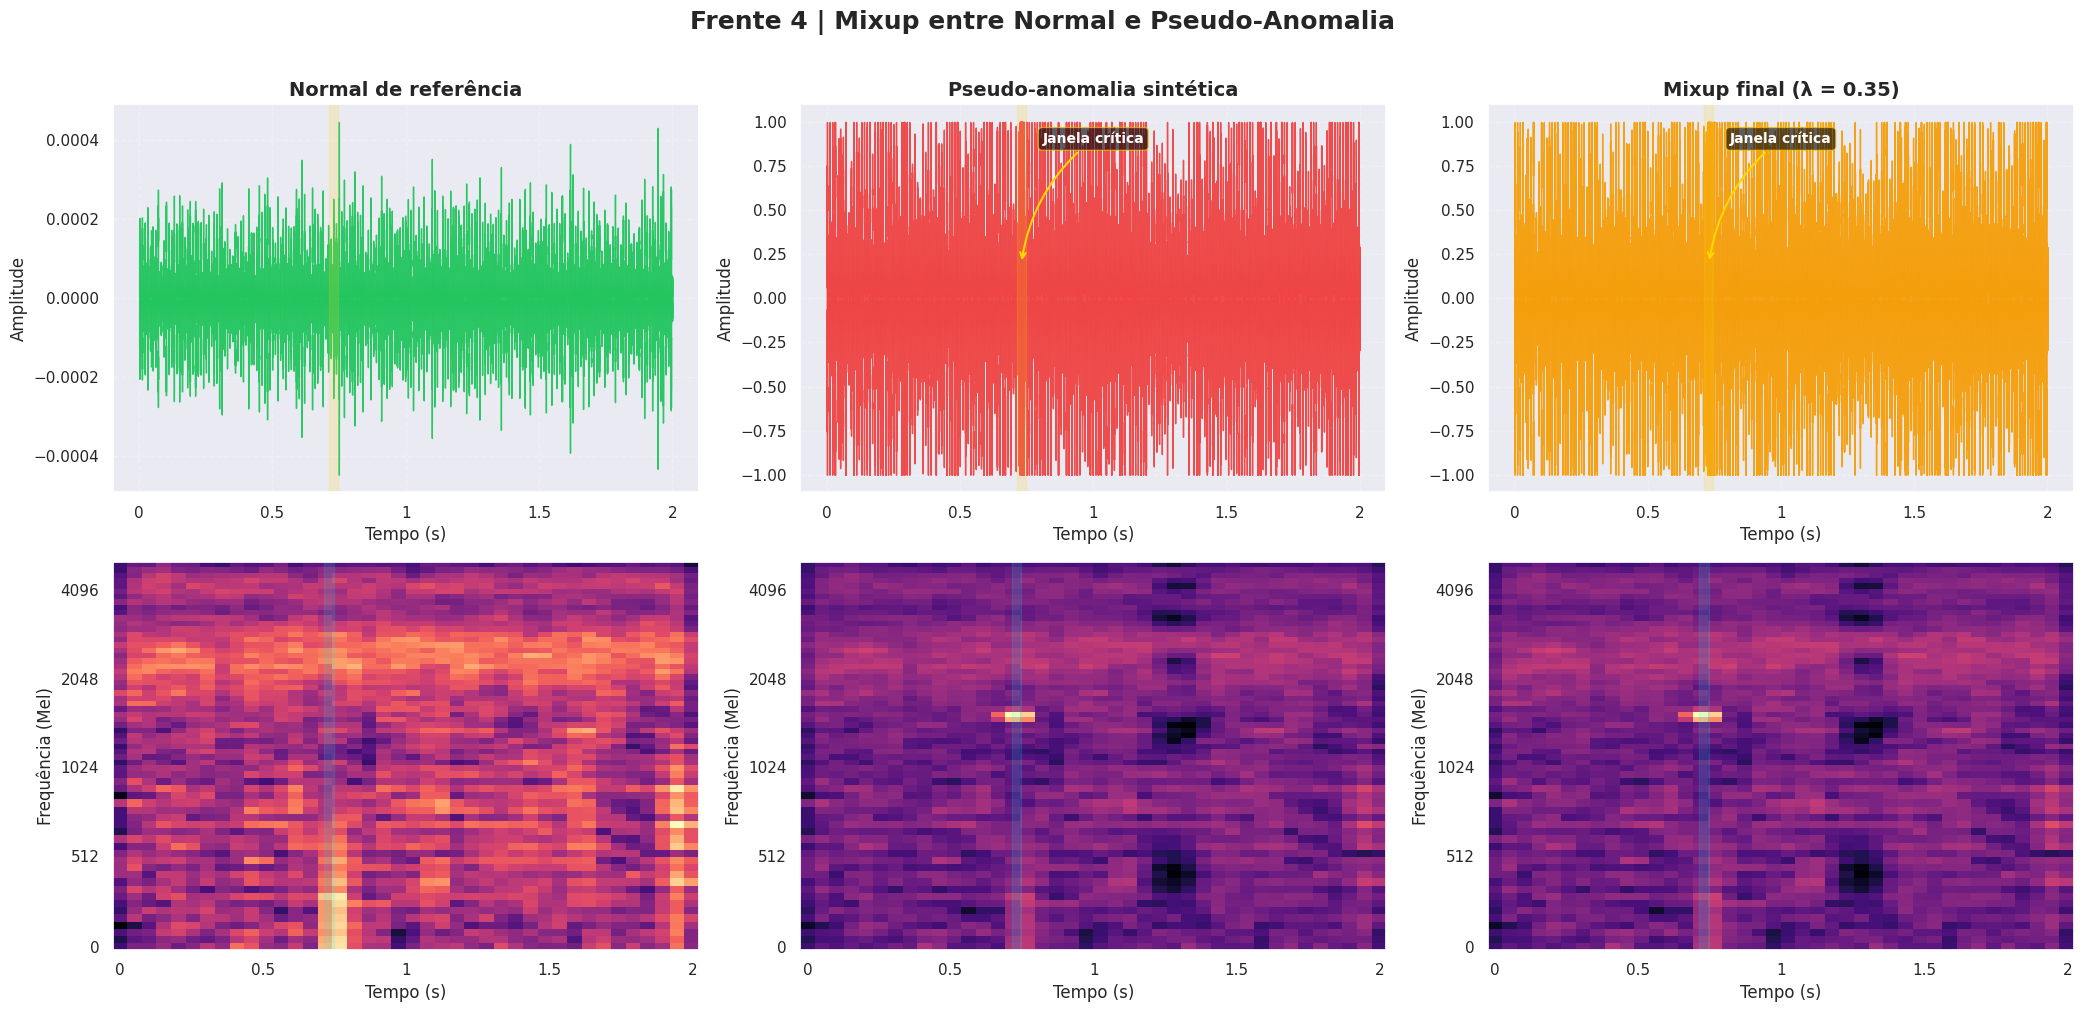

,Sinal,Leitura
0,Normal,Referência da máquina sem defeito explícito
1,Pseudo-anomalia,"Evento sintético entre 0.713s e 0.747s, com po..."
2,Mixup,Combinação convexa com λ=0.35; serve para ensi...


Extraindo Experimentos Mixup | HHT + UKF: 100%|██████████| 35/35 [00:13<00:00,  2.64fatia/s]

   -> Frente HHT + UKF pronta: 750 janelas | Mixup treino: 35 | OE real: 0


,Amostra,Indice_Base,Lambda,Evento (s),Portadora (Hz),Estratégia
0,1,125,0.8500,1.534-1.606,529.3,burst + embaralhamento local
1,2,92,0.3500,0.515-0.598,2063.7,burst + embaralhamento local
2,3,96,0.3500,0.195-0.225,1652.4,burst + inversão local
3,4,133,0.7681,0.182-0.216,1098.1,burst + inversão local
4,5,106,0.3500,0.595-0.670,721.3,burst + inversão local
5,6,151,0.3500,0.343-0.387,2019.7,burst + embaralhamento local
6,7,148,0.3500,1.820-1.894,1276.9,burst + embaralhamento local
7,8,112,0.3500,0.051-0.129,2281.3,burst + embaralhamento local
8,9,20,0.7468,0.379-0.435,307.7,burst + embaralhamento local
9,10,67,0.3500,0.657-0.707,1673.4,burst + deslocamento local



📌 Resumo das frentes DSP preparadas para a Frente 5/6:


,Frente DSP (ID),Frente DSP,Janelas totais,Janelas treino,Janelas teste,Arquivos treino,Arquivos teste,Janelas Mixup (treino),Janelas OE real,Vazamento por arquivo,É a frente ativa?
0,hht_ukf,HHT + UKF,750,525,225,525,225,35,0,0,True



🧾 Auditoria consolidada da Frente 6:


,Split,Classe,Arquivos,Janelas
0,Teste,Anômalo,150,150
1,Teste,Normal,75,75
2,Treino,Anômalo,350,350
3,Treino,Normal,175,175



✅ ETAPA 1 CONCLUÍDA em 323.74 segundos!
------------------------------------------------------------------------
Frentes DSP avaliadas nesta rodada: HHT + UKF
Frente DSP de referência para células legadas: HHT + UKF
Janelas de treino: 525 | Janelas de teste: 225
Protocolo da Frente 6: holdout agrupado por arquivo de origem
Arquivos compartilhados entre treino e teste: 0
Modo multipista DSP: frente única
Frente 4 Mixup ativa: True
Configuração Mixup: razão=0.20 | alpha=0.40 | alvo FPR=0.10
🧹 As features ficaram organizadas por frente DSP em `experimentos_por_frente` para o benchmark comparativo.


In [22]:
print("⚙️ Iniciando ETAPA 1: A Força Bruta (Construção das Matrizes dos 6 Experimentos + Frente 4 Mixup + Frente 8.4 STFT)...")
print(f"🧪 Frente DSP padrão desta execução: {globals().get('DSP_FRONT_ATIVO_LABEL', 'DSP ativa')}")
print("🔬 A Frente 5 pode avaliar apenas a frente ativa ou comparar várias frentes DSP na mesma rodada.")

FRONT84_ENABLE_STFT = os.getenv('AAD_FRONT84_ENABLE_STFT', '1').strip().lower() in {'1', 'true', 'yes', 'sim'}
FRONT84_EXPERIMENT_NAME = 'Exp 6 (STFT Log 64x64)'
FRONT84_STFT_NFFT = int(os.getenv('AAD_FRONT84_STFT_NFFT', '512'))
FRONT84_STFT_HOP = int(os.getenv('AAD_FRONT84_STFT_HOP', '128'))

EXPERIMENT_TYPES = {
    'Exp 1 (Mel + RPCA)': 'imagem',
    'Exp 2 (MFCC Dinâmico)': 'vetor',
    'Exp 3 (CWT + RPCA)': 'imagem',
    'Exp 4 (Híbrido Antigo)': 'vetor',
    'Exp 5 (Híbrido NMF)': 'vetor',
}
if FRONT84_ENABLE_STFT:
    EXPERIMENT_TYPES[FRONT84_EXPERIMENT_NAME] = 'imagem'


def prepare_mel_pair(audio_segment, sr=SR_TARGET, n_mels=64, n_fft=2048, hop_length=512, target_time=64):
    mel_power = librosa.feature.melspectrogram(y=audio_segment, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel_power, ref=np.max)

    if mel_db.shape[1] > target_time:
        mel_db = mel_db[:, :target_time]
        mel_power = mel_power[:, :target_time]
    else:
        mel_db = np.pad(mel_db, ((0, 0), (0, target_time - mel_db.shape[1])))
        mel_power = np.pad(mel_power, ((0, 0), (0, target_time - mel_power.shape[1])))

    return mel_db.astype(np.float32), mel_power.astype(np.float32)


def prepare_stft_log_image(audio_segment, sr=SR_TARGET, n_fft=512, hop_length=128, target_shape=(64, 64)):
    stft_complex = librosa.stft(y=audio_segment, n_fft=n_fft, hop_length=hop_length, win_length=n_fft, center=True)
    stft_power = np.abs(stft_complex) ** 2
    stft_log = librosa.power_to_db(stft_power + 1e-12, ref=np.max)

    zoom_factors = (
        target_shape[0] / max(stft_log.shape[0], 1),
        target_shape[1] / max(stft_log.shape[1], 1),
    )
    stft_resized = zoom(stft_log, zoom_factors, order=1)
    stft_resized = stft_resized[: target_shape[0], : target_shape[1]]

    pad_h = max(0, target_shape[0] - stft_resized.shape[0])
    pad_w = max(0, target_shape[1] - stft_resized.shape[1])
    if pad_h > 0 or pad_w > 0:
        stft_resized = np.pad(stft_resized, ((0, pad_h), (0, pad_w)))

    return stft_resized.astype(np.float32)


def extract_all_experiment_features(audio_segment, sr=SR_TARGET):
    audio_segment = np.asarray(audio_segment, dtype=np.float32)
    mel_db, mel_power = prepare_mel_pair(audio_segment, sr=sr)
    _, S_mel = rpca_ialm(mel_db, max_iter=50)

    mfcc = librosa.feature.mfcc(y=audio_segment, sr=sr, n_mfcc=13)
    mfcc_delta = librosa.feature.delta(mfcc, width=3)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2, width=3)

    mfcc_features = np.concatenate([
        np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
        np.mean(mfcc_delta, axis=1), np.std(mfcc_delta, axis=1),
        np.mean(mfcc_delta2, axis=1), np.std(mfcc_delta2, axis=1)
    ]).astype(np.float32)

    scales = np.geomspace(1, 64, num=64)
    coef, _ = pywt.cwt(audio_segment, scales, 'morl', sampling_period=1 / sr)
    cwt_db = librosa.amplitude_to_db(np.abs(coef), ref=np.max)
    if cwt_db.shape[1] > 64:
        cwt_resized = cwt_db[:, :64]
    else:
        cwt_resized = np.pad(cwt_db, ((0, 0), (0, 64 - cwt_db.shape[1])))
    _, S_cwt = rpca_ialm(cwt_resized, max_iter=50)

    stft_log_img = None
    if FRONT84_ENABLE_STFT:
        stft_log_img = prepare_stft_log_image(
            audio_segment,
            sr=sr,
            n_fft=FRONT84_STFT_NFFT,
            hop_length=FRONT84_STFT_HOP,
            target_shape=(64, 64),
        )

    rms = librosa.feature.rms(y=audio_segment)[0]
    kurtosis_val = stats.kurtosis(audio_segment)
    skewness_val = stats.skew(audio_segment)

    try:
        nmf_model = NMF(n_components=5, init='nndsvda', max_iter=200, random_state=42)
        W = nmf_model.fit_transform(mel_power)
        H = nmf_model.components_
        mel_reconstructed = np.dot(W, H)
        nmf_error = np.mean((mel_power - mel_reconstructed) ** 2)
    except Exception:
        nmf_error = 0.0

    feature_map = {
        'Exp 1 (Mel + RPCA)': S_mel[np.newaxis, ...].astype(np.float32),
        'Exp 2 (MFCC Dinâmico)': mfcc_features,
        'Exp 3 (CWT + RPCA)': S_cwt[np.newaxis, ...].astype(np.float32),
        'Exp 4 (Híbrido Antigo)': np.concatenate([
            mfcc_features,
            [np.mean(rms), np.std(rms), kurtosis_val, skewness_val, np.mean(S_mel)]
        ]).astype(np.float32),
        'Exp 5 (Híbrido NMF)': np.concatenate([
            mfcc_features,
            [np.mean(rms), np.std(rms), kurtosis_val, skewness_val, nmf_error]
        ]).astype(np.float32),
    }
    if FRONT84_ENABLE_STFT and stft_log_img is not None:
        feature_map[FRONT84_EXPERIMENT_NAME] = stft_log_img[np.newaxis, ...].astype(np.float32)
    return feature_map


def build_experiment_feature_bank(audio_segments, desc):
    feature_bank = {name: [] for name in EXPERIMENT_TYPES}
    for audio_segment in tqdm(audio_segments, desc=desc, unit='fatia'):
        feature_map = extract_all_experiment_features(audio_segment, sr=SR_TARGET)
        for exp_name in feature_bank:
            feature_bank[exp_name].append(feature_map[exp_name])

    for exp_name in feature_bank:
        feature_bank[exp_name] = np.array(feature_bank[exp_name], dtype=np.float32)
    return feature_bank


def empty_like_feature_bank(reference_bank):
    return {
        exp_name: np.empty((0,) + reference_bank[exp_name].shape[1:], dtype=np.float32)
        for exp_name in reference_bank
    }


def cap_exposure_windows_by_group(X_windows, metadata_df, max_windows, seed=42):
    X_windows = np.asarray(X_windows, dtype=np.float32)
    metadata_df = metadata_df.reset_index(drop=True).copy()

    if max_windows is None or max_windows <= 0 or len(X_windows) <= max_windows:
        return X_windows, metadata_df

    if metadata_df.empty or 'group_id' not in metadata_df.columns:
        chosen = np.arange(len(X_windows))
        rng = np.random.default_rng(seed)
        rng.shuffle(chosen)
        chosen = np.sort(chosen[:max_windows])
        return X_windows[chosen], metadata_df.iloc[chosen].reset_index(drop=True)

    rng = np.random.default_rng(seed)
    selected_idx = []
    unique_groups = metadata_df['group_id'].drop_duplicates().tolist()
    per_group_cap = max(1, int(np.ceil(max_windows / max(len(unique_groups), 1))))

    for group_id in unique_groups:
        group_idx = metadata_df.index[metadata_df['group_id'] == group_id].to_numpy(dtype=np.int64)
        if len(group_idx) > per_group_cap:
            chosen = rng.choice(group_idx, size=per_group_cap, replace=False)
        else:
            chosen = group_idx
        selected_idx.extend(chosen.tolist())

    if len(selected_idx) > max_windows:
        selected_idx = rng.choice(np.asarray(selected_idx, dtype=np.int64), size=max_windows, replace=False).tolist()

    selected_idx = np.asarray(sorted(set(int(idx) for idx in selected_idx)), dtype=np.int64)
    return X_windows[selected_idx], metadata_df.iloc[selected_idx].reset_index(drop=True)


COMPARE_ALL_DSP_FRONTS = os.getenv('AAD_COMPARE_ALL_DSP_FRONTS', '0').strip().lower() in {'1', 'true', 'yes', 'sim'}
CUSTOM_BENCHMARK_FRONTS = [
    item.strip().lower()
    for item in os.getenv('AAD_DSP_BENCHMARK_FRONTS', '').split(',')
    if item.strip()
]

if CUSTOM_BENCHMARK_FRONTS:
    invalid_fronts = [front for front in CUSTOM_BENCHMARK_FRONTS if front not in DSP_FRONT_OPTIONS]
    if invalid_fronts:
        raise ValueError(
            f"Frentes DSP inválidas em AAD_DSP_BENCHMARK_FRONTS: {invalid_fronts}. "
            f"Use apenas {list(DSP_FRONT_OPTIONS.keys())}."
        )
    BENCHMARK_DSP_FRONTS = CUSTOM_BENCHMARK_FRONTS
elif COMPARE_ALL_DSP_FRONTS:
    BENCHMARK_DSP_FRONTS = ['hht', 'ukf', 'hht_ukf']
else:
    BENCHMARK_DSP_FRONTS = [globals().get('DSP_FRONT_ATIVO', 'hht')]

BENCHMARK_DSP_FRONTS = list(dict.fromkeys(BENCHMARK_DSP_FRONTS))
FRONT_DSP_REFERENCIA = globals().get('DSP_FRONT_ATIVO', BENCHMARK_DSP_FRONTS[0])
if FRONT_DSP_REFERENCIA not in BENCHMARK_DSP_FRONTS:
    FRONT_DSP_REFERENCIA = BENCHMARK_DSP_FRONTS[0]

FRONT6_PROTOCOL_MODE = os.getenv('AAD_FRONT6_PROTOCOL_MODE', 'grouped_file').strip().lower()
FRONT6_TEST_SIZE = float(os.getenv('AAD_FRONT6_TEST_SIZE', '0.30'))
FRONT6_RANDOM_STATE = int(os.getenv('AAD_FRONT6_RANDOM_STATE', '42'))
FRONT6_PROTOCOL_ACTIVE = FRONT6_PROTOCOL_MODE != 'legacy_window'
FRONT6_PROTOCOL_LABEL = 'holdout agrupado por arquivo de origem' if FRONT6_PROTOCOL_ACTIVE else 'split legado aleatório por janela'
FRONT6_GROUPING_LABEL = 'arquivo de origem'
FRONT6_PROTOCOL_REPORT = {}
FRONT6_WINDOW_REFERENCE = None
FRONT6_SHARED_GROUPS_COUNT = np.nan

OE_REAL_AVAILABLE = bool(globals().get('OE_REAL_ENABLED', False) and len(globals().get('X_oe_real', [])) > 0)
OE_REAL_MAX_WINDOWS = int(globals().get('OE_REAL_MAX_WINDOWS', 0))
OE_REAL_SEED = int(globals().get('OE_REAL_SEED', 42))

print("\n🧱 Frente 6 | Protocolo de avaliação industrial")
print(f"   -> Modo selecionado: {FRONT6_PROTOCOL_LABEL}")
if not FRONT6_PROTOCOL_ACTIVE:
    print("   -> Aviso: modo legado ativado; isso pode reintroduzir vazamento entre janelas irmãs.")

print("\n🛰️ Frente 7 | Outlier Exposure real")
if OE_REAL_AVAILABLE:
    print(f"   -> Fontes externas detectadas: {len(globals().get('X_oe_real', []))} sinais | teto de janelas por frente: {OE_REAL_MAX_WINDOWS}")
else:
    print("   -> Inativa nesta execução. Para ativar, aponte `AAD_OE_DIRS` para diretórios externos reais ou `AAD_OE_DCASE_ROOTS` para a raiz do DCASE.")

print("\n🖼️ Frente 8.4 | Exp 6 STFT Log 64x64")
print(f"   -> Status: {'ATIVA' if FRONT84_ENABLE_STFT else 'desligada'} | n_fft={FRONT84_STFT_NFFT} | hop={FRONT84_STFT_HOP} | tensor=64x64")

print("\n🧾 Plano de benchmark DSP para a Frente 5:")
display(pd.DataFrame([
    {
        'Frente DSP (ID)': front_name,
        'Frente DSP': DSP_FRONT_LABELS.get(front_name, front_name),
        'Status': 'ativa e benchmarkada' if front_name == globals().get('DSP_FRONT_ATIVO') else 'benchmarkada',
    }
    for front_name in BENCHMARK_DSP_FRONTS
]))

start_time = time.time()
experimentos_por_frente = {}
front_dataset_cache = {}
front_summary_rows = []
benchmark_train_idx = None
benchmark_test_idx = None
y_win = None
mixup_preview_done = False

for front_name in BENCHMARK_DSP_FRONTS:
    front_label = DSP_FRONT_LABELS.get(front_name, front_name)
    print("\n" + "=" * 88)
    print(f"🧠 Construindo dataset estrutural para a frente DSP: {front_label}")
    print("=" * 88)

    if front_name == globals().get('DSP_FRONT_ATIVO') and 'X_train_dsp_signals' in globals():
        dsp_signals = [np.asarray(sig, dtype=np.float32) for sig in X_train_dsp_signals]
        dsp_labels = np.asarray(globals().get('y_train_dsp', y_train), dtype=np.int64)
        print("   -> Reaproveitando os sinais já processados na seção de DSP.")
    else:
        dsp_signals = process_signals_with_front(
            X_train,
            front_name,
            sr=SR_TARGET,
            max_len=20000,
            desc_prefix='Filtrando Sinais para Benchmark'
        )
        dsp_labels = np.asarray(y_train, dtype=np.int64)

    signal_metadata_front = build_signal_metadata(
        file_names=globals().get('train_file_names'),
        labels=dsp_labels,
        groups=globals().get('train_source_groups'),
        folders=globals().get('train_source_folders'),
    )

    print("   -> Fatiando áudios pós-DSP com janela deslizante...")
    X_win_front, y_win_front, window_metadata_front = apply_sliding_window_to_list(
        dsp_signals,
        dsp_labels,
        sr=SR_TARGET,
        window_size=2.0,
        metadata_list=signal_metadata_front,
        return_metadata=True,
    )
    window_metadata_front['front_name'] = front_name
    window_metadata_front['front_label'] = front_label

    if y_win is None:
        y_win = y_win_front
        reference_cols = ['group_id', 'source_index', 'window_index', 'start_sample', 'end_sample']
        FRONT6_WINDOW_REFERENCE = window_metadata_front[reference_cols].copy()

        if FRONT6_PROTOCOL_ACTIVE:
            FRONT6_PROTOCOL_REPORT = build_grouped_protocol_split(
                window_metadata_front,
                test_size=FRONT6_TEST_SIZE,
                random_state=FRONT6_RANDOM_STATE,
                group_col='group_id',
                label_col='class_label',
            )
            benchmark_train_idx = FRONT6_PROTOCOL_REPORT['train_idx']
            benchmark_test_idx = FRONT6_PROTOCOL_REPORT['test_idx']
            FRONT6_SHARED_GROUPS_COUNT = int(FRONT6_PROTOCOL_REPORT['shared_group_count'])
            if FRONT6_SHARED_GROUPS_COUNT != 0:
                raise RuntimeError("A Frente 6 detectou vazamento de arquivos entre treino e teste.")

            print("\n🧱 Frente 6 ativa: treino/teste separados por arquivo de origem.")
            display(FRONT6_PROTOCOL_REPORT['summary_table'])
        else:
            benchmark_train_idx, benchmark_test_idx = train_test_split(
                np.arange(len(y_win_front)),
                test_size=FRONT6_TEST_SIZE,
                random_state=FRONT6_RANDOM_STATE,
                stratify=y_win_front,
            )
            FRONT6_PROTOCOL_REPORT = {
                'summary_table': pd.DataFrame(),
                'audit_table': pd.DataFrame(),
                'train_groups': [],
                'test_groups': [],
                'shared_group_count': np.nan,
                'protocol_label': FRONT6_PROTOCOL_LABEL,
                'grouping_label': FRONT6_GROUPING_LABEL,
            }
            FRONT6_SHARED_GROUPS_COUNT = np.nan

        y_train_benchmark = y_win[benchmark_train_idx]
        y_test_benchmark = y_win[benchmark_test_idx]
    else:
        if len(y_win_front) != len(y_win) or not np.array_equal(y_win_front, y_win):
            raise RuntimeError(
                "As frentes DSP geraram conjuntos de janelas incompatíveis. "
                "Revise o pré-processamento antes do benchmarking conjunto."
            )

        reference_cols = ['group_id', 'source_index', 'window_index', 'start_sample', 'end_sample']
        current_reference = window_metadata_front[reference_cols].copy()
        if FRONT6_WINDOW_REFERENCE is not None and not current_reference.reset_index(drop=True).equals(FRONT6_WINDOW_REFERENCE.reset_index(drop=True)):
            raise RuntimeError(
                "A Frente 6 detectou desalinhamento entre as janelas das diferentes frentes DSP. "
                "Revise o pré-processamento antes do benchmarking conjunto."
            )

    print(f"   -> Extraindo features estruturais para {len(X_win_front)} fatias...")
    full_feature_bank = build_experiment_feature_bank(X_win_front, f"Extraindo Experimentos | {front_label}")

    if not mixup_preview_done:
        print("\n[Prévia Didática] Frente 4 Mixup na frente DSP de referência...")
        normal_segments_preview = X_win_front[y_win_front == 0]
        df_mixup_preview = pd.DataFrame()

        if MIXUP_ENABLED and len(normal_segments_preview) > 0:
            preview_rms = np.array([np.sqrt(np.mean(seg ** 2)) for seg in normal_segments_preview[: min(64, len(normal_segments_preview))]])
            preview_idx = int(np.argmax(preview_rms)) if preview_rms.size > 0 else 0
            preview_base = normal_segments_preview[preview_idx]
            preview_pseudo, preview_meta = create_pseudo_anomaly(
                preview_base,
                sr=SR_TARGET,
                rng=np.random.default_rng(MIXUP_SEED + 7),
                return_metadata=True,
            )
            preview_mixup, preview_lambda = mixup_audio_pair(
                preview_base,
                preview_pseudo,
                alpha=MIXUP_ALPHA,
                rng=np.random.default_rng(MIXUP_SEED + 19),
            )

            plot_mixup_preview(preview_base, preview_pseudo, preview_mixup, preview_meta, preview_lambda, sr=SR_TARGET)

            df_mixup_preview = pd.DataFrame([
                {
                    'Sinal': 'Normal',
                    'Leitura': 'Referência da máquina sem defeito explícito',
                },
                {
                    'Sinal': 'Pseudo-anomalia',
                    'Leitura': f"Evento sintético entre {preview_meta['event_start_s']:.3f}s e {preview_meta['event_end_s']:.3f}s, com portadora em {preview_meta['carrier_freq_hz']:.1f} Hz",
                },
                {
                    'Sinal': 'Mixup',
                    'Leitura': f"Combinação convexa com λ={preview_lambda:.2f}; serve para ensinar ao modelo zonas intermediárias entre normal e falha",
                },
            ])
            display(df_mixup_preview)
        else:
            print("Mixup desativado ou sem janelas normais suficientes para a visualização.")

        mixup_preview_done = True

    X_mixup_audio_train = np.empty((0,), dtype=np.float32)
    df_mixup_train = pd.DataFrame()
    mixup_feature_bank = empty_like_feature_bank(full_feature_bank)

    if MIXUP_ENABLED:
        X_train_audio = X_win_front[benchmark_train_idx]
        X_train_audio_normal = X_train_audio[y_train_benchmark == 0]
        X_mixup_audio_train, _, df_mixup_train = create_mixup_dataset(
            X_train_audio_normal,
            sr=SR_TARGET,
            mixup_ratio=MIXUP_RATIO,
            alpha=MIXUP_ALPHA,
            max_samples=MIXUP_MAX_SAMPLES,
            seed=MIXUP_SEED,
        )

        if len(X_mixup_audio_train) > 0:
            mixup_feature_bank = build_experiment_feature_bank(
                X_mixup_audio_train,
                f"Extraindo Experimentos Mixup | {front_label}",
            )

    oe_real_feature_bank = empty_like_feature_bank(full_feature_bank)
    oe_real_window_count = 0

    if OE_REAL_AVAILABLE:
        print("   -> Frente 7: processando fontes reais de outlier exposure...")
        oe_dsp_signals = process_signals_with_front(
            globals().get('X_oe_real', []),
            front_name,
            sr=SR_TARGET,
            max_len=20000,
            desc_prefix='Filtrando OE Real'
        )
        oe_labels = np.ones(len(oe_dsp_signals), dtype=np.int64)
        oe_metadata = build_signal_metadata(
            file_names=globals().get('oe_real_file_names'),
            labels=oe_labels,
            groups=globals().get('oe_real_source_groups'),
            folders=globals().get('oe_real_source_folders'),
        )
        X_oe_real_audio, _, oe_window_metadata = apply_sliding_window_to_list(
            oe_dsp_signals,
            oe_labels,
            sr=SR_TARGET,
            window_size=2.0,
            metadata_list=oe_metadata,
            return_metadata=True,
        )
        X_oe_real_audio, oe_window_metadata = cap_exposure_windows_by_group(
            X_oe_real_audio,
            oe_window_metadata,
            max_windows=OE_REAL_MAX_WINDOWS,
            seed=OE_REAL_SEED + 11,
        )
        oe_real_window_count = int(len(X_oe_real_audio))

        if oe_real_window_count > 0:
            oe_real_feature_bank = build_experiment_feature_bank(
                X_oe_real_audio,
                f"Extraindo Experimentos OE Real | {front_label}",
            )
        else:
            print("      -> Nenhuma janela OE real permaneceu após o cap de memória.")

        del oe_dsp_signals, X_oe_real_audio, oe_window_metadata
        gc.collect()

    experimentos_front = {
        'Exp 1 (Mel + RPCA)': {
            'tipo': 'imagem',
            'X': full_feature_bank['Exp 1 (Mel + RPCA)'],
            'X_mixup_train': mixup_feature_bank.get('Exp 1 (Mel + RPCA)'),
            'X_oe_real_train': oe_real_feature_bank.get('Exp 1 (Mel + RPCA)'),
        },
        'Exp 2 (MFCC Dinâmico)': {
            'tipo': 'vetor',
            'X': full_feature_bank['Exp 2 (MFCC Dinâmico)'],
            'X_mixup_train': mixup_feature_bank.get('Exp 2 (MFCC Dinâmico)'),
            'X_oe_real_train': oe_real_feature_bank.get('Exp 2 (MFCC Dinâmico)'),
        },
        'Exp 3 (CWT + RPCA)': {
            'tipo': 'imagem',
            'X': full_feature_bank['Exp 3 (CWT + RPCA)'],
            'X_mixup_train': mixup_feature_bank.get('Exp 3 (CWT + RPCA)'),
            'X_oe_real_train': oe_real_feature_bank.get('Exp 3 (CWT + RPCA)'),
        },
        'Exp 4 (Híbrido Antigo)': {
            'tipo': 'vetor',
            'X': full_feature_bank['Exp 4 (Híbrido Antigo)'],
            'X_mixup_train': mixup_feature_bank.get('Exp 4 (Híbrido Antigo)'),
            'X_oe_real_train': oe_real_feature_bank.get('Exp 4 (Híbrido Antigo)'),
        },
        'Exp 5 (Híbrido NMF)': {
            'tipo': 'vetor',
            'X': full_feature_bank['Exp 5 (Híbrido NMF)'],
            'X_mixup_train': mixup_feature_bank.get('Exp 5 (Híbrido NMF)'),
            'X_oe_real_train': oe_real_feature_bank.get('Exp 5 (Híbrido NMF)'),
        },
    }
    if FRONT84_ENABLE_STFT:
        experimentos_front[FRONT84_EXPERIMENT_NAME] = {
            'tipo': 'imagem',
            'X': full_feature_bank[FRONT84_EXPERIMENT_NAME],
            'X_mixup_train': mixup_feature_bank.get(FRONT84_EXPERIMENT_NAME),
            'X_oe_real_train': oe_real_feature_bank.get(FRONT84_EXPERIMENT_NAME),
        }
    experimentos_por_frente[front_name] = experimentos_front

    front_dataset_cache[front_name] = {
        'front_name': front_name,
        'front_label': front_label,
        'signals': dsp_signals,
        'labels': dsp_labels,
        'window_count': int(len(y_win_front)),
        'mixup_count': int(len(X_mixup_audio_train)),
        'oe_real_count': int(oe_real_window_count),
        'train_window_count': int(len(benchmark_train_idx)),
        'test_window_count': int(len(benchmark_test_idx)),
        'train_group_count': int(len(FRONT6_PROTOCOL_REPORT.get('train_groups', []))) if FRONT6_PROTOCOL_ACTIVE else np.nan,
        'test_group_count': int(len(FRONT6_PROTOCOL_REPORT.get('test_groups', []))) if FRONT6_PROTOCOL_ACTIVE else np.nan,
    }

    front_summary_rows.append({
        'Frente DSP (ID)': front_name,
        'Frente DSP': front_label,
        'Janelas totais': int(len(y_win_front)),
        'Janelas treino': int(len(benchmark_train_idx)),
        'Janelas teste': int(len(benchmark_test_idx)),
        'Arquivos treino': int(len(FRONT6_PROTOCOL_REPORT.get('train_groups', []))) if FRONT6_PROTOCOL_ACTIVE else np.nan,
        'Arquivos teste': int(len(FRONT6_PROTOCOL_REPORT.get('test_groups', []))) if FRONT6_PROTOCOL_ACTIVE else np.nan,
        'Janelas Mixup (treino)': int(len(X_mixup_audio_train)),
        'Janelas OE real': int(oe_real_window_count),
        'Vazamento por arquivo': int(FRONT6_SHARED_GROUPS_COUNT) if np.isfinite(FRONT6_SHARED_GROUPS_COUNT) else np.nan,
        'É a frente ativa?': front_name == globals().get('DSP_FRONT_ATIVO'),
    })

    print(f"   -> Frente {front_label} pronta: {len(y_win_front)} janelas | Mixup treino: {len(X_mixup_audio_train)} | OE real: {oe_real_window_count}")
    if front_name == FRONT_DSP_REFERENCIA and not df_mixup_train.empty:
        display(df_mixup_train.head(10))

    del X_win_front, full_feature_bank, mixup_feature_bank, oe_real_feature_bank
    gc.collect()

df_front_benchmark = pd.DataFrame(front_summary_rows)
if not df_front_benchmark.empty:
    print("\n📌 Resumo das frentes DSP preparadas para a Frente 5/6:")
    display(df_front_benchmark)

if FRONT6_PROTOCOL_ACTIVE and FRONT6_PROTOCOL_REPORT.get('summary_table') is not None and not FRONT6_PROTOCOL_REPORT['summary_table'].empty:
    print("\n🧾 Auditoria consolidada da Frente 6:")
    display(FRONT6_PROTOCOL_REPORT['summary_table'])

experimentos = experimentos_por_frente[FRONT_DSP_REFERENCIA]
X_train_dsp = front_dataset_cache[FRONT_DSP_REFERENCIA]['signals']
X_train_dsp_signals = X_train_dsp
y_train_dsp = front_dataset_cache[FRONT_DSP_REFERENCIA]['labels']
X_train_hht = X_train_dsp_signals
y_train_hht = y_train_dsp

print(f"\n✅ ETAPA 1 CONCLUÍDA em {time.time() - start_time:.2f} segundos!")
print("-" * 72)
print(f"Frentes DSP avaliadas nesta rodada: {', '.join([DSP_FRONT_LABELS.get(front, front) for front in BENCHMARK_DSP_FRONTS])}")
print(f"Frente DSP de referência para células legadas: {DSP_FRONT_LABELS.get(FRONT_DSP_REFERENCIA, FRONT_DSP_REFERENCIA)}")
print(f"Janelas de treino: {len(benchmark_train_idx)} | Janelas de teste: {len(benchmark_test_idx)}")
print(f"Protocolo da Frente 6: {FRONT6_PROTOCOL_LABEL}")
if np.isfinite(FRONT6_SHARED_GROUPS_COUNT):
    print(f"Arquivos compartilhados entre treino e teste: {int(FRONT6_SHARED_GROUPS_COUNT)}")
print(f"Modo multipista DSP: {'ATIVO' if len(BENCHMARK_DSP_FRONTS) > 1 else 'frente única'}")
print(f"Frente 4 Mixup ativa: {MIXUP_ENABLED}")
if MIXUP_ENABLED:
    print(f"Configuração Mixup: razão={MIXUP_RATIO:.2f} | alpha={MIXUP_ALPHA:.2f} | alvo FPR={MIXUP_TARGET_FPR:.2f}")
print("🧹 As features ficaram organizadas por frente DSP em `experimentos_por_frente` para o benchmark comparativo.")


# 10.1- Treinamento dos modelos

In [25]:
print(f"⚙️ Iniciando ETAPA 2: O Super Loop de Benchmarking (Treinando IAs para os {len(EXPERIMENT_TYPES)} Experimentos + DCASE Proxy)...")

# --- CORREÇÃO 1: FUNÇÃO DE NORMALIZAÇÃO NO TOPO (EVITA NAMEERROR NO LSTM) ---
def normalize_scores(scores):
    scores = np.asarray(scores, dtype=np.float32)
    if scores.size == 0: return scores
    s_min, s_max = np.min(scores), np.max(scores)
    if s_max - s_min < 1e-9: return np.zeros_like(scores)
    return (scores - s_min) / (s_max - s_min)

MODELOS_SUPERVISIONADOS = {'XGBoost', 'GRU'}
MODELOS_FRENTE8 = {'Isolation Forest (Não-Sup.)', 'Mahalanobis (Não-Sup.)'}
MODELOS_FRENTE82 = {'LSTM-AE (Não-Sup.)'}
MODELOS_FRENTE83 = {'VAE (Não-Sup.)'}
MODELOS_NAO_SUPERVISIONADOS = {'GMM (Não-Sup.)', 'Tiny-AST', 'CNN + GMM (Não-Sup.)'} | MODELOS_FRENTE8 | MODELOS_FRENTE82 | MODELOS_FRENTE83


def get_best_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def clear_runtime_memory():
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, 'mps') and hasattr(torch.mps, 'empty_cache'):
        try:
            torch.mps.empty_cache()
        except Exception:
            pass


def harmonic_mean_safe(values):
    values = np.asarray(values, dtype=np.float64)
    if values.size == 0 or np.any(values <= 0):
        return 0.0
    return float(len(values) / np.sum(1.0 / values))


def calc_dcase_pauc(y_true, y_score, max_fpr=0.1):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_score = np.asarray(y_score, dtype=np.float32)
    if y_true.size == 0 or len(np.unique(y_true)) < 2:
        return 0.0

    fpr, tpr, _ = roc_curve(y_true, y_score)
    if np.max(fpr) < max_fpr:
        fpr = np.append(fpr, max_fpr)
        tpr = np.append(tpr, tpr[-1])
    else:
        interp_tpr = float(np.interp(max_fpr, fpr, tpr))
        mask = fpr < max_fpr
        fpr = np.concatenate([fpr[mask], [max_fpr]])
        tpr = np.concatenate([tpr[mask], [interp_tpr]])

    area = np.trapz(tpr, fpr)
    return float(area / max_fpr)


def calc_metrics(y_true, y_pred, y_score=None):
    auc_input = np.asarray(y_score if y_score is not None else y_pred, dtype=np.float32)
    auc = roc_auc_score(y_true, auc_input) if len(np.unique(y_true)) > 1 else 0.0
    pauc = calc_dcase_pauc(y_true, auc_input, max_fpr=0.1)
    return {
        'Acurácia': accuracy_score(y_true, y_pred),
        'Precisão': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC': auc,
        'pAUC@0.1': pauc,
        'Score DCASE Proxy': harmonic_mean_safe([max(auc, 1e-9), max(pauc, 1e-9)]),
    }


def predict_gru_batches(model, X_array, batch_size, device):
    preds, probs = [], []
    loader = DataLoader(TensorDataset(torch.from_numpy(X_array)), batch_size=batch_size, shuffle=False)
    model.eval()
    with torch.no_grad():
        for (batch_x,) in loader:
            logits = model(batch_x.to(device))
            prob = torch.softmax(logits, dim=1)[:, 1]
            preds.append(torch.argmax(logits, dim=1).cpu().numpy())
            probs.append(prob.cpu().numpy())
    return np.concatenate(preds), np.concatenate(probs)


def reconstruction_errors(model, X_array, batch_size, device):
    errs = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X_array)), batch_size=batch_size, shuffle=False)
    model.eval()
    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            recons = model(batch_x)
            batch_err = torch.mean((recons - batch_x) ** 2, dim=[1, 2, 3]).cpu().numpy()
            errs.append(batch_err)
    return np.concatenate(errs)


def extract_embeddings(model, X_array, batch_size, device, embed_pool):
    embeds = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X_array)), batch_size=batch_size, shuffle=False)
    model.eval()
    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            enc = model.conv_encoder(batch_x)
            enc = F.adaptive_avg_pool2d(enc, output_size=(embed_pool, embed_pool))
            embeds.append(enc.flatten(1).cpu().numpy().astype(np.float32))
    return np.concatenate(embeds, axis=0)


def train_tinyast_autoencoder(
    model,
    X_norm,
    X_oe_real=None,
    batch_size=32,
    epochs=12,
    device=None,
    lr=0.001,
    weight_decay=1e-4,
    oe_weight=0.0,
    oe_margin=0.08,
):
    if device is None:
        device = torch.device('cpu')

    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.MSELoss()
    loader_norm = DataLoader(TensorDataset(torch.from_numpy(X_norm)), batch_size=batch_size, shuffle=True)

    use_oe = X_oe_real is not None and len(X_oe_real) > 0 and oe_weight > 0
    loader_oe = None
    if use_oe:
        loader_oe = DataLoader(TensorDataset(torch.from_numpy(X_oe_real)), batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        oe_iter = iter(loader_oe) if loader_oe is not None else None
        for (batch_x,) in loader_norm:
            batch_x = batch_x.to(device)
            opt.zero_grad()
            recons = model(batch_x)
            loss = crit(recons, batch_x)

            if oe_iter is not None:
                try:
                    (oe_batch,) = next(oe_iter)
                except StopIteration:
                    oe_iter = iter(loader_oe)
                    (oe_batch,) = next(oe_iter)

                oe_batch = oe_batch.to(device)
                oe_recons = model(oe_batch)
                oe_err = torch.mean((oe_recons - oe_batch) ** 2, dim=[1, 2, 3])
                loss = loss + (oe_weight * torch.relu(oe_margin - oe_err).mean())

            loss.backward()
            opt.step()

    return model


def reconstruction_errors_lstm(model, X_array, batch_size, device):
    errs = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X_array)), batch_size=batch_size, shuffle=False)
    model.eval()
    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            recons = model(batch_x)
            batch_err = torch.mean((recons - batch_x) ** 2, dim=[1, 2]).cpu().numpy()
            errs.append(batch_err)
    return np.concatenate(errs)


def train_lstm_autoencoder(
    model,
    X_norm,
    X_oe_real=None,
    batch_size=32,
    epochs=8,
    device=None,
    lr=0.001,
    weight_decay=1e-4,
    oe_weight=0.0,
    oe_margin=0.08,
):
    if device is None:
        device = torch.device('cpu')

    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.MSELoss()
    loader_norm = DataLoader(TensorDataset(torch.from_numpy(X_norm)), batch_size=batch_size, shuffle=True)

    use_oe = X_oe_real is not None and len(X_oe_real) > 0 and oe_weight > 0
    loader_oe = None
    if use_oe:
        loader_oe = DataLoader(TensorDataset(torch.from_numpy(X_oe_real)), batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        oe_iter = iter(loader_oe) if loader_oe is not None else None
        for (batch_x,) in loader_norm:
            batch_x = batch_x.to(device)
            opt.zero_grad()
            recons = model(batch_x)
            loss = crit(recons, batch_x)

            if oe_iter is not None:
                try:
                    (oe_batch,) = next(oe_iter)
                except StopIteration:
                    oe_iter = iter(loader_oe)
                    (oe_batch,) = next(oe_iter)

                oe_batch = oe_batch.to(device)
                oe_recons = model(oe_batch)
                oe_err = torch.mean((oe_recons - oe_batch) ** 2, dim=[1, 2])
                loss = loss + (oe_weight * torch.relu(oe_margin - oe_err).mean())

            loss.backward()
            opt.step()

    return model


def reconstruction_errors_vae(model, X_array, batch_size, device):
    errs = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X_array)), batch_size=batch_size, shuffle=False)
    model.eval()
    with torch.no_grad():
        for (batch_x,) in loader:
            batch_x = batch_x.to(device)
            recons, _, _ = model(batch_x, deterministic=True)
            batch_err = torch.mean((recons - batch_x) ** 2, dim=[1, 2, 3]).cpu().numpy()
            errs.append(batch_err)
    return np.concatenate(errs)


def train_vae_autoencoder(
    model,
    X_norm,
    X_oe_real=None,
    batch_size=32,
    epochs=6,
    device=None,
    lr=0.001,
    weight_decay=1e-4,
    beta=0.002,
    oe_weight=0.0,
    oe_margin=0.08,
):
    if device is None:
        device = torch.device('cpu')

    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader_norm = DataLoader(TensorDataset(torch.from_numpy(X_norm)), batch_size=batch_size, shuffle=True)

    use_oe = X_oe_real is not None and len(X_oe_real) > 0 and oe_weight > 0
    loader_oe = None
    if use_oe:
        loader_oe = DataLoader(TensorDataset(torch.from_numpy(X_oe_real)), batch_size=batch_size, shuffle=True)

    model.train()
    for _ in range(epochs):
        oe_iter = iter(loader_oe) if loader_oe is not None else None
        for (batch_x,) in loader_norm:
            batch_x = batch_x.to(device)
            opt.zero_grad()
            recons, mu, logvar = model(batch_x)
            recon_loss = F.mse_loss(recons, batch_x, reduction='mean')
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + (beta * kl_loss)

            if oe_iter is not None:
                try:
                    (oe_batch,) = next(oe_iter)
                except StopIteration:
                    oe_iter = iter(loader_oe)
                    (oe_batch,) = next(oe_iter)

                oe_batch = oe_batch.to(device)
                oe_recons, _, _ = model(oe_batch)
                oe_err = torch.mean((oe_recons - oe_batch) ** 2, dim=[1, 2, 3])
                loss = loss + (oe_weight * torch.relu(oe_margin - oe_err).mean())

            loss.backward()
            opt.step()

    return model


def merge_auxiliary_exposure_scores(*score_sources):
    arrays = []
    labels = []
    for label, values in score_sources:
        values = np.asarray(values if values is not None else [], dtype=np.float32)
        if values.size > 0:
            arrays.append(values)
            labels.append(label)

    if len(arrays) == 0:
        return np.empty((0,), dtype=np.float32), ''
    return np.concatenate(arrays, axis=0), '+'.join(labels)


def fit_mahalanobis_reference(X_ref, reg=1e-3):
    X_ref = np.asarray(X_ref, dtype=np.float32)
    if X_ref.ndim != 2:
        X_ref = X_ref.reshape(len(X_ref), -1)

    mean_vec = np.mean(X_ref, axis=0)
    cov = np.cov(X_ref, rowvar=False)
    if np.ndim(cov) == 0:
        cov = np.array([[float(cov)]], dtype=np.float64)
    cov = np.asarray(cov, dtype=np.float64)
    cov = cov + (np.eye(cov.shape[0], dtype=np.float64) * float(reg))
    precision = np.linalg.pinv(cov)
    return mean_vec.astype(np.float32), precision.astype(np.float32)


def mahalanobis_scores(X, mean_vec, precision):
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 2:
        X = X.reshape(len(X), -1)
    delta = X - np.asarray(mean_vec, dtype=np.float32)
    raw = np.einsum('bi,ij,bj->b', delta, np.asarray(precision, dtype=np.float32), delta)
    return np.sqrt(np.maximum(raw, 0.0)).astype(np.float32)


def calibrate_threshold_with_mixup(normal_scores, pseudo_scores, target_fpr=0.10):
    normal_scores = np.asarray(normal_scores, dtype=np.float32)
    pseudo_scores = np.asarray(pseudo_scores, dtype=np.float32)

    if normal_scores.size == 0:
        return 0.0
    if pseudo_scores.size == 0:
        return float(np.percentile(normal_scores, 95))

    candidates = np.unique(np.concatenate([
        np.quantile(normal_scores, np.linspace(0.70, 0.995, 40)),
        np.quantile(pseudo_scores, np.linspace(0.05, 0.95, 40)),
    ]))

    default_thr = float(np.percentile(normal_scores, 95))
    best_thr = default_thr
    best_signature = (-1, -np.inf, -np.inf)

    for thr in candidates:
        fpr = float(np.mean(normal_scores > thr))
        tpr = float(np.mean(pseudo_scores > thr))

        if fpr <= target_fpr:
            signature = (1, tpr, -fpr)
        else:
            signature = (0, -abs(fpr - target_fpr), tpr)

        if signature > best_signature:
            best_signature = signature
            best_thr = float(thr)

    return best_thr


def fit_gamma_threshold(normal_scores, target_fpr=0.10):
    normal_scores = np.asarray(normal_scores, dtype=np.float64)
    if normal_scores.size == 0:
        return {
            'threshold': 0.0,
            'shape': np.nan,
            'loc': np.nan,
            'scale': np.nan,
            'offset': 0.0,
            'empirical_fpr': np.nan,
        }

    offset = float(max(0.0, -np.min(normal_scores) + 1e-6))
    shifted = np.clip(normal_scores + offset, 1e-9, None)

    try:
        shape_param, loc_param, scale_param = stats.gamma.fit(shifted, floc=0)
        threshold_shifted = stats.gamma.ppf(1.0 - target_fpr, shape_param, loc=loc_param, scale=scale_param)
    except Exception:
        shape_param, loc_param, scale_param = np.nan, 0.0, np.nan
        threshold_shifted = np.percentile(shifted, 100 * (1.0 - target_fpr))

    threshold = float(threshold_shifted - offset)
    empirical_fpr = float(np.mean(normal_scores > threshold))
    return {
        'threshold': threshold,
        'shape': float(shape_param) if np.isfinite(shape_param) else np.nan,
        'loc': float(loc_param) if np.isfinite(loc_param) else np.nan,
        'scale': float(scale_param) if np.isfinite(scale_param) else np.nan,
        'offset': offset,
        'empirical_fpr': empirical_fpr,
    }


def compose_strict_threshold(normal_scores, pseudo_scores=None, target_fpr=0.10, pseudo_label='mixup'):
    normal_scores = np.asarray(normal_scores, dtype=np.float32)
    pseudo_scores = np.asarray(pseudo_scores if pseudo_scores is not None else [], dtype=np.float32)

    gamma_info = fit_gamma_threshold(normal_scores, target_fpr=target_fpr)
    empirical_threshold = float(np.percentile(normal_scores, 100 * (1.0 - target_fpr))) if normal_scores.size > 0 else 0.0
    aux_threshold = float(calibrate_threshold_with_mixup(normal_scores, pseudo_scores, target_fpr=target_fpr)) if pseudo_scores.size > 0 else np.nan

    candidates = [gamma_info['threshold'], empirical_threshold]
    if np.isfinite(aux_threshold):
        candidates.append(aux_threshold)

    final_threshold = float(np.nanmax(np.asarray(candidates, dtype=np.float32))) if len(candidates) > 0 else 0.0
    strategy_label = pseudo_label if pseudo_label else 'exposure'
    return {
        'threshold': final_threshold,
        'gamma_threshold': float(gamma_info['threshold']),
        'empirical_threshold': empirical_threshold,
        'mixup_threshold': float(aux_threshold) if np.isfinite(aux_threshold) else np.nan,
        'auxiliary_threshold': float(aux_threshold) if np.isfinite(aux_threshold) else np.nan,
        'gamma_shape': gamma_info['shape'],
        'gamma_scale': gamma_info['scale'],
        'gamma_offset': gamma_info['offset'],
        'gamma_empirical_fpr': gamma_info['empirical_fpr'],
        'target_fpr': float(target_fpr),
        'pseudo_label': strategy_label,
        'strategy': f'max(gamma, empirical, {strategy_label})' if np.isfinite(aux_threshold) else 'max(gamma, empirical)',
    }


def merge_supervised_mixup(X_train, y_train, X_mixup):
    if X_mixup is None or len(X_mixup) == 0:
        return X_train, y_train

    y_mix = np.ones(len(X_mixup), dtype=np.int64)
    X_aug = np.concatenate([np.asarray(X_train, dtype=np.float32), np.asarray(X_mixup, dtype=np.float32)], axis=0)
    y_aug = np.concatenate([np.asarray(y_train, dtype=np.int64), y_mix], axis=0)
    return X_aug, y_aug


def build_curve_key(front_name, nome_exp, modelo):
    return f"{front_name} | {nome_exp} | {modelo}"


def append_result_row(
    resultados,
    front_name,
    front_label,
    nome_exp,
    modelo,
    mets,
    latencia,
    memoria_mb,
    mixup_ativo,
    oe_real_ativo=False,
    oe_real_count=0,
    threshold_info=None,
    y_true=None,
    y_score=None,
    diagnostic_payload=None,
):
    row = {
        'Frente DSP': front_label,
        'Frente DSP (ID)': front_name,
        'Experimento': nome_exp,
        'Modelo': modelo,
        'Latência (ms)': latencia,
        'Memória (MB)': memoria_mb,
        'Mixup ativo': bool(mixup_ativo),
        'OE real ativo': bool(oe_real_ativo),
        'Amostras OE reais': int(oe_real_count),
        'Protocolo Split': globals().get('FRONT6_PROTOCOL_LABEL', 'split legado por janela'),
        'Agrupamento Frente 6': globals().get('FRONT6_GROUPING_LABEL', 'arquivo de origem'),
        'Vazamento de Arquivos': globals().get('FRONT6_SHARED_GROUPS_COUNT', np.nan),
    }
    row.update(mets)
    if threshold_info is not None:
        row.update({
            'Threshold final': threshold_info.get('threshold', np.nan),
            'Threshold gamma': threshold_info.get('gamma_threshold', np.nan),
            'Threshold empírico': threshold_info.get('empirical_threshold', np.nan),
            'Threshold mixup': threshold_info.get('mixup_threshold', np.nan),
            'FPR alvo': threshold_info.get('target_fpr', np.nan),
            'Gamma shape': threshold_info.get('gamma_shape', np.nan),
            'Gamma scale': threshold_info.get('gamma_scale', np.nan),
            'Threshold estratégia': threshold_info.get('strategy', ''),
        })
    resultados.append(row)
    cache_key = build_curve_key(front_name, nome_exp, modelo)
    if y_true is not None and y_score is not None:
        benchmark_curve_cache[cache_key] = {
            'front_name': front_name,
            'front_label': front_label,
            'experiment_name': nome_exp,
            'model_name': modelo,
            'y_true': np.asarray(y_true, dtype=np.int64),
            'y_score': np.asarray(y_score, dtype=np.float32),
        }
    if diagnostic_payload is not None:
        benchmark_diagnostic_cache[cache_key] = diagnostic_payload


device = get_best_device()
BATCH_SIZE = int(os.getenv('AAD_BATCH_SIZE', '16' if device.type == 'mps' else '32'))
EPOCHS_GRU = int(os.getenv('AAD_EPOCHS_GRU', '12'))
EPOCHS_AST = int(os.getenv('AAD_EPOCHS_AST', '12'))
EMBED_POOL = int(os.getenv('AAD_EMBED_POOL', '2'))
METRICA_RANKING_BENCHMARK = 'Score DCASE Proxy'
THRESHOLD_TARGET_FPR = float(globals().get('THRESHOLD_TARGET_FPR', globals().get('MIXUP_TARGET_FPR', 0.10)))
OE_REAL_LOSS_WEIGHT = float(os.getenv('AAD_OE_LOSS_WEIGHT', '0.15'))
OE_REAL_MARGIN = float(os.getenv('AAD_OE_MARGIN', '0.08'))
FRONT8_ENABLE_IFOREST = os.getenv('AAD_FRONT8_ENABLE_IFOREST', '1').strip().lower() in {'1', 'true', 'yes', 'sim'}
FRONT8_ENABLE_MAHAL = os.getenv('AAD_FRONT8_ENABLE_MAHAL', '1').strip().lower() in {'1', 'true', 'yes', 'sim'}
FRONT8_IFOREST_TREES = int(os.getenv('AAD_FRONT8_IFOREST_TREES', '160'))
FRONT8_MAHAL_REG = float(os.getenv('AAD_FRONT8_MAHAL_REG', '1e-3'))
FRONT82_ENABLE_LSTMAE = os.getenv('AAD_FRONT82_ENABLE_LSTMAE', '1').strip().lower() in {'1', 'true', 'yes', 'sim'}
FRONT82_LSTM_HIDDEN = int(os.getenv('AAD_FRONT82_LSTM_HIDDEN', '64'))
FRONT82_LSTM_LAYERS = int(os.getenv('AAD_FRONT82_LSTM_LAYERS', '1'))
FRONT82_EPOCHS = int(os.getenv('AAD_FRONT82_EPOCHS', '8'))
FRONT82_MIN_GAIN = float(os.getenv('AAD_FRONT82_MIN_GAIN', '0.0'))
FRONT83_ENABLE_VAE = os.getenv('AAD_FRONT83_ENABLE_VAE', '1').strip().lower() in {'1', 'true', 'yes', 'sim'}
FRONT83_LATENT_DIM = int(os.getenv('AAD_FRONT83_LATENT_DIM', '24'))
FRONT83_BETA = float(os.getenv('AAD_FRONT83_BETA', '0.002'))
FRONT83_EPOCHS = int(os.getenv('AAD_FRONT83_EPOCHS', '6'))
FRONT83_MIN_GAIN = float(os.getenv('AAD_FRONT83_MIN_GAIN', '0.0'))

print(f"Hardware Acelerador Detectado: {device.type.upper()}")
print(f"Mini-batch configurado em: {BATCH_SIZE}")
print(f"Embeddings do CNN+GMM serão comprimidos para pooling {EMBED_POOL}x{EMBED_POOL}")
print(f"Métrica principal alinhada ao DCASE: {METRICA_RANKING_BENCHMARK} (harmônica entre AUC e pAUC@0.1)")
print(f"Limiar estrito dos modelos não supervisionados: Gamma + FPR alvo <= {THRESHOLD_TARGET_FPR:.2f}")
print(f"Frente 7 | peso de OE real no autoencoder: {OE_REAL_LOSS_WEIGHT:.2f} | margem mínima de erro: {OE_REAL_MARGIN:.3f}")
print(f"Frente 8 | baselines leves vetoriais: IForest={'ON' if FRONT8_ENABLE_IFOREST else 'OFF'} | Mahalanobis={'ON' if FRONT8_ENABLE_MAHAL else 'OFF'} | árvores IF={FRONT8_IFOREST_TREES} | reg Mahalanobis={FRONT8_MAHAL_REG:.4g}")
print(f"Frente 8.2 | LSTM-AE incremental: {'ON' if FRONT82_ENABLE_LSTMAE else 'OFF'} | hidden={FRONT82_LSTM_HIDDEN} | layers={FRONT82_LSTM_LAYERS} | epochs={FRONT82_EPOCHS} | ganho mínimo para promoção={FRONT82_MIN_GAIN:.4f}")
print(f"Frente 8.3 | VAE incremental: {'ON' if FRONT83_ENABLE_VAE else 'OFF'} | latent_dim={FRONT83_LATENT_DIM} | beta={FRONT83_BETA:.4g} | epochs={FRONT83_EPOCHS} | ganho mínimo para promoção={FRONT83_MIN_GAIN:.4f}")
print(f"Frente 8.4 | Exp 6 STFT log 64x64: {'ON' if globals().get('FRONT84_ENABLE_STFT', False) else 'OFF'} | n_fft={int(globals().get('FRONT84_STFT_NFFT', 512))} | hop={int(globals().get('FRONT84_STFT_HOP', 128))}")
if globals().get('FRONT6_PROTOCOL_ACTIVE', False):
    print(f"Frente 6 ativa: {globals().get('FRONT6_PROTOCOL_LABEL', 'holdout agrupado por arquivo de origem')}")
    print(f"Vazamento por arquivo detectado: {int(globals().get('FRONT6_SHARED_GROUPS_COUNT', 0))}")
else:
    print("Frente 6 desativada: benchmark em modo legado por janela.")

if 'experimentos_por_frente' not in globals():
    if 'experimentos' not in globals():
        raise RuntimeError("Execute a etapa de construção das matrizes antes do super loop de benchmarking.")
    front_name_fallback = globals().get('DSP_FRONT_ATIVO', 'hht')
    experimentos_por_frente = {front_name_fallback: experimentos}

if 'BENCHMARK_DSP_FRONTS' not in globals():
    BENCHMARK_DSP_FRONTS = list(experimentos_por_frente.keys())

if 'benchmark_train_idx' not in globals() or 'benchmark_test_idx' not in globals():
    raise RuntimeError("Índices de treino/teste não encontrados. Execute a etapa 1 antes desta célula.")

resultados_finais = []
benchmark_curve_cache = {}
benchmark_diagnostic_cache = {}

for front_name in BENCHMARK_DSP_FRONTS:
    front_label = DSP_FRONT_LABELS.get(front_name, front_name)
    if front_name not in experimentos_por_frente:
        print(f"⚠️ Frente {front_label} não encontrada em `experimentos_por_frente`. Pulando.")
        continue

    print("\n" + "=" * 88)
    print(f"🚦 Frente DSP em avaliação na Frente 5: {front_label}")
    print("=" * 88)

    experimentos_front = experimentos_por_frente[front_name]

    for nome_exp, config in experimentos_front.items():
        print(f"\n>>> Avaliando: {front_label} | {nome_exp}")
        X_data = np.asarray(config['X'], dtype=np.float32)
        X_train = X_data[benchmark_train_idx]
        X_test = X_data[benchmark_test_idx]
        y_train = np.asarray(y_train_benchmark, dtype=np.int64)
        y_test = np.asarray(y_test_benchmark, dtype=np.int64)
        X_mixup_train = np.asarray(config.get('X_mixup_train', np.empty((0,), dtype=np.float32)), dtype=np.float32)
        X_oe_real_train = np.asarray(config.get('X_oe_real_train', np.empty((0,), dtype=np.float32)), dtype=np.float32)
        oe_real_ativo = len(X_oe_real_train) > 0

        if config['tipo'] == 'vetor':
            X_train_sup, y_train_sup = merge_supervised_mixup(X_train, y_train, X_mixup_train)

            if len(np.unique(y_train_sup)) < 2:
                print(f"    -> Aviso: O conjunto supervisionado para '{nome_exp}' contém apenas uma classe. XGBoost será pulado.")
            else:
                print("  -> Treinando XGBoost com fronteira reforçada por Mixup...")
                xgb_model = XGBClassifier(
                    n_estimators=120,
                    max_depth=4,
                    learning_rate=0.08,
                    random_state=42,
                    n_jobs=CPU_THREADS,
                    tree_method='hist',
                    eval_metric='logloss'
                )
                xgb_model.fit(X_train_sup, y_train_sup)

                start_time_model = time.time()
                y_pred = xgb_model.predict(X_test)
                y_score = xgb_model.predict_proba(X_test)[:, 1]
                latencia = ((time.time() - start_time_model) / max(len(X_test), 1)) * 1000
                mets = calc_metrics(y_test, y_pred, y_score)
                append_result_row(
                    resultados_finais,
                    front_name,
                    front_label,
                    nome_exp,
                    'XGBoost',
                    mets,
                    latencia,
                    0.4,
                    len(X_mixup_train) > 0,
                    y_true=y_test,
                    y_score=y_score,
                    diagnostic_payload={
                        'display_label': 'Probabilidade de anomalia',
                        'score_kind': 'probability',
                        'test_scores': np.asarray(y_score, dtype=np.float32),
                        'y_true': np.asarray(y_test, dtype=np.int64),
                        'decision_threshold': 0.5,
                    },
                )

            print("  -> Treinando GMM (Não-Supervisionado)...")
            X_train_unsup = X_train[y_train == 0]

            if len(X_train_unsup) == 0:
                print(f"    -> Aviso: Nenhum dado normal encontrado para GMM em '{nome_exp}'.")
            else:
                gmm = GaussianMixture(n_components=3, covariance_type='diag', reg_covar=1e-6, random_state=42)
                gmm.fit(X_train_unsup)

                start_time_gmm = time.time()
                anom_scores_test = -gmm.score_samples(X_test)
                anom_scores_train = -gmm.score_samples(X_train_unsup)
                pseudo_scores = -gmm.score_samples(X_mixup_train) if len(X_mixup_train) > 0 else np.empty((0,), dtype=np.float32)
                oe_real_scores = -gmm.score_samples(X_oe_real_train) if len(X_oe_real_train) > 0 else np.empty((0,), dtype=np.float32)
                exposure_scores_gmm, exposure_label_gmm = merge_auxiliary_exposure_scores(
                    ('mixup', pseudo_scores),
                    ('oe_real', oe_real_scores),
                )
                threshold_info_gmm = compose_strict_threshold(
                    anom_scores_train,
                    exposure_scores_gmm,
                    target_fpr=THRESHOLD_TARGET_FPR,
                    pseudo_label=exposure_label_gmm,
                )
                threshold_gmm = threshold_info_gmm['threshold']
                preds_gmm = (anom_scores_test > threshold_gmm).astype(int)
                probs_gmm = normalize_scores(anom_scores_test)

                lat_gmm = ((time.time() - start_time_gmm) / max(len(X_test), 1)) * 1000
                mets_gmm = calc_metrics(y_test, preds_gmm, probs_gmm)
                append_result_row(
                    resultados_finais,
                    front_name,
                    front_label,
                    nome_exp,
                    'GMM (Não-Sup.)',
                    mets_gmm,
                    lat_gmm,
                    0.1,
                    len(X_mixup_train) > 0,
                    oe_real_ativo=oe_real_ativo,
                    oe_real_count=len(X_oe_real_train),
                    threshold_info=threshold_info_gmm,
                    y_true=y_test,
                    y_score=probs_gmm,
                    diagnostic_payload={
                        'display_label': 'Score de anomalia GMM',
                        'score_kind': 'neg_log_likelihood',
                        'train_normal_scores': np.asarray(anom_scores_train, dtype=np.float32),
                        'mixup_scores': np.asarray(pseudo_scores, dtype=np.float32),
                        'oe_real_scores': np.asarray(oe_real_scores, dtype=np.float32),
                        'test_scores': np.asarray(anom_scores_test, dtype=np.float32),
                        'y_true': np.asarray(y_test, dtype=np.int64),
                        'decision_threshold': float(threshold_gmm),
                        'threshold_info': threshold_info_gmm,
                    },
                )

                if FRONT8_ENABLE_IFOREST:
                    print("  -> Frente 8 | Treinando Isolation Forest (baseline incremental leve)...")
                    iso = IsolationForest(
                        n_estimators=FRONT8_IFOREST_TREES,
                        contamination='auto',
                        random_state=42,
                        n_jobs=CPU_THREADS,
                    )
                    iso.fit(X_train_unsup)

                    start_time_iso = time.time()
                    iso_scores_test = -iso.score_samples(X_test)
                    iso_scores_train = -iso.score_samples(X_train_unsup)
                    iso_scores_mix = -iso.score_samples(X_mixup_train) if len(X_mixup_train) > 0 else np.empty((0,), dtype=np.float32)
                    iso_scores_oe = -iso.score_samples(X_oe_real_train) if len(X_oe_real_train) > 0 else np.empty((0,), dtype=np.float32)
                    exposure_scores_iso, exposure_label_iso = merge_auxiliary_exposure_scores(
                        ('mixup', iso_scores_mix),
                        ('oe_real', iso_scores_oe),
                    )
                    threshold_info_iso = compose_strict_threshold(
                        iso_scores_train,
                        exposure_scores_iso,
                        target_fpr=THRESHOLD_TARGET_FPR,
                        pseudo_label=exposure_label_iso,
                    )
                    threshold_iso = threshold_info_iso['threshold']
                    preds_iso = (iso_scores_test > threshold_iso).astype(int)
                    probs_iso = normalize_scores(iso_scores_test)

                    lat_iso = ((time.time() - start_time_iso) / max(len(X_test), 1)) * 1000
                    mets_iso = calc_metrics(y_test, preds_iso, probs_iso)
                    append_result_row(
                        resultados_finais,
                        front_name,
                        front_label,
                        nome_exp,
                        'Isolation Forest (Não-Sup.)',
                        mets_iso,
                        lat_iso,
                        0.12,
                        len(X_mixup_train) > 0,
                        oe_real_ativo=oe_real_ativo,
                        oe_real_count=len(X_oe_real_train),
                        threshold_info=threshold_info_iso,
                        y_true=y_test,
                        y_score=probs_iso,
                        diagnostic_payload={
                            'display_label': 'Score de anomalia Isolation Forest',
                            'score_kind': 'iforest_anomaly',
                            'train_normal_scores': np.asarray(iso_scores_train, dtype=np.float32),
                            'mixup_scores': np.asarray(iso_scores_mix, dtype=np.float32),
                            'oe_real_scores': np.asarray(iso_scores_oe, dtype=np.float32),
                            'test_scores': np.asarray(iso_scores_test, dtype=np.float32),
                            'y_true': np.asarray(y_test, dtype=np.int64),
                            'decision_threshold': float(threshold_iso),
                            'threshold_info': threshold_info_iso,
                        },
                    )

                if FRONT8_ENABLE_MAHAL:
                    print("  -> Frente 8 | Treinando Mahalanobis (baseline incremental leve)...")
                    mean_vec, precision = fit_mahalanobis_reference(X_train_unsup, reg=FRONT8_MAHAL_REG)

                    start_time_mahal = time.time()
                    mahal_scores_test = mahalanobis_scores(X_test, mean_vec, precision)
                    mahal_scores_train = mahalanobis_scores(X_train_unsup, mean_vec, precision)
                    mahal_scores_mix = mahalanobis_scores(X_mixup_train, mean_vec, precision) if len(X_mixup_train) > 0 else np.empty((0,), dtype=np.float32)
                    mahal_scores_oe = mahalanobis_scores(X_oe_real_train, mean_vec, precision) if len(X_oe_real_train) > 0 else np.empty((0,), dtype=np.float32)
                    exposure_scores_mahal, exposure_label_mahal = merge_auxiliary_exposure_scores(
                        ('mixup', mahal_scores_mix),
                        ('oe_real', mahal_scores_oe),
                    )
                    threshold_info_mahal = compose_strict_threshold(
                        mahal_scores_train,
                        exposure_scores_mahal,
                        target_fpr=THRESHOLD_TARGET_FPR,
                        pseudo_label=exposure_label_mahal,
                    )
                    threshold_mahal = threshold_info_mahal['threshold']
                    preds_mahal = (mahal_scores_test > threshold_mahal).astype(int)
                    probs_mahal = normalize_scores(mahal_scores_test)

                    lat_mahal = ((time.time() - start_time_mahal) / max(len(X_test), 1)) * 1000
                    mets_mahal = calc_metrics(y_test, preds_mahal, probs_mahal)
                    append_result_row(
                        resultados_finais,
                        front_name,
                        front_label,
                        nome_exp,
                        'Mahalanobis (Não-Sup.)',
                        mets_mahal,
                        lat_mahal,
                        0.05,
                        len(X_mixup_train) > 0,
                        oe_real_ativo=oe_real_ativo,
                        oe_real_count=len(X_oe_real_train),
                        threshold_info=threshold_info_mahal,
                        y_true=y_test,
                        y_score=probs_mahal,
                        diagnostic_payload={
                            'display_label': 'Distância de Mahalanobis',
                            'score_kind': 'mahalanobis_distance',
                            'train_normal_scores': np.asarray(mahal_scores_train, dtype=np.float32),
                            'mixup_scores': np.asarray(mahal_scores_mix, dtype=np.float32),
                            'oe_real_scores': np.asarray(mahal_scores_oe, dtype=np.float32),
                            'test_scores': np.asarray(mahal_scores_test, dtype=np.float32),
                            'y_true': np.asarray(y_test, dtype=np.int64),
                            'decision_threshold': float(threshold_mahal),
                            'threshold_info': threshold_info_mahal,
                        },
                    )

        elif config['tipo'] == 'imagem':
            X_train_img = np.ascontiguousarray(X_train.astype(np.float32))
            X_test_img = np.ascontiguousarray(X_test.astype(np.float32))
            X_train_seq = np.ascontiguousarray(X_train_img.squeeze(1))
            X_test_seq = np.ascontiguousarray(X_test_img.squeeze(1))
            X_train_norm = np.ascontiguousarray(X_train_img[y_train == 0])

            if len(X_mixup_train) > 0:
                X_train_mix_img = np.ascontiguousarray(X_mixup_train.astype(np.float32))
                X_train_mix_seq = np.ascontiguousarray(X_train_mix_img.squeeze(1))
            else:
                X_train_mix_img = np.empty((0,) + X_train_img.shape[1:], dtype=np.float32)
                X_train_mix_seq = np.empty((0,) + X_train_seq.shape[1:], dtype=np.float32)

            if len(X_oe_real_train) > 0:
                X_train_oe_img = np.ascontiguousarray(X_oe_real_train.astype(np.float32))
            else:
                X_train_oe_img = np.empty((0,) + X_train_img.shape[1:], dtype=np.float32)

            X_train_norm_seq = np.ascontiguousarray(X_train_seq[y_train == 0])
            if len(X_train_oe_img) > 0:
                X_train_oe_seq = np.ascontiguousarray(X_train_oe_img.squeeze(1))
            else:
                X_train_oe_seq = np.empty((0,) + X_train_seq.shape[1:], dtype=np.float32)

            X_train_seq_sup, y_train_sup = merge_supervised_mixup(X_train_seq, y_train, X_train_mix_seq)

            if len(np.unique(y_train_sup)) < 2:
                print(f"    -> Aviso: O conjunto supervisionado para '{nome_exp}' contém apenas uma classe. GRU será pulado.")
            else:
                print("  -> Treinando GRU em mini-batches com reforço via Mixup...")
                gru = AnomalyGRU(input_dim=64, hidden_dim=64, num_layers=1, output_dim=2).to(device)
                opt_gru = optim.Adam(gru.parameters(), lr=0.005, weight_decay=1e-4)
                crit_gru = nn.CrossEntropyLoss()
                train_loader_gru = DataLoader(
                    TensorDataset(torch.from_numpy(X_train_seq_sup), torch.from_numpy(y_train_sup.astype(np.int64))),
                    batch_size=BATCH_SIZE,
                    shuffle=True
                )

                gru.train()
                for _ in range(EPOCHS_GRU):
                    for batch_x, batch_y in train_loader_gru:
                        batch_x = batch_x.to(device)
                        batch_y = batch_y.to(device)
                        opt_gru.zero_grad()
                        logits = gru(batch_x)
                        loss = crit_gru(logits, batch_y)
                        loss.backward()
                        opt_gru.step()

                start_time_model = time.time()
                preds_gru, probs_gru = predict_gru_batches(gru, X_test_seq, BATCH_SIZE, device)
                lat_gru = ((time.time() - start_time_model) / max(len(X_test), 1)) * 1000
                mets_gru = calc_metrics(y_test, preds_gru, probs_gru)
                append_result_row(
                    resultados_finais,
                    front_name,
                    front_label,
                    nome_exp,
                    'GRU',
                    mets_gru,
                    lat_gru,
                    1.5,
                    len(X_train_mix_seq) > 0,
                    y_true=y_test,
                    y_score=probs_gru,
                    diagnostic_payload={
                        'display_label': 'Probabilidade de anomalia',
                        'score_kind': 'probability',
                        'test_scores': np.asarray(probs_gru, dtype=np.float32),
                        'y_true': np.asarray(y_test, dtype=np.int64),
                        'decision_threshold': 0.5,
                    },
                )
                del gru, train_loader_gru
                clear_runtime_memory()

            if len(X_train_norm) == 0:
                print(f"    -> Aviso: Nenhum dado normal encontrado para '{nome_exp}'. Frentes 8.2, 8.3, Tiny-AST e CNN+GMM serão pulados.")
            else:
                if FRONT82_ENABLE_LSTMAE:
                    print("  -> Frente 8.2 | Treinando LSTM-AE incremental em mini-batches...")
                    lstm_ae = LSTMAE(
                        input_dim=X_train_seq.shape[-1],
                        hidden_dim=FRONT82_LSTM_HIDDEN,
                        num_layers=FRONT82_LSTM_LAYERS,
                    ).to(device)
                    lstm_ae = train_lstm_autoencoder(
                        lstm_ae,
                        X_train_norm_seq,
                        X_oe_real=X_train_oe_seq if len(X_train_oe_seq) > 0 else None,
                        batch_size=BATCH_SIZE,
                        epochs=FRONT82_EPOCHS,
                        device=device,
                        lr=0.001,
                        weight_decay=1e-4,
                        oe_weight=OE_REAL_LOSS_WEIGHT if len(X_train_oe_seq) > 0 else 0.0,
                        oe_margin=OE_REAL_MARGIN,
                    )

                    err_tr_lstm = reconstruction_errors_lstm(lstm_ae, X_train_norm_seq, BATCH_SIZE, device)
                    err_mix_lstm = reconstruction_errors_lstm(lstm_ae, X_train_mix_seq, BATCH_SIZE, device) if len(X_train_mix_seq) > 0 else np.empty((0,), dtype=np.float32)
                    err_oe_lstm = reconstruction_errors_lstm(lstm_ae, X_train_oe_seq, BATCH_SIZE, device) if len(X_train_oe_seq) > 0 else np.empty((0,), dtype=np.float32)
                    exposure_scores_lstm, exposure_label_lstm = merge_auxiliary_exposure_scores(
                        ('mixup', err_mix_lstm),
                        ('oe_real', err_oe_lstm),
                    )
                    threshold_info_lstm = compose_strict_threshold(
                        err_tr_lstm,
                        exposure_scores_lstm,
                        target_fpr=THRESHOLD_TARGET_FPR,
                        pseudo_label=exposure_label_lstm,
                    )
                    thresh_lstm = threshold_info_lstm['threshold']

                    start_time_lstm = time.time()
                    err_ts_lstm = reconstruction_errors_lstm(lstm_ae, X_test_seq, BATCH_SIZE, device)
                    preds_lstm = (err_ts_lstm > thresh_lstm).astype(int)
                    probs_lstm = normalize_scores(err_ts_lstm)
                    lat_lstm = ((time.time() - start_time_lstm) / max(len(X_test_seq), 1)) * 1000

                    mets_lstm = calc_metrics(y_test, preds_lstm, probs_lstm)
                    append_result_row(
                        resultados_finais,
                        front_name,
                        front_label,
                        nome_exp,
                        'LSTM-AE (Não-Sup.)',
                        mets_lstm,
                        lat_lstm,
                        2.6,
                        len(X_train_mix_seq) > 0,
                        oe_real_ativo=oe_real_ativo,
                        oe_real_count=len(X_train_oe_seq),
                        threshold_info=threshold_info_lstm,
                        y_true=y_test,
                        y_score=probs_lstm,
                        diagnostic_payload={
                            'display_label': 'Erro de reconstrução LSTM-AE',
                            'score_kind': 'lstm_reconstruction_error',
                            'train_normal_scores': np.asarray(err_tr_lstm, dtype=np.float32),
                            'mixup_scores': np.asarray(err_mix_lstm, dtype=np.float32),
                            'oe_real_scores': np.asarray(err_oe_lstm, dtype=np.float32),
                            'test_scores': np.asarray(err_ts_lstm, dtype=np.float32),
                            'y_true': np.asarray(y_test, dtype=np.int64),
                            'decision_threshold': float(thresh_lstm),
                            'threshold_info': threshold_info_lstm,
                        },
                    )
                    del lstm_ae
                    clear_runtime_memory()

                if FRONT83_ENABLE_VAE:
                    print("  -> Frente 8.3 | Treinando VAE incremental em mini-batches...")
                    vae = ConvVAE(
                        input_channels=int(X_train_img.shape[1]),
                        input_h=int(X_train_img.shape[-2]),
                        input_w=int(X_train_img.shape[-1]),
                        latent_dim=FRONT83_LATENT_DIM,
                        base_channels=16,
                    ).to(device)
                    vae = train_vae_autoencoder(
                        vae,
                        X_train_norm,
                        X_oe_real=X_train_oe_img if len(X_train_oe_img) > 0 else None,
                        batch_size=BATCH_SIZE,
                        epochs=FRONT83_EPOCHS,
                        device=device,
                        lr=0.001,
                        weight_decay=1e-4,
                        beta=FRONT83_BETA,
                        oe_weight=OE_REAL_LOSS_WEIGHT if len(X_train_oe_img) > 0 else 0.0,
                        oe_margin=OE_REAL_MARGIN,
                    )

                    err_tr_vae = reconstruction_errors_vae(vae, X_train_norm, BATCH_SIZE, device)
                    err_mix_vae = reconstruction_errors_vae(vae, X_train_mix_img, BATCH_SIZE, device) if len(X_train_mix_img) > 0 else np.empty((0,), dtype=np.float32)
                    err_oe_vae = reconstruction_errors_vae(vae, X_train_oe_img, BATCH_SIZE, device) if len(X_train_oe_img) > 0 else np.empty((0,), dtype=np.float32)
                    exposure_scores_vae, exposure_label_vae = merge_auxiliary_exposure_scores(
                        ('mixup', err_mix_vae),
                        ('oe_real', err_oe_vae),
                    )
                    threshold_info_vae = compose_strict_threshold(
                        err_tr_vae,
                        exposure_scores_vae,
                        target_fpr=THRESHOLD_TARGET_FPR,
                        pseudo_label=exposure_label_vae,
                    )
                    thresh_vae = threshold_info_vae['threshold']

                    start_time_vae = time.time()
                    err_ts_vae = reconstruction_errors_vae(vae, X_test_img, BATCH_SIZE, device)
                    preds_vae = (err_ts_vae > thresh_vae).astype(int)
                    probs_vae = normalize_scores(err_ts_vae)
                    lat_vae = ((time.time() - start_time_vae) / max(len(X_test_img), 1)) * 1000

                    mets_vae = calc_metrics(y_test, preds_vae, probs_vae)
                    append_result_row(
                        resultados_finais,
                        front_name,
                        front_label,
                        nome_exp,
                        'VAE (Não-Sup.)',
                        mets_vae,
                        lat_vae,
                        3.1,
                        len(X_train_mix_img) > 0,
                        oe_real_ativo=oe_real_ativo,
                        oe_real_count=len(X_train_oe_img),
                        threshold_info=threshold_info_vae,
                        y_true=y_test,
                        y_score=probs_vae,
                        diagnostic_payload={
                            'display_label': 'Erro de reconstrução VAE',
                            'score_kind': 'vae_reconstruction_error',
                            'train_normal_scores': np.asarray(err_tr_vae, dtype=np.float32),
                            'mixup_scores': np.asarray(err_mix_vae, dtype=np.float32),
                            'oe_real_scores': np.asarray(err_oe_vae, dtype=np.float32),
                            'test_scores': np.asarray(err_ts_vae, dtype=np.float32),
                            'y_true': np.asarray(y_test, dtype=np.int64),
                            'decision_threshold': float(thresh_vae),
                            'threshold_info': threshold_info_vae,
                        },
                    )
                    del vae
                    clear_runtime_memory()

                print("  -> Treinando Tiny-AST (Reconstrução) em mini-batches...")
                ast = TinyAST(num_mels=64, time_steps=64).to(device)
                ast = train_tinyast_autoencoder(
                    ast,
                    X_train_norm,
                    X_oe_real=X_train_oe_img if len(X_train_oe_img) > 0 else None,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS_AST,
                    device=device,
                    lr=0.001,
                    weight_decay=1e-4,
                    oe_weight=OE_REAL_LOSS_WEIGHT if len(X_train_oe_img) > 0 else 0.0,
                    oe_margin=OE_REAL_MARGIN,
                )

                err_tr = reconstruction_errors(ast, X_train_norm, BATCH_SIZE, device)
                err_mix = reconstruction_errors(ast, X_train_mix_img, BATCH_SIZE, device) if len(X_train_mix_img) > 0 else np.empty((0,), dtype=np.float32)
                err_oe = reconstruction_errors(ast, X_train_oe_img, BATCH_SIZE, device) if len(X_train_oe_img) > 0 else np.empty((0,), dtype=np.float32)
                exposure_scores_ast, exposure_label_ast = merge_auxiliary_exposure_scores(
                    ('mixup', err_mix),
                    ('oe_real', err_oe),
                )
                threshold_info_ast = compose_strict_threshold(
                    err_tr,
                    exposure_scores_ast,
                    target_fpr=THRESHOLD_TARGET_FPR,
                    pseudo_label=exposure_label_ast,
                )
                thresh_ast = threshold_info_ast['threshold']

                start_time_model = time.time()
                err_ts = reconstruction_errors(ast, X_test_img, BATCH_SIZE, device)
                preds_ast = (err_ts > thresh_ast).astype(int)
                probs_ast = normalize_scores(err_ts)
                lat_ast = ((time.time() - start_time_model) / max(len(X_test), 1)) * 1000

                mets_ast = calc_metrics(y_test, preds_ast, probs_ast)
                append_result_row(
                    resultados_finais,
                    front_name,
                    front_label,
                    nome_exp,
                    'Tiny-AST',
                    mets_ast,
                    lat_ast,
                    4.2,
                    len(X_train_mix_img) > 0,
                    oe_real_ativo=oe_real_ativo,
                    oe_real_count=len(X_train_oe_img),
                    threshold_info=threshold_info_ast,
                    y_true=y_test,
                    y_score=probs_ast,
                    diagnostic_payload={
                        'display_label': 'Erro de reconstrução',
                        'score_kind': 'reconstruction_error',
                        'train_normal_scores': np.asarray(err_tr, dtype=np.float32),
                        'mixup_scores': np.asarray(err_mix, dtype=np.float32),
                        'oe_real_scores': np.asarray(err_oe, dtype=np.float32),
                        'test_scores': np.asarray(err_ts, dtype=np.float32),
                        'y_true': np.asarray(y_test, dtype=np.int64),
                        'decision_threshold': float(thresh_ast),
                        'threshold_info': threshold_info_ast,
                    },
                )

                print("  -> Treinando Híbrido: CNN + GMM (embeddings comprimidos + covariance='diag')...")
                embeds_train = extract_embeddings(ast, X_train_norm, BATCH_SIZE, device, EMBED_POOL)
                embeds_test = extract_embeddings(ast, X_test_img, BATCH_SIZE, device, EMBED_POOL)
                embeds_mix = extract_embeddings(ast, X_train_mix_img, BATCH_SIZE, device, EMBED_POOL) if len(X_train_mix_img) > 0 else np.empty((0, embeds_train.shape[1]), dtype=np.float32)
                embeds_oe = extract_embeddings(ast, X_train_oe_img, BATCH_SIZE, device, EMBED_POOL) if len(X_train_oe_img) > 0 else np.empty((0, embeds_train.shape[1]), dtype=np.float32)

                gmm_ast = GaussianMixture(n_components=3, covariance_type='diag', reg_covar=1e-6, random_state=42)
                gmm_ast.fit(embeds_train)

                start_time_gmm_ast = time.time()
                scores_test_ast = -gmm_ast.score_samples(embeds_test)
                scores_train_ast = -gmm_ast.score_samples(embeds_train)
                scores_mix_ast = -gmm_ast.score_samples(embeds_mix) if len(embeds_mix) > 0 else np.empty((0,), dtype=np.float32)
                scores_oe_ast = -gmm_ast.score_samples(embeds_oe) if len(embeds_oe) > 0 else np.empty((0,), dtype=np.float32)
                exposure_scores_gmm_ast, exposure_label_gmm_ast = merge_auxiliary_exposure_scores(
                    ('mixup', scores_mix_ast),
                    ('oe_real', scores_oe_ast),
                )
                threshold_info_gmm_ast = compose_strict_threshold(
                    scores_train_ast,
                    exposure_scores_gmm_ast,
                    target_fpr=THRESHOLD_TARGET_FPR,
                    pseudo_label=exposure_label_gmm_ast,
                )
                thresh_gmm_ast = threshold_info_gmm_ast['threshold']
                preds_gmm_ast = (scores_test_ast > thresh_gmm_ast).astype(int)
                probs_gmm_ast = normalize_scores(scores_test_ast)
                lat_gmm_ast = ((time.time() - start_time_gmm_ast) / max(len(X_test), 1)) * 1000

                mets_gmm_ast = calc_metrics(y_test, preds_gmm_ast, probs_gmm_ast)
                append_result_row(
                    resultados_finais,
                    front_name,
                    front_label,
                    nome_exp,
                    'CNN + GMM (Não-Sup.)',
                    mets_gmm_ast,
                    lat_gmm_ast,
                    4.3,
                    len(X_train_mix_img) > 0,
                    oe_real_ativo=oe_real_ativo,
                    oe_real_count=len(X_train_oe_img),
                    threshold_info=threshold_info_gmm_ast,
                    y_true=y_test,
                    y_score=probs_gmm_ast,
                    diagnostic_payload={
                        'display_label': 'Score de anomalia no embedding',
                        'score_kind': 'embedding_gmm',
                        'train_normal_scores': np.asarray(scores_train_ast, dtype=np.float32),
                        'mixup_scores': np.asarray(scores_mix_ast, dtype=np.float32),
                        'oe_real_scores': np.asarray(scores_oe_ast, dtype=np.float32),
                        'test_scores': np.asarray(scores_test_ast, dtype=np.float32),
                        'y_true': np.asarray(y_test, dtype=np.int64),
                        'decision_threshold': float(thresh_gmm_ast),
                        'threshold_info': threshold_info_gmm_ast,
                    },
                )

                # --- CORREÇÃO FINAL 3: REMOVIDA VARIÁVEL INEXISTENTE DO DEL ---
                del ast, embeds_train, embeds_test, gmm_ast, err_tr, err_ts
                clear_runtime_memory()

        clear_runtime_memory()

df_bench = pd.DataFrame(resultados_finais)
print("\n✅ SUPER LOOP CONCLUÍDO! Visualize os resultados com: display(df_bench)")

⚙️ Iniciando ETAPA 2: O Super Loop de Benchmarking (Treinando IAs para os 6 Experimentos + DCASE Proxy)...
Hardware Acelerador Detectado: CPU
Mini-batch configurado em: 32
Embeddings do CNN+GMM serão comprimidos para pooling 2x2
Métrica principal alinhada ao DCASE: Score DCASE Proxy (harmônica entre AUC e pAUC@0.1)
Limiar estrito dos modelos não supervisionados: Gamma + FPR alvo <= 0.10
Frente 7 | peso de OE real no autoencoder: 0.15 | margem mínima de erro: 0.080
Frente 8 | baselines leves vetoriais: IForest=ON | Mahalanobis=ON | árvores IF=160 | reg Mahalanobis=0.001
Frente 8.2 | LSTM-AE incremental: ON | hidden=64 | layers=1 | epochs=8 | ganho mínimo para promoção=0.0000
Frente 8.3 | VAE incremental: ON | latent_dim=24 | beta=0.002 | epochs=6 | ganho mínimo para promoção=0.0000
Frente 8.4 | Exp 6 STFT log 64x64: ON | n_fft=512 | hop=128
Frente 6 ativa: holdout agrupado por arquivo de origem
Vazamento por arquivo detectado: 0

🚦 Frente DSP em avaliação na Frente 5: HHT + UKF

>>> Ava

# 11. Gráficos e leitura do benchmark
Os gráficos abaixo agora tentam responder perguntas diferentes e complementares:

- `Qual configuração geral entrega a melhor combinação de acerto, robustez e custo?`
- `Qual frente DSP está entregando a melhor matéria-prima para os modelos?`
- `Como os campeões supervisionado e não supervisionado se separam quando olhamos os scores em detalhe?`
- `Como o limiar final do melhor modelo não supervisionado foi calibrado?`
- `O protocolo de validação está limpo, ou ainda existe vazamento entre janelas do mesmo arquivo?`
- `Quando existe OE real, ele está afastando bem o normal do fora-da-distribuição?`
- `A Frente 8 está realmente melhorando algo, ou os novos baselines só estão repetindo o GMM?`
- `A Frente 8.2 entrega ganho real suficiente para virar candidata no restante do notebook?`
- `A Frente 8.3 entrega ganho real suficiente para justificar um VAE no pipeline?`
- `A Frente 8.4 mostra que um STFT log 64x64, mais bruto, supera Mel e CWT em alguma família de modelos?`

Guia rápido de leitura:

1. `Ranking Geral`: mostra o campeão absoluto e o quanto ele se distancia das demais combinações.
2. `Melhor Frente DSP`: compara diretamente `hht`, `ukf` e `hht_ukf` quando mais de uma frente é benchmarkada.
3. `ROC Parcial`: foca só na região `FPR <= 0.10`, que é a zona mais sensível para o `pAUC@0.1`.
4. `Trade-off de Hardware`: ajuda a equilibrar qualidade com latência e memória.
5. `Melhores modelos por família`: evita comparar só um campeão global e mostra quem lidera entre supervisionados e não supervisionados.
6. `Separação dos scores`: deixa visível se normais e anômalos realmente ficaram afastados.
7. `Calibração do melhor não supervisionado`: mostra como `Gamma + FPR alvo`, `Mixup` e `OE real` posicionam o limiar final.
8. `Intensidade prevista de anomalia por arquivo`: transforma o teste cego em uma fila de prioridade para inspeção.
9. `Auditoria da Frente 6`: confirma quantos arquivos e janelas ficaram em cada lado do split, e se o vazamento por arquivo foi realmente zerado.
10. `Relatório da Frente 8`: compara `Isolation Forest` e `Mahalanobis` com o `GMM` de referência.
11. `Relatório da Frente 8.2`: mede se o `LSTM-AE` superou o melhor não supervisionado atual e, se sim, libera sua participação na validação final.
12. `Relatório da Frente 8.3`: mede se o `VAE` leve trouxe ganho real suficiente para entrar na validação final sem inflar demais o custo.
13. `Leitura da Frente 8.4`: entra no mesmo ranking geral e mostra se o `Exp 6 (STFT Log 64x64)` venceu ou não contra as demais representações.

No DCASE, o ponto crítico é manter boa sensibilidade com baixa taxa de falso alarme. Por isso o `pAUC@0.1` aparece em destaque, os limiares não supervisionados usam `Gamma + FPR alvo`, a `Frente 7` adiciona pressão externa real, a `Frente 8` mede o valor de baselines leves, a `Frente 8.2` testa um autoencoder sequencial com promoção condicional, a `Frente 8.3` verifica se um `VAE` leve realmente acrescenta robustez ao pipeline e a `Frente 8.4` introduz o `Exp 6 (STFT Log 64x64)` como novo competidor visual.



 🏆 TABELA COMPARATIVA DE PERFORMANCE (ORDENADA POR SCORE DCASE PROXY)


,Frente DSP,Frente DSP (ID),Experimento,Modelo,Latência (ms),Memória (MB),Mixup ativo,OE real ativo,Amostras OE reais,Protocolo Split,Agrupamento Frente 6,Vazamento de Arquivos,Acurácia,Precisão,Recall,F1-Score,AUC-ROC,pAUC@0.1,Score DCASE Proxy,Threshold final,Threshold gamma,Threshold empírico,Threshold mixup,FPR alvo,Gamma shape,Gamma scale,Threshold estratégia,Configuração
0,HHT + UKF,hht_ukf,Exp 2 (MFCC Dinâmico),XGBoost,0.0391,0.4000,True,False,0,holdout agrupado por arquivo de origem,arquivo de origem,0,0.9556,0.9487,0.9867,0.9673,0.9867,0.8760,0.9280,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,HHT + UKF | E2 | MFCC | XGB
1,HHT + UKF,hht_ukf,Exp 4 (Híbrido Antigo),XGBoost,0.0255,0.4000,True,False,0,holdout agrupado por arquivo de origem,arquivo de origem,0,0.9689,0.9613,0.9933,0.9770,0.9873,0.8729,0.9266,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,HHT + UKF | E4 | Híbrido | XGB
2,HHT + UKF,hht_ukf,Exp 5 (Híbrido NMF),XGBoost,0.0221,0.4000,True,False,0,holdout agrupado por arquivo de origem,arquivo de origem,0,0.9689,0.9613,0.9933,0.9770,0.9872,0.8724,0.9263,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,HHT + UKF | E5 | NMF | XGB
3,HHT + UKF,hht_ukf,Exp 4 (Híbrido Antigo),Mahalanobis (Não-Sup.),0.0514,0.0500,True,False,0,holdout agrupado por arquivo de origem,arquivo de origem,0,0.7556,0.7317,1.0000,0.8451,0.8944,0.4787,0.6236,10.6859,10.5820,10.0210,10.6859,0.1000,29.8516,0.2857,"max(gamma, empirical, mixup)",HHT + UKF | E4 | Híbrido | Mahal
4,HHT + UKF,hht_ukf,Exp 5 (Híbrido NMF),Mahalanobis (Não-Sup.),0.0525,0.0500,True,False,0,holdout agrupado por arquivo de origem,arquivo de origem,0,0.7556,0.7317,1.0000,0.8451,0.8946,0.4778,0.6229,10.6834,10.5791,10.0193,10.6834,0.1000,29.8615,0.2856,"max(gamma, empirical, mixup)",HHT + UKF | E5 | NMF | Mahal
5,HHT + UKF,hht_ukf,Exp 5 (Híbrido NMF),GMM (Não-Sup.),0.0215,0.1000,True,False,0,holdout agrupado por arquivo de origem,arquivo de origem,0,0.5822,0.9828,0.3800,0.5481,0.8596,0.4596,0.5989,66.5164,37.2490,30.6240,66.5164,0.1000,2.4446,8.8936,"max(gamma, empirical, mixup)",HHT + UKF | E5 | NMF | GMM
6,HHT + UKF,hht_ukf,Exp 4 (Híbrido Antigo),GMM (Não-Sup.),0.0240,0.1000,True,False,0,holdout agrupado por arquivo de origem,arquivo de origem,0,0.5822,0.9828,0.3800,0.5481,0.8582,0.4440,0.5852,68.8617,40.2260,32.9495,68.8617,0.1000,2.4441,8.9909,"max(gamma, empirical, mixup)",HHT + UKF | E4 | Híbrido | GMM
7,HHT + UKF,hht_ukf,Exp 2 (MFCC Dinâmico),GMM (Não-Sup.),0.0257,0.1000,True,False,0,holdout agrupado por arquivo de origem,arquivo de origem,0,0.6133,0.9565,0.4400,0.6027,0.8695,0.4244,0.5704,72.5324,51.3712,50.8393,72.5324,0.1000,10.5586,3.4529,"max(gamma, empirical, mixup)",HHT + UKF | E2 | MFCC | GMM
8,HHT + UKF,hht_ukf,Exp 2 (MFCC Dinâmico),Mahalanobis (Não-Sup.),0.0477,0.0500,True,False,0,holdout agrupado por arquivo de origem,arquivo de origem,0,0.7556,0.7340,0.9933,0.8442,0.8739,0.4000,0.5488,10.5864,10.4627,9.9013,10.5864,0.1000,30.6405,0.2760,"max(gamma, empirical, mixup)",HHT + UKF | E2 | MFCC | Mahal
9,HHT + UKF,hht_ukf,Exp 6 (STFT Log 64x64),Tiny-AST,4.4910,4.2000,True,False,0,holdout agrupado por arquivo de origem,arquivo de origem,0,0.4133,1.0000,0.1200,0.2143,0.8002,0.3756,0.5112,26.6465,22.4183,22.0443,26.6464,0.1000,294.0470,0.0709,"max(gamma, empirical, mixup)",HHT + UKF | E6 | STFT | AST


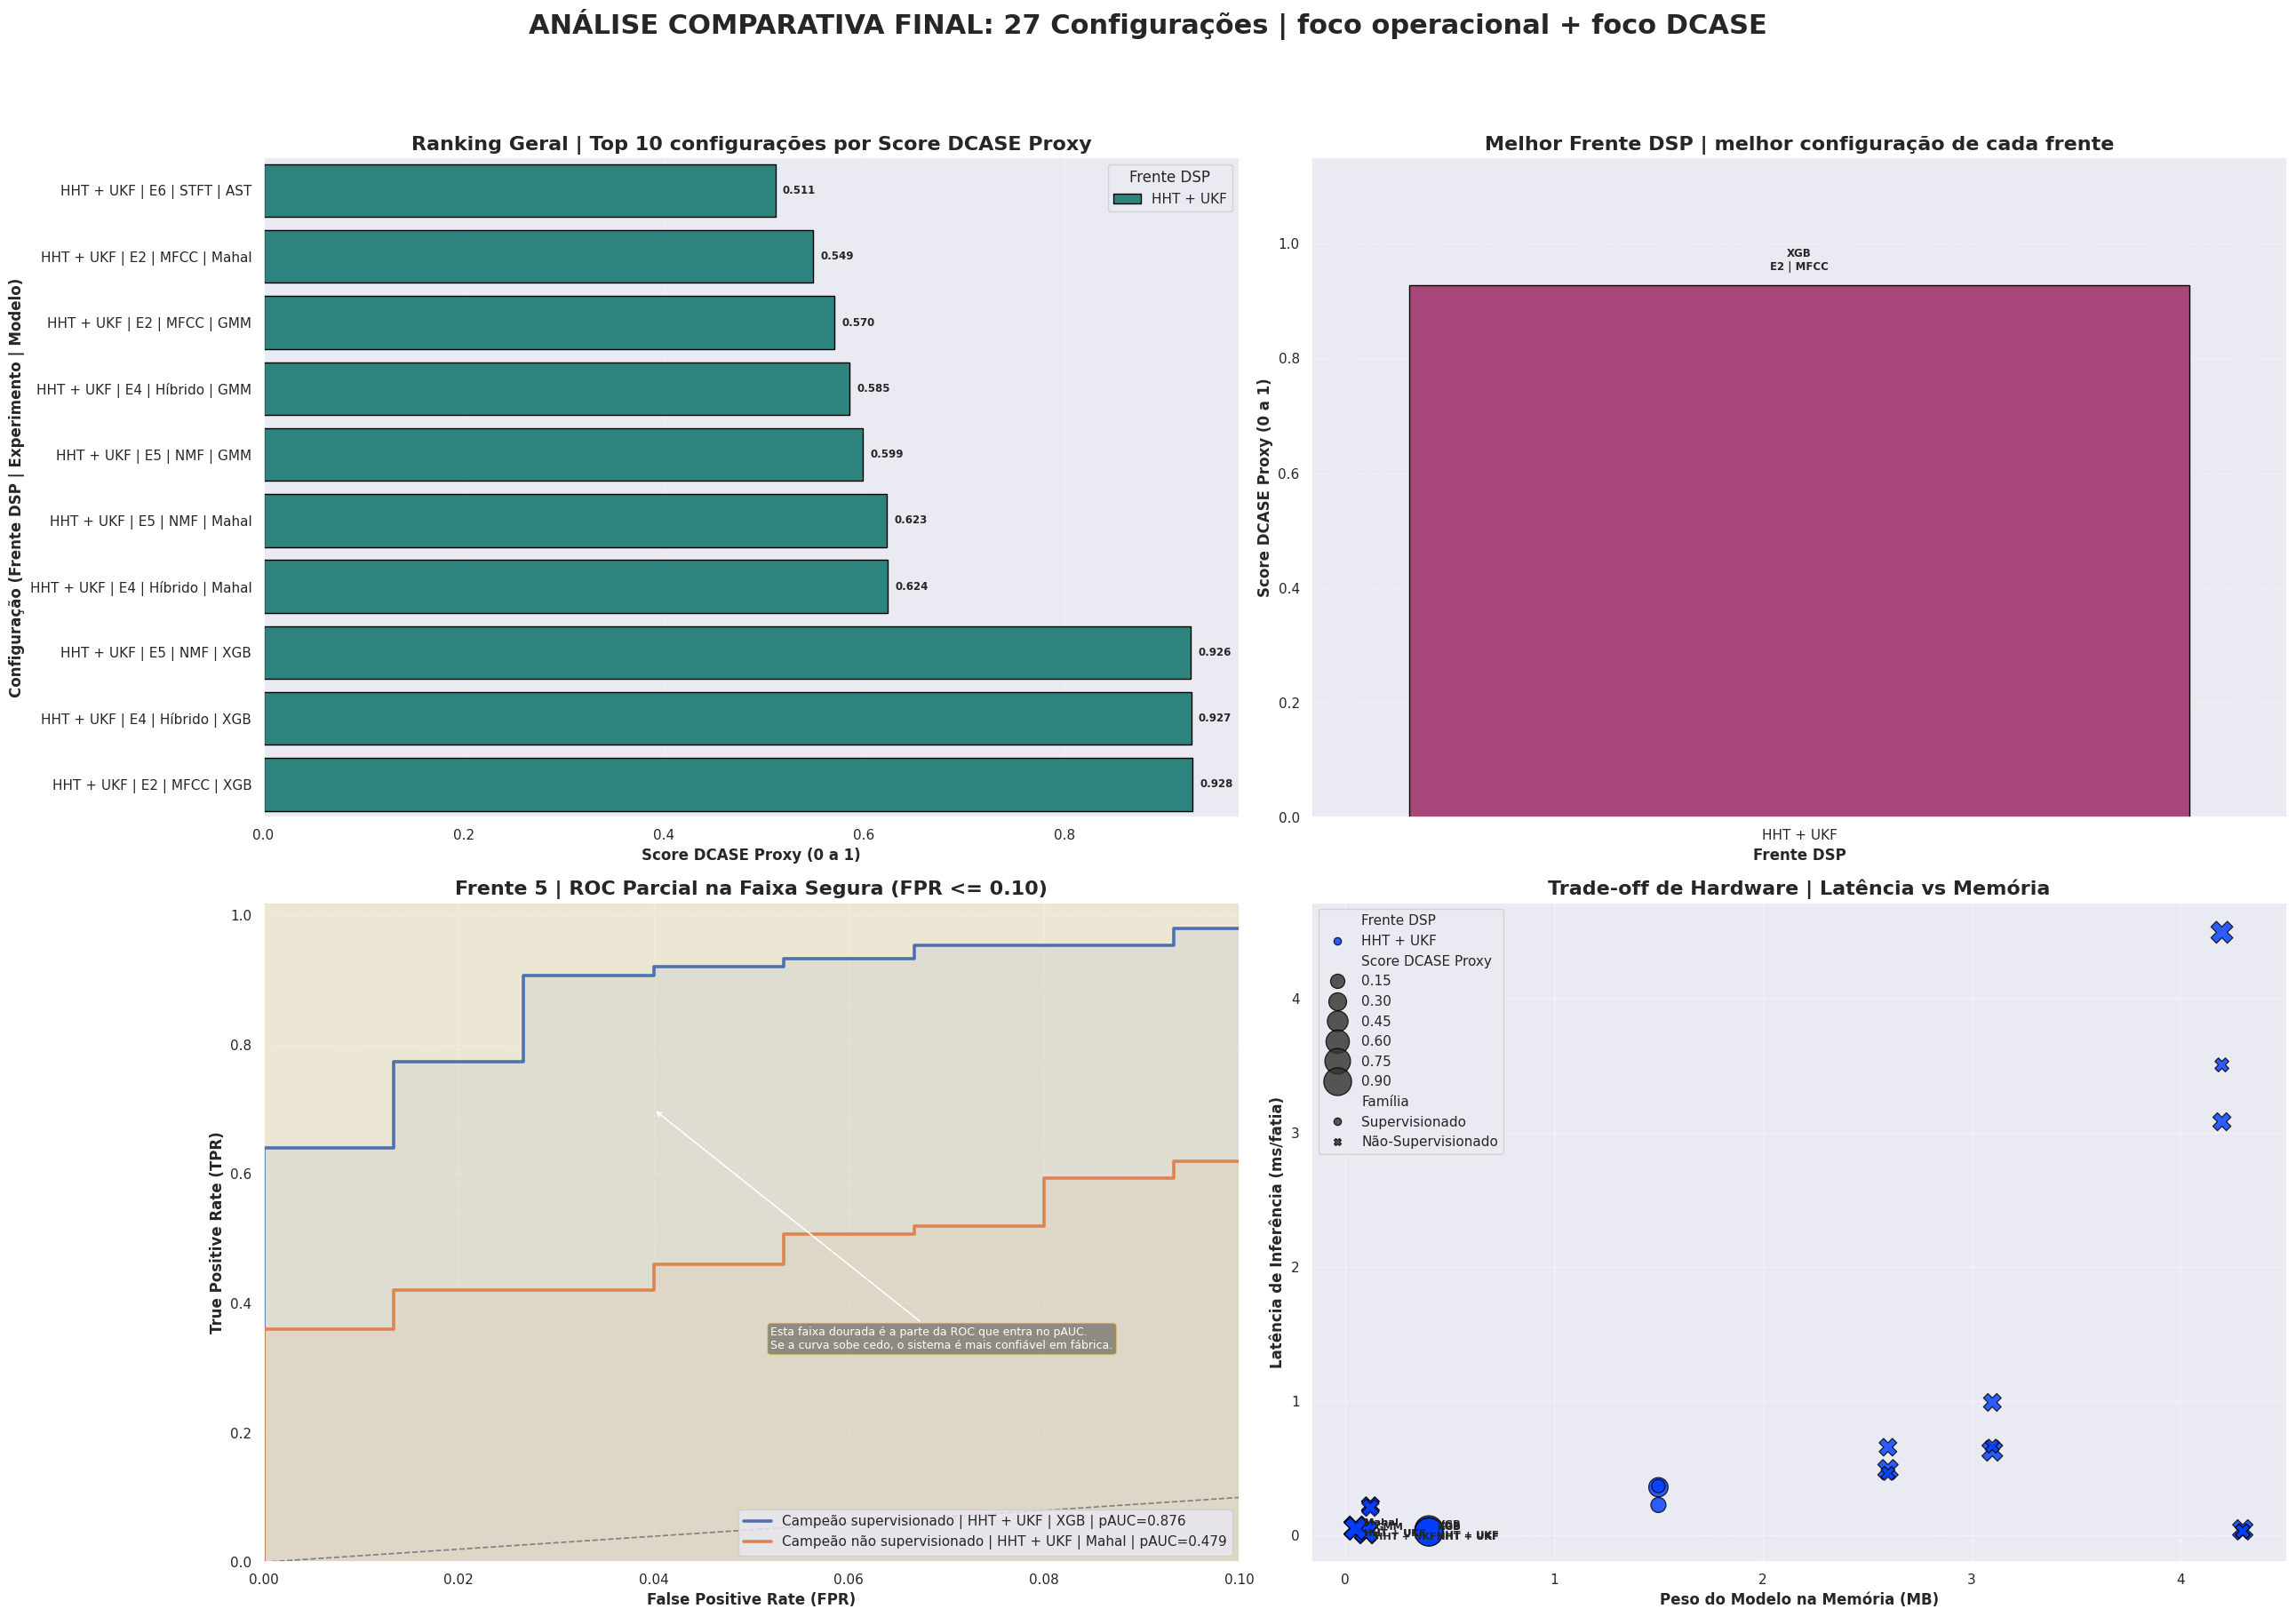

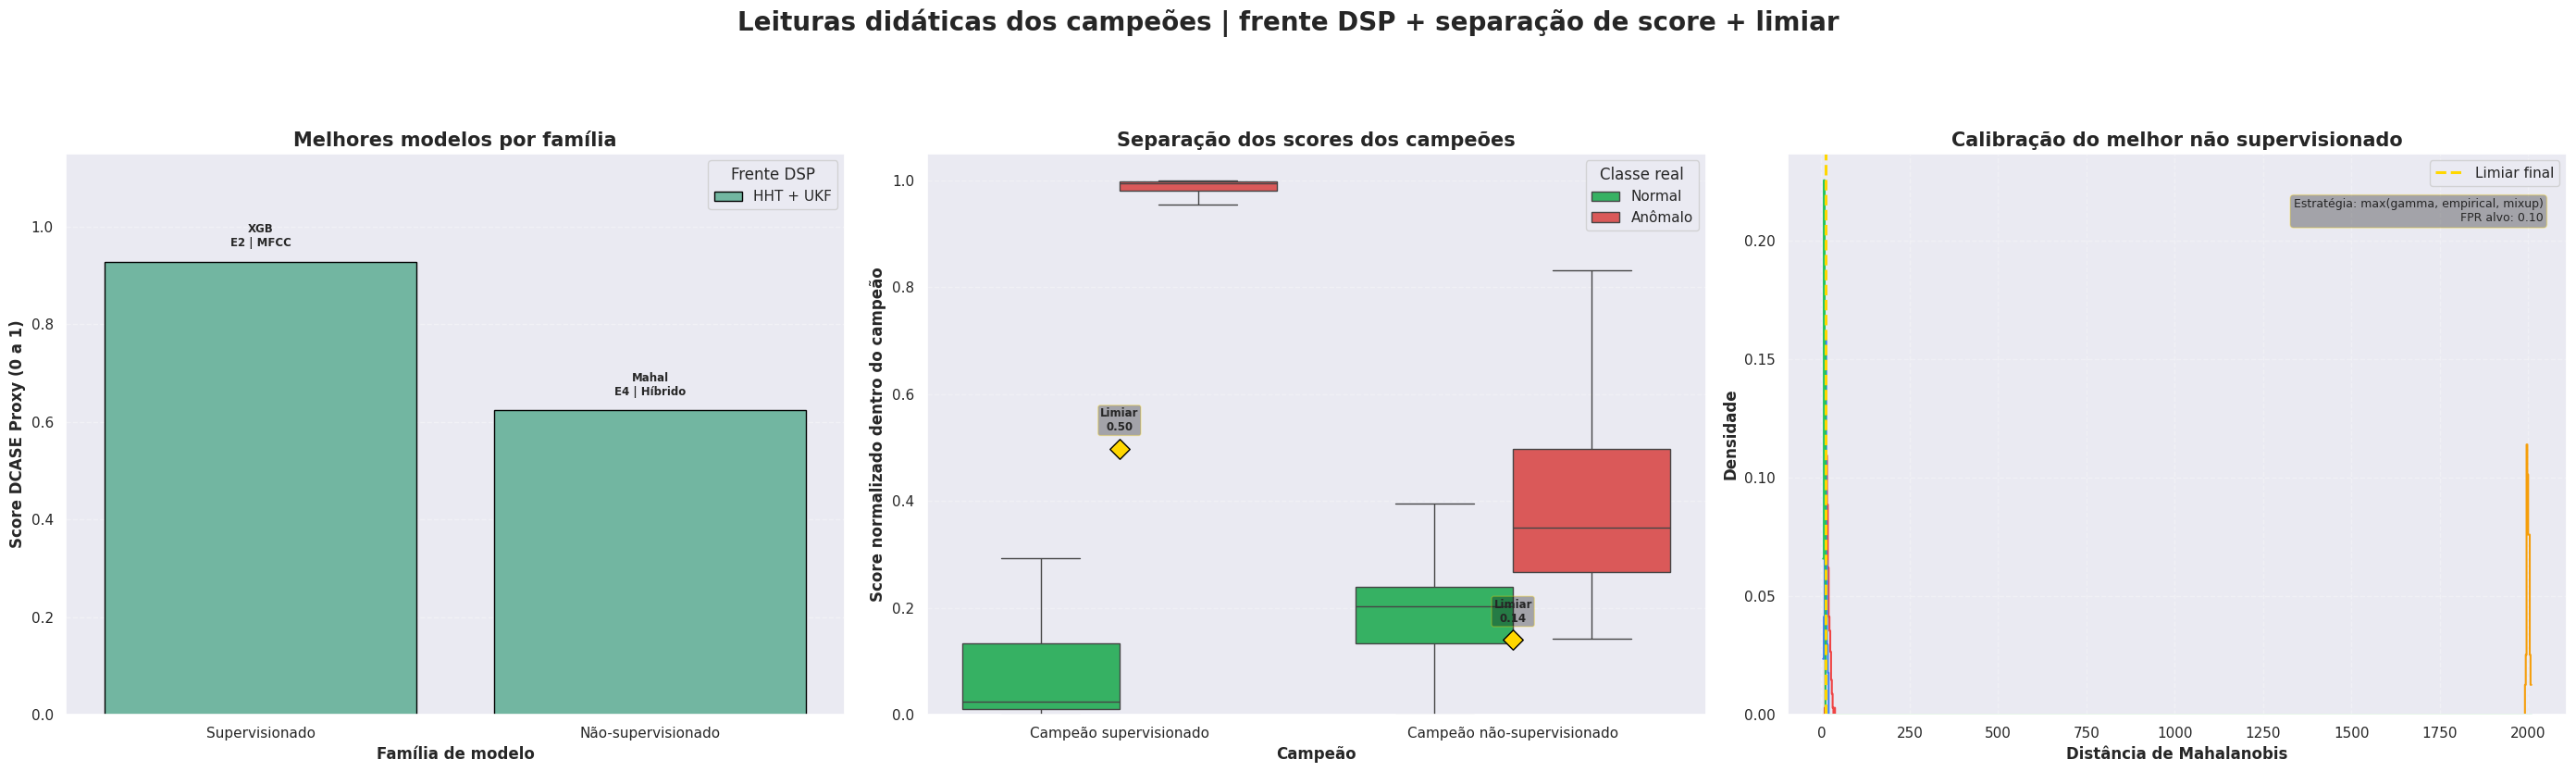

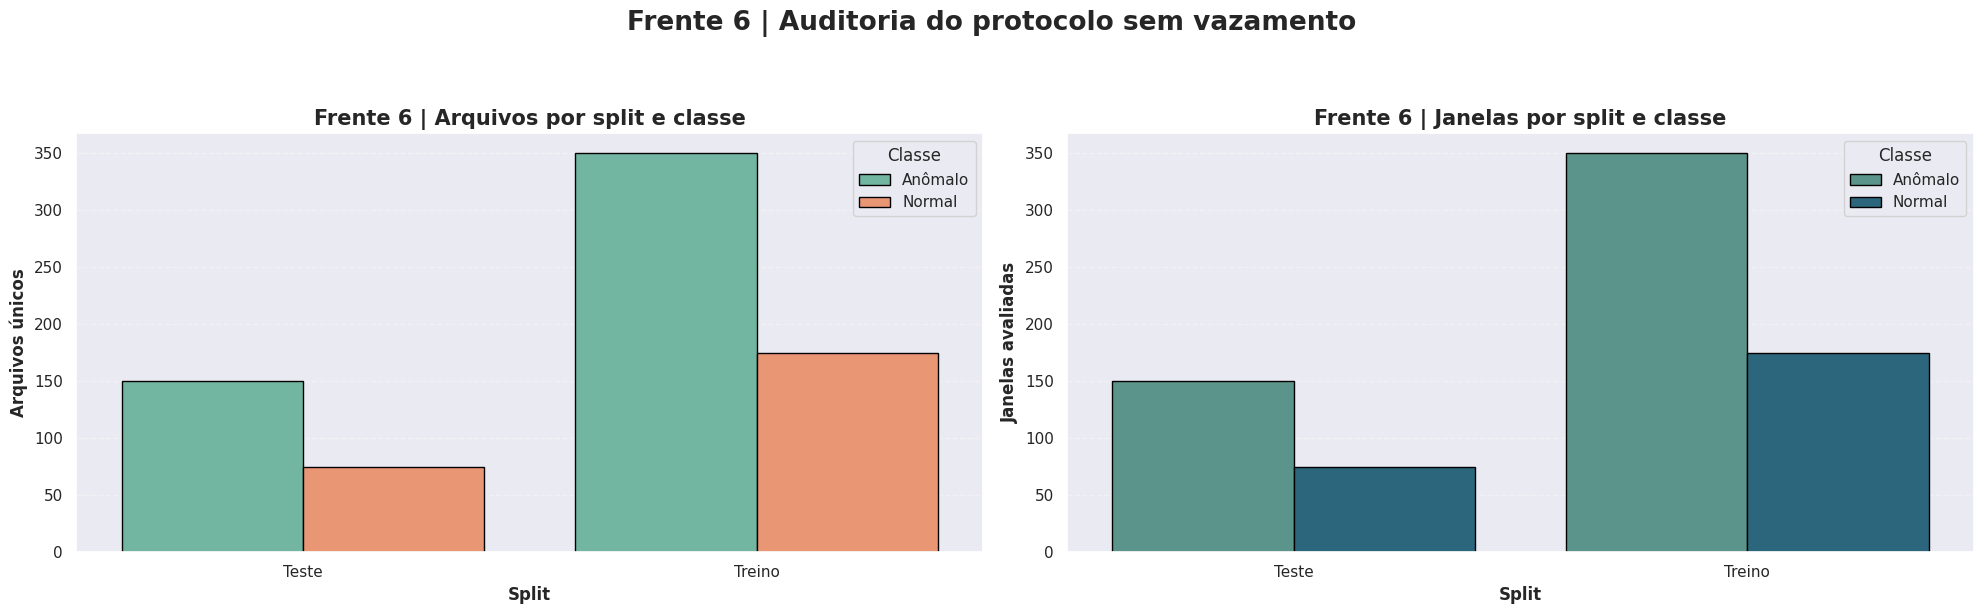

🧱 Frente 6: arquivos compartilhados entre treino e teste = 0
Leitura: se esse número é zero, o benchmark não está se beneficiando de janelas irmãs do mesmo arquivo nos dois lados.

🧪 Frente 8 | Relatório incremental dos baselines não supervisionados leves


,Frente DSP,Experimento,Modelo,Score DCASE Proxy,F1-Score,pAUC@0.1,Latência (ms),Memória (MB)
0,HHT + UKF,Exp 4 (Híbrido Antigo),Mahalanobis (Não-Sup.),0.623596,0.845070,0.478667,0.051389,0.05
1,HHT + UKF,Exp 5 (Híbrido NMF),Mahalanobis (Não-Sup.),0.622884,0.845070,0.477778,0.052490,0.05
2,HHT + UKF,Exp 2 (MFCC Dinâmico),Mahalanobis (Não-Sup.),0.548796,0.844193,0.400000,0.047739,0.05
3,HHT + UKF,Exp 5 (Híbrido NMF),Isolation Forest (Não-Sup.),0.296689,0.596491,0.186667,0.216473,0.12
4,HHT + UKF,Exp 4 (Híbrido Antigo),Isolation Forest (Não-Sup.),0.281974,0.612069,0.175556,0.218988,0.12
5,HHT + UKF,Exp 2 (MFCC Dinâmico),Isolation Forest (Não-Sup.),0.267250,0.526786,0.167111,0.202769,0.12


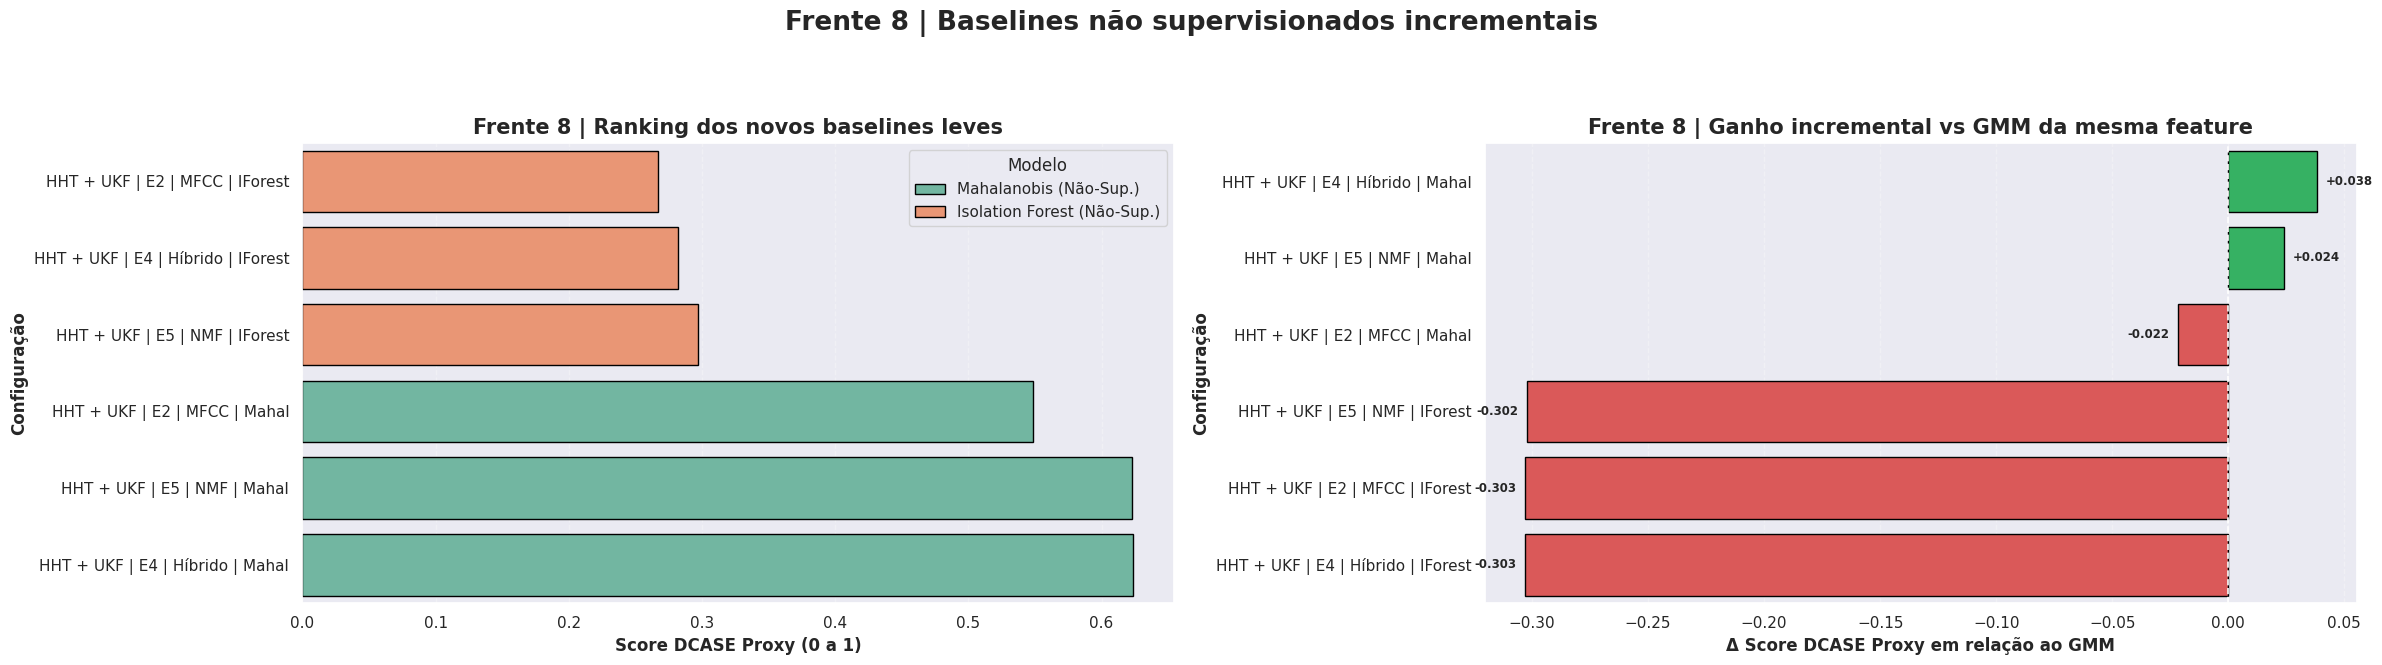


🧪 Frente 8.2 | Relatório incremental do LSTM-AE com promoção condicional


,Frente DSP,Experimento,Modelo,Score DCASE Proxy,F1-Score,pAUC@0.1,Latência (ms),Memória (MB)
0,HHT + UKF,Exp 6 (STFT Log 64x64),LSTM-AE (Não-Sup.),0.427327,0.181818,0.304000,0.486868,2.6
1,HHT + UKF,Exp 1 (Mel + RPCA),LSTM-AE (Não-Sup.),0.289364,0.189349,0.181333,0.654156,2.6
2,HHT + UKF,Exp 3 (CWT + RPCA),LSTM-AE (Não-Sup.),0.138948,0.026316,0.079111,0.459650,2.6


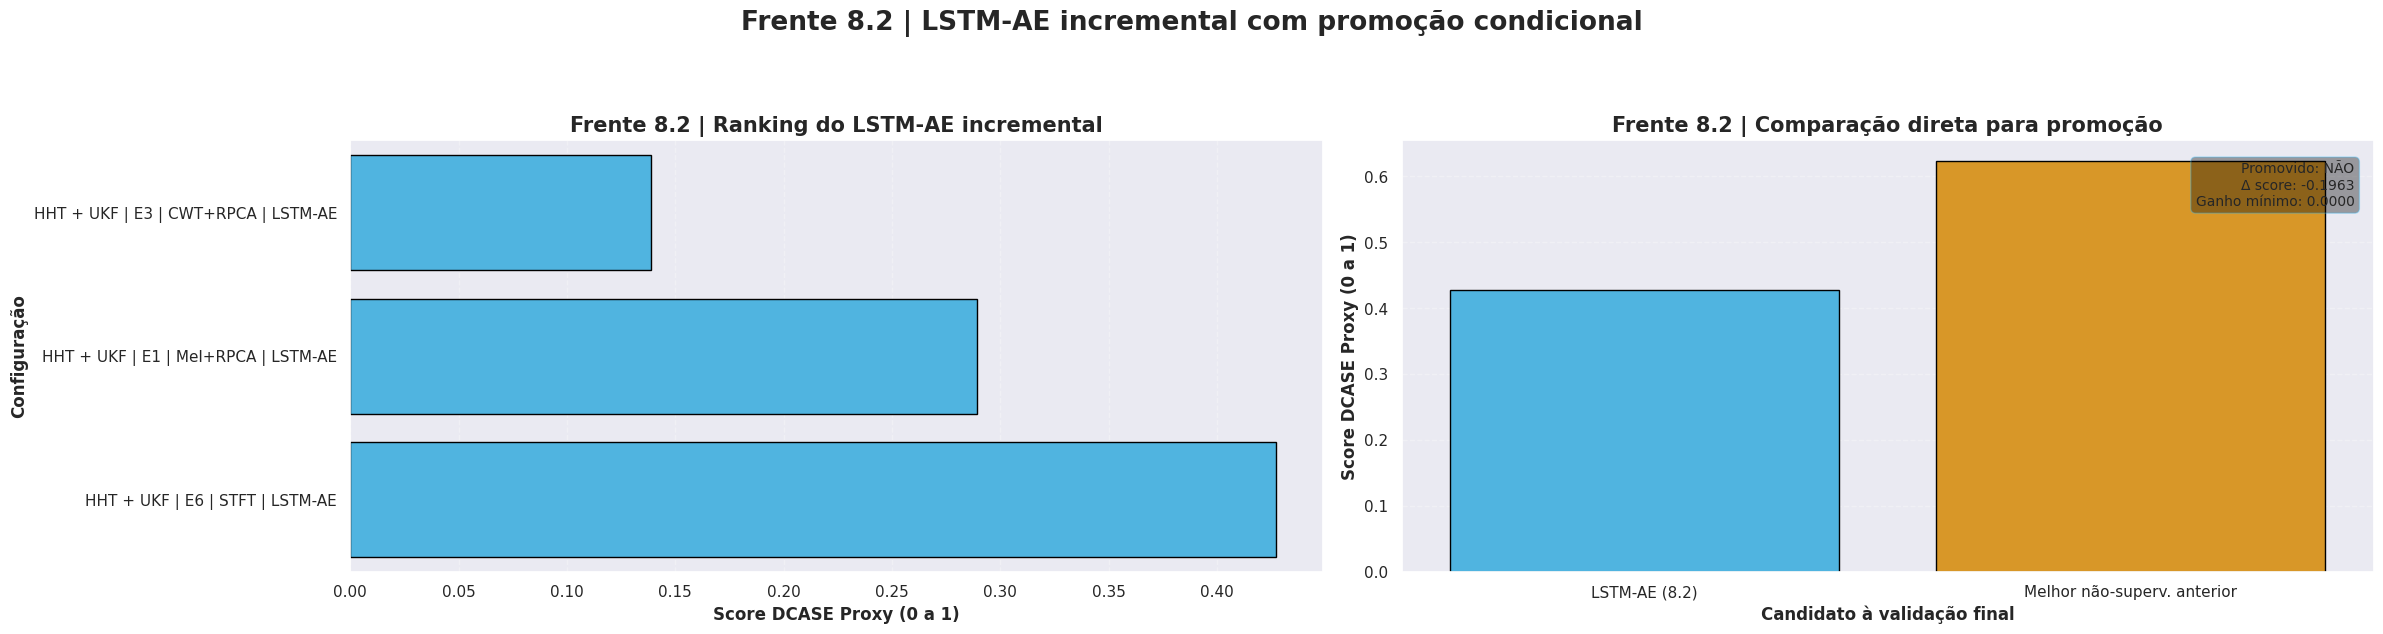


🧪 Frente 8.3 | Relatório incremental do VAE com promoção condicional


,Frente DSP,Experimento,Modelo,Score DCASE Proxy,F1-Score,pAUC@0.1,Latência (ms),Memória (MB)
0,HHT + UKF,Exp 6 (STFT Log 64x64),VAE (Não-Sup.),0.446072,0.192771,0.333333,0.627809,3.1
1,HHT + UKF,Exp 1 (Mel + RPCA),VAE (Não-Sup.),0.293729,0.190476,0.185333,0.988152,3.1
2,HHT + UKF,Exp 3 (CWT + RPCA),VAE (Não-Sup.),0.134119,0.026316,0.076000,0.662307,3.1


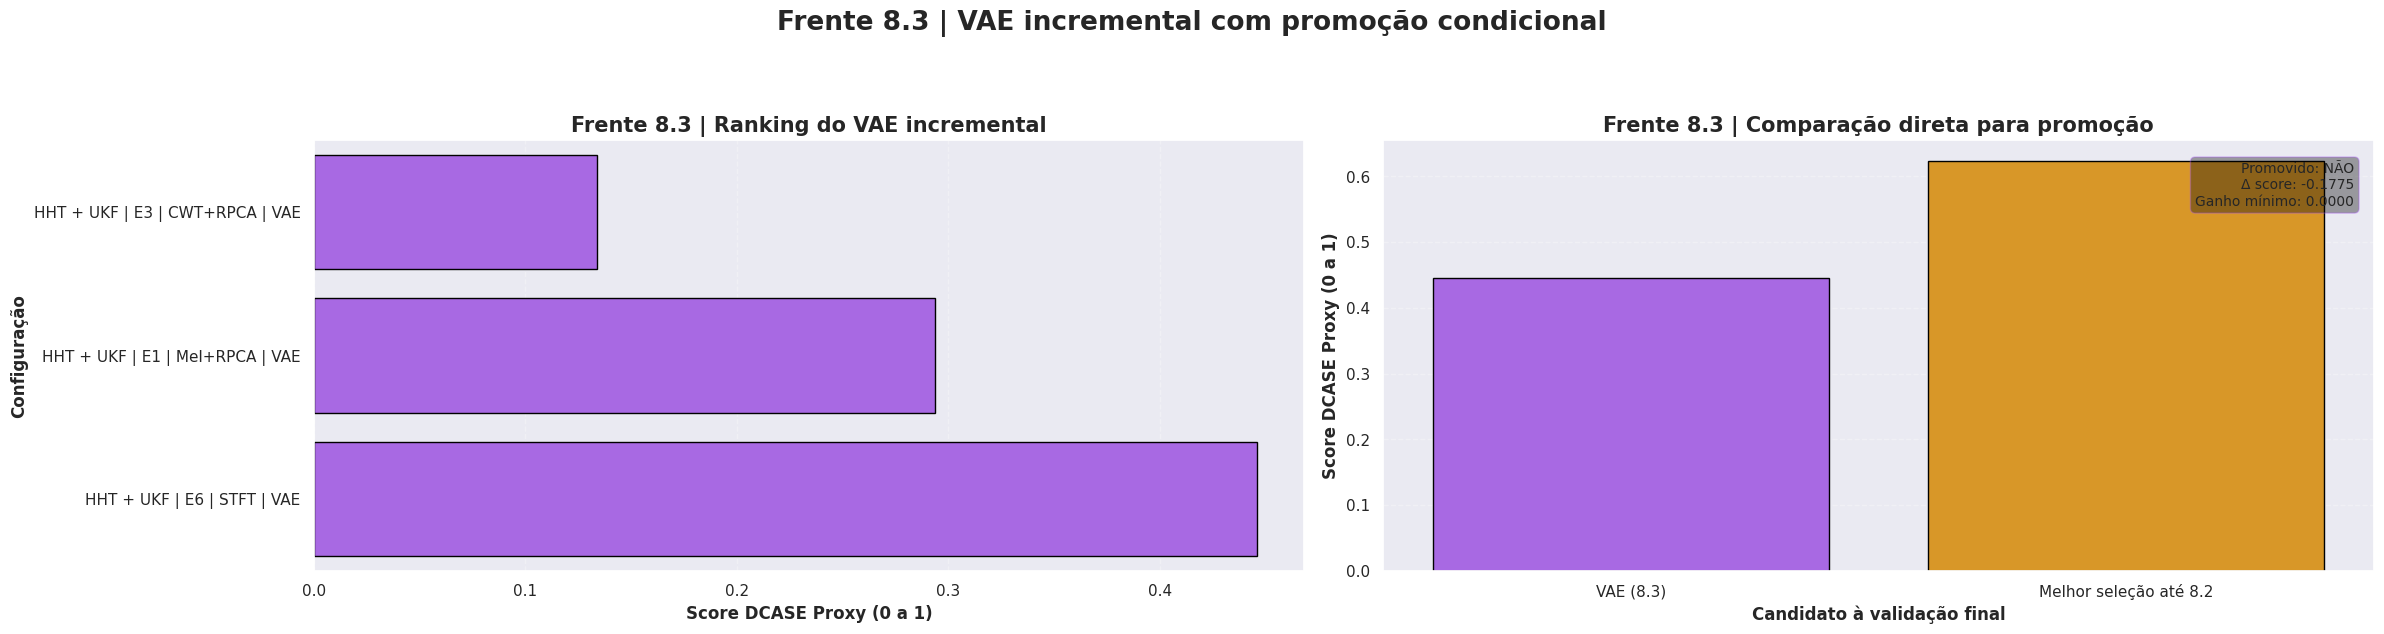


📌 Melhores configurações por frente DSP:


,Frente DSP,Experimento,Modelo,Score DCASE Proxy,F1-Score,pAUC@0.1,Latência (ms)
0,HHT + UKF,Exp 2 (MFCC Dinâmico),XGBoost,0.928046,0.96732,0.876,0.039095



 💡 PARECER TÉCNICO FINAL
 Ranking principal adotado: Score DCASE Proxy.
 Melhor configuração global: 'HHT + UKF | Exp 2 (MFCC Dinâmico) | XGBoost'.
 F1-Score: 0.9673 | AUC-ROC: 0.9867 | pAUC@0.1: 0.8760
 Leitura: se o pAUC sobe, o sistema está mais robusto na região de baixo falso alarme, que é justamente o foco do DCASE.
 Frente 7: OE real inativo | amostras auxiliares = 0
 Frente 8: o campeão não supervisionado desta rodada veio de um baseline leve incremental (Mahalanobis (Não-Sup.)).
 Frente 8.2: promoção para a validação final = NÃO | Δ score vs melhor não-supervisionado anterior = -0.1963
 Frente 8.3: promoção para a validação final = NÃO | Δ score vs melhor seleção até 8.2 = -0.1775
 Campeões: a separação de scores ajuda a ver se normal e anômalo ficaram realmente apartados, e não apenas bem ranqueados por acaso.


In [26]:
# =========================================================
# 📊 VISUALIZAÇÃO FINAL: O veredito do Benchmarking (6 Experimentos + DCASE Proxy)
# =========================================================

if 'Memória (MB)' not in df_bench.columns:
    df_bench['Memória (MB)'] = 0.5
df_bench.fillna(0, inplace=True)

if df_bench.empty:
    print("\n" + "=" * 80)
    print(" ⚠️ AVISO: Nenhum resultado de benchmarking disponível para visualização.")
    print(" Por favor, verifique se o conjunto de dados de treino contém ambas as classes (Normal e Anomalia)")
    print(" para que os modelos supervisionados e não-supervisionados possam ser treinados.")
    print("=" * 80)
else:
    ranking_metric = METRICA_RANKING_BENCHMARK if 'METRICA_RANKING_BENCHMARK' in globals() and METRICA_RANKING_BENCHMARK in df_bench.columns else 'F1-Score'
    front_id_col = 'Frente DSP (ID)' if 'Frente DSP (ID)' in df_bench.columns else 'Frente DSP'
    front_label_col = 'Frente DSP' if 'Frente DSP' in df_bench.columns else front_id_col

    experiment_short_map = {
        'Exp 1 (Mel + RPCA)': 'E1 | Mel+RPCA',
        'Exp 2 (MFCC Dinâmico)': 'E2 | MFCC',
        'Exp 3 (CWT + RPCA)': 'E3 | CWT+RPCA',
        'Exp 4 (Híbrido Antigo)': 'E4 | Híbrido',
        'Exp 5 (Híbrido NMF)': 'E5 | NMF',
        'Exp 6 (STFT Log 64x64)': 'E6 | STFT',
    }
    model_short_map = {
        'XGBoost': 'XGB',
        'GRU': 'GRU',
        'GMM (Não-Sup.)': 'GMM',
        'Tiny-AST': 'AST',
        'CNN + GMM (Não-Sup.)': 'CNN+GMM',
        'Isolation Forest (Não-Sup.)': 'IForest',
        'Mahalanobis (Não-Sup.)': 'Mahal',
        'LSTM-AE (Não-Sup.)': 'LSTM-AE',
        'VAE (Não-Sup.)': 'VAE',
    }

    def compact_experiment_name(exp_name):
        return experiment_short_map.get(exp_name, exp_name)

    def compact_model_name(model_name):
        return model_short_map.get(model_name, model_name)

    def build_config_label(row):
        return f"{row[front_label_col]} | {compact_experiment_name(row['Experimento'])} | {compact_model_name(row['Modelo'])}"

    def normalize_local_scores(scores):
        scores = np.asarray(scores, dtype=np.float32)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

    df_sorted = df_bench.sort_values(by=ranking_metric, ascending=False).reset_index(drop=True)
    df_sorted['Configuração'] = df_sorted.apply(build_config_label, axis=1)

    print("\n" + "=" * 80)
    print(f" 🏆 TABELA COMPARATIVA DE PERFORMANCE (ORDENADA POR {ranking_metric.upper()})")
    print("=" * 80)

    subset_metrics = [m for m in ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC', 'pAUC@0.1', 'Score DCASE Proxy'] if m in df_sorted.columns]
    display(
        df_sorted.style
        .background_gradient(cmap='Greens', subset=subset_metrics)
        .background_gradient(cmap='Oranges', subset=['Latência (ms)', 'Memória (MB)'])
        .format(precision=4)
    )

    best_supervisionado = df_sorted[df_sorted['Modelo'].isin(MODELOS_SUPERVISIONADOS)].head(1)
    best_nao_supervisionado = df_sorted[df_sorted['Modelo'].isin(MODELOS_NAO_SUPERVISIONADOS)].head(1)
    front8_models = globals().get('MODELOS_FRENTE8', {'Isolation Forest (Não-Sup.)', 'Mahalanobis (Não-Sup.)'})
    front82_models = globals().get('MODELOS_FRENTE82', {'LSTM-AE (Não-Sup.)'})
    front_best_rows = df_sorted.drop_duplicates(subset=[front_id_col]).reset_index(drop=True)
    top_configs = df_sorted.head(min(10, len(df_sorted))).copy()
    df_front8 = df_sorted[df_sorted['Modelo'].isin(front8_models)].copy()
    df_front82 = df_sorted[df_sorted['Modelo'].isin(front82_models)].copy()
    front83_models = globals().get('MODELOS_FRENTE83', {'VAE (Não-Sup.)'})
    df_front83 = df_sorted[df_sorted['Modelo'].isin(front83_models)].copy()

    selected_unsup_models = set(MODELOS_NAO_SUPERVISIONADOS) - set(front82_models) - set(front83_models)
    baseline_unsup_without_front82 = df_sorted[df_sorted['Modelo'].isin(selected_unsup_models)].head(1)
    best_front82 = df_front82.head(1)
    front82_promoted = False
    front82_delta = np.nan
    if not best_front82.empty:
        if baseline_unsup_without_front82.empty:
            front82_promoted = True
        else:
            front82_delta = float(best_front82.iloc[0][ranking_metric] - baseline_unsup_without_front82.iloc[0][ranking_metric])
            front82_promoted = bool(front82_delta > float(globals().get('FRONT82_MIN_GAIN', 0.0)))
    if front82_promoted:
        selected_unsup_models = set(selected_unsup_models) | set(front82_models)

    baseline_unsup_before_front83 = df_sorted[df_sorted['Modelo'].isin(selected_unsup_models)].head(1)
    best_front83 = df_front83.head(1)
    front83_promoted = False
    front83_delta = np.nan
    if not best_front83.empty:
        if baseline_unsup_before_front83.empty:
            front83_promoted = True
        else:
            front83_delta = float(best_front83.iloc[0][ranking_metric] - baseline_unsup_before_front83.iloc[0][ranking_metric])
            front83_promoted = bool(front83_delta > float(globals().get('FRONT83_MIN_GAIN', 0.0)))

    MODELOS_NAO_SUPERVISIONADOS_VALIDACAO = (set(selected_unsup_models) | set(front83_models)) if front83_promoted else set(selected_unsup_models)
    globals()['FRONT82_PROMOTED'] = bool(front82_promoted)
    globals()['FRONT82_DELTA_SCORE'] = float(front82_delta) if np.isfinite(front82_delta) else np.nan
    globals()['FRONT83_PROMOTED'] = bool(front83_promoted)
    globals()['FRONT83_DELTA_SCORE'] = float(front83_delta) if np.isfinite(front83_delta) else np.nan
    globals()['MODELOS_NAO_SUPERVISIONADOS_VALIDACAO'] = MODELOS_NAO_SUPERVISIONADOS_VALIDACAO

    best_nao_supervisionado = df_sorted[df_sorted['Modelo'].isin(MODELOS_NAO_SUPERVISIONADOS_VALIDACAO)].head(1)

    fig, axes = plt.subplots(2, 2, figsize=(26, 18))

    sns.barplot(
        data=top_configs,
        y='Configuração',
        x=ranking_metric,
        hue=front_label_col,
        dodge=False,
        palette='viridis',
        edgecolor='black',
        ax=axes[0, 0],
    )
    axes[0, 0].set_title(f'Ranking Geral | Top {len(top_configs)} configurações por {ranking_metric}', fontsize=16, fontweight='bold')
    axes[0, 0].set_xlabel(f'{ranking_metric} (0 a 1)', fontweight='bold')
    axes[0, 0].set_ylabel('Configuração (Frente DSP | Experimento | Modelo)', fontweight='bold')
    axes[0, 0].grid(True, axis='x', linestyle='--', alpha=0.35)
    axes[0, 0].invert_yaxis()
    for patch in axes[0, 0].patches:
        width = patch.get_width()
        if width > 0:
            axes[0, 0].annotate(
                f'{width:.3f}',
                (width, patch.get_y() + patch.get_height() / 2),
                xytext=(6, 0),
                textcoords='offset points',
                ha='left',
                va='center',
                fontsize=8.5,
                fontweight='bold',
            )

    sns.barplot(
        data=front_best_rows,
        x=front_label_col,
        y=ranking_metric,
        hue=front_label_col,
        dodge=False,
        palette='magma',
        edgecolor='black',
        legend=False,
        ax=axes[0, 1],
    )
    axes[0, 1].set_title('Melhor Frente DSP | melhor configuração de cada frente', fontsize=16, fontweight='bold')
    axes[0, 1].set_xlabel('Frente DSP', fontweight='bold')
    axes[0, 1].set_ylabel(f'{ranking_metric} (0 a 1)', fontweight='bold')
    axes[0, 1].set_ylim(0.0, 1.15)
    axes[0, 1].grid(True, axis='y', linestyle='--', alpha=0.35)
    for idx, row in front_best_rows.iterrows():
        axes[0, 1].annotate(
            f"{compact_model_name(row['Modelo'])}\n{compact_experiment_name(row['Experimento'])}",
            (idx, row[ranking_metric]),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=8.5,
            fontweight='bold',
        )

    axes[1, 0].axvspan(0.0, 0.10, color='gold', alpha=0.12)
    axes[1, 0].plot([0.0, 0.10], [0.0, 0.10], linestyle='--', color='gray', linewidth=1.2)

    champion_specs = []
    if not best_supervisionado.empty:
        champion_specs.append(('Campeão supervisionado', best_supervisionado.iloc[0]))
    if not best_nao_supervisionado.empty:
        champion_specs.append(('Campeão não supervisionado', best_nao_supervisionado.iloc[0]))

    curves_found = 0
    for title, row in champion_specs:
        curve_key = build_curve_key(row[front_id_col], row['Experimento'], row['Modelo']) if 'build_curve_key' in globals() else f"{row[front_id_col]} | {row['Experimento']} | {row['Modelo']}"
        if 'benchmark_curve_cache' not in globals() or curve_key not in benchmark_curve_cache:
            continue

        curve = benchmark_curve_cache[curve_key]
        fpr, tpr, _ = roc_curve(curve['y_true'], curve['y_score'])
        if np.max(fpr) < 0.10:
            fpr_plot = np.append(fpr, 0.10)
            tpr_plot = np.append(tpr, tpr[-1])
        else:
            interp_tpr = float(np.interp(0.10, fpr, tpr))
            mask = fpr <= 0.10
            fpr_plot = np.concatenate([fpr[mask], [0.10]])
            tpr_plot = np.concatenate([tpr[mask], [interp_tpr]])

        axes[1, 0].plot(
            fpr_plot,
            tpr_plot,
            linewidth=2.6,
            label=f"{title} | {row[front_label_col]} | {compact_model_name(row['Modelo'])} | pAUC={row['pAUC@0.1']:.3f}"
        )
        axes[1, 0].fill_between(fpr_plot, 0, tpr_plot, alpha=0.08)
        curves_found += 1

    axes[1, 0].set_xlim(0.0, 0.10)
    axes[1, 0].set_ylim(0.0, 1.02)
    axes[1, 0].set_title('Frente 5 | ROC Parcial na Faixa Segura (FPR <= 0.10)', fontsize=16, fontweight='bold')
    axes[1, 0].set_xlabel('False Positive Rate (FPR)', fontweight='bold')
    axes[1, 0].set_ylabel('True Positive Rate (TPR)', fontweight='bold')
    axes[1, 0].grid(True, linestyle='--', alpha=0.4)
    if curves_found > 0:
        axes[1, 0].legend(loc='lower right')
    else:
        axes[1, 0].text(
            0.05,
            0.50,
            'As curvas dos campeões aparecerão aqui\nassim que o cache do benchmark estiver disponível.',
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            bbox=dict(boxstyle='round,pad=0.3', fc='black', ec='gold', alpha=0.30),
        )
    axes[1, 0].annotate(
        'Esta faixa dourada é a parte da ROC que entra no pAUC.\nSe a curva sobe cedo, o sistema é mais confiável em fábrica.',
        xy=(0.04, 0.70),
        xytext=(0.052, 0.33),
        fontsize=9,
        color='white',
        arrowprops=dict(arrowstyle='->', color='white', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', fc='black', ec='gold', alpha=0.35),
    )

    size_metric = df_sorted[ranking_metric] if ranking_metric in df_sorted.columns else np.ones(len(df_sorted))
    df_sorted['Família'] = np.where(df_sorted['Modelo'].isin(MODELOS_SUPERVISIONADOS), 'Supervisionado', 'Não-Supervisionado')
    sns.scatterplot(
        data=df_sorted,
        x='Memória (MB)',
        y='Latência (ms)',
        hue=front_label_col,
        style='Família',
        size=size_metric,
        sizes=(120, 520),
        palette='bright',
        ax=axes[1, 1],
        edgecolor='black',
        alpha=0.82,
    )
    for _, row in df_sorted.head(min(6, len(df_sorted))).iterrows():
        axes[1, 1].text(
            row['Memória (MB)'] + 0.04,
            row['Latência (ms)'],
            f"{compact_model_name(row['Modelo'])}\n{row[front_label_col]}",
            fontsize=8.2,
            fontweight='bold',
            va='center'
        )
    axes[1, 1].set_title('Trade-off de Hardware | Latência vs Memória', fontsize=16, fontweight='bold')
    axes[1, 1].set_xlabel('Peso do Modelo na Memória (MB)', fontweight='bold')
    axes[1, 1].set_ylabel('Latência de Inferência (ms/fatia)', fontweight='bold')
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)

    plt.suptitle(
        f'ANÁLISE COMPARATIVA FINAL: {len(df_bench)} Configurações | foco operacional + foco DCASE',
        fontsize=22,
        fontweight='bold',
        y=1.01
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    fig2, axes2 = plt.subplots(1, 3, figsize=(28, 8))

    family_rows = []
    if not best_supervisionado.empty:
        row_sup = best_supervisionado.iloc[0].copy()
        row_sup['Família campeã'] = 'Supervisionado'
        family_rows.append(row_sup)
    if not best_nao_supervisionado.empty:
        row_unsup = best_nao_supervisionado.iloc[0].copy()
        row_unsup['Família campeã'] = 'Não-supervisionado'
        family_rows.append(row_unsup)

    if family_rows:
        df_family = pd.DataFrame(family_rows)
        sns.barplot(
            data=df_family,
            x='Família campeã',
            y=ranking_metric,
            hue=front_label_col,
            palette='Set2',
            edgecolor='black',
            ax=axes2[0],
        )
        axes2[0].set_title('Melhores modelos por família', fontsize=15, fontweight='bold')
        axes2[0].set_xlabel('Família de modelo', fontweight='bold')
        axes2[0].set_ylabel(f'{ranking_metric} (0 a 1)', fontweight='bold')
        axes2[0].set_ylim(0.0, 1.15)
        axes2[0].grid(True, axis='y', linestyle='--', alpha=0.35)
        for idx, row in df_family.reset_index(drop=True).iterrows():
            axes2[0].annotate(
                f"{compact_model_name(row['Modelo'])}\n{compact_experiment_name(row['Experimento'])}",
                (idx, row[ranking_metric]),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=8.5,
                fontweight='bold',
            )
    else:
        axes2[0].axis('off')
        axes2[0].text(0.5, 0.5, 'Nenhum campeão por família disponível.', ha='center', va='center', fontsize=11)

    champion_score_rows = []
    threshold_markers = []
    champion_name_map = {
        'Campeão supervisionado': best_supervisionado.iloc[0] if not best_supervisionado.empty else None,
        'Campeão não-supervisionado': best_nao_supervisionado.iloc[0] if not best_nao_supervisionado.empty else None,
    }

    for champion_title, row in champion_name_map.items():
        if row is None:
            continue
        cache_key = build_curve_key(row[front_id_col], row['Experimento'], row['Modelo']) if 'build_curve_key' in globals() else f"{row[front_id_col]} | {row['Experimento']} | {row['Modelo']}"
        diag = benchmark_diagnostic_cache.get(cache_key) if 'benchmark_diagnostic_cache' in globals() else None
        if diag is None or 'test_scores' not in diag:
            continue

        raw_scores = np.asarray(diag['test_scores'], dtype=np.float32)
        score_norm = normalize_local_scores(raw_scores)
        y_true = np.asarray(diag.get('y_true', []), dtype=np.int64)
        if len(y_true) != len(score_norm):
            continue

        for score_value, class_value in zip(score_norm, y_true):
            champion_score_rows.append({
                'Campeão': champion_title,
                'Classe real': 'Anômalo' if int(class_value) == 1 else 'Normal',
                'Score normalizado': float(score_value),
            })

        decision_threshold = diag.get('decision_threshold', np.nan)
        if np.isfinite(decision_threshold):
            threshold_norm = float((decision_threshold - raw_scores.min()) / (raw_scores.max() - raw_scores.min() + 1e-9))
            threshold_markers.append({
                'Campeão': champion_title,
                'Threshold normalizado': float(np.clip(threshold_norm, 0.0, 1.0)),
            })

    if champion_score_rows:
        df_scores = pd.DataFrame(champion_score_rows)
        order_scores = list(df_scores['Campeão'].drop_duplicates())
        sns.boxplot(
            data=df_scores,
            x='Campeão',
            y='Score normalizado',
            hue='Classe real',
            order=order_scores,
            palette={'Normal': '#22c55e', 'Anômalo': '#ef4444'},
            showfliers=False,
            ax=axes2[1],
        )
        axes2[1].set_title('Separação dos scores dos campeões', fontsize=15, fontweight='bold')
        axes2[1].set_xlabel('Campeão', fontweight='bold')
        axes2[1].set_ylabel('Score normalizado dentro do campeão', fontweight='bold')
        axes2[1].set_ylim(0.0, 1.05)
        axes2[1].grid(True, axis='y', linestyle='--', alpha=0.30)

        x_positions = {name: idx for idx, name in enumerate(order_scores)}
        for marker in threshold_markers:
            x_pos = x_positions.get(marker['Campeão'])
            if x_pos is None:
                continue
            axes2[1].scatter(
                [x_pos],
                [marker['Threshold normalizado']],
                s=120,
                marker='D',
                color='gold',
                edgecolor='black',
                zorder=6,
            )
            axes2[1].annotate(
                f"Limiar\n{marker['Threshold normalizado']:.2f}",
                xy=(x_pos, marker['Threshold normalizado']),
                xytext=(0, 12),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=8.5,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', fc='black', ec='gold', alpha=0.30),
            )
    else:
        axes2[1].axis('off')
        axes2[1].text(0.5, 0.5, 'Sem scores diagnósticos suficientes\npara comparar os campeões.', ha='center', va='center', fontsize=11)

    if not best_nao_supervisionado.empty:
        row_unsup = best_nao_supervisionado.iloc[0]
        cache_key_unsup = build_curve_key(row_unsup[front_id_col], row_unsup['Experimento'], row_unsup['Modelo']) if 'build_curve_key' in globals() else f"{row_unsup[front_id_col]} | {row_unsup['Experimento']} | {row_unsup['Modelo']}"
        diag_unsup = benchmark_diagnostic_cache.get(cache_key_unsup) if 'benchmark_diagnostic_cache' in globals() else None
    else:
        diag_unsup = None

    if diag_unsup is not None and 'test_scores' in diag_unsup:
        hist_rows = []
        for score in np.asarray(diag_unsup.get('train_normal_scores', []), dtype=np.float32):
            hist_rows.append({'Grupo': 'Treino normal', 'Score': float(score)})
        for score in np.asarray(diag_unsup.get('mixup_scores', []), dtype=np.float32):
            hist_rows.append({'Grupo': 'Mixup', 'Score': float(score)})
        for score in np.asarray(diag_unsup.get('oe_real_scores', []), dtype=np.float32):
            hist_rows.append({'Grupo': 'OE real', 'Score': float(score)})

        raw_scores = np.asarray(diag_unsup.get('test_scores', []), dtype=np.float32)
        y_true_diag = np.asarray(diag_unsup.get('y_true', []), dtype=np.int64)
        if len(raw_scores) == len(y_true_diag):
            for score, class_value in zip(raw_scores, y_true_diag):
                hist_rows.append({
                    'Grupo': 'Teste anômalo' if int(class_value) == 1 else 'Teste normal',
                    'Score': float(score),
                })

        if hist_rows:
            df_hist = pd.DataFrame(hist_rows)
            sns.histplot(
                data=df_hist,
                x='Score',
                hue='Grupo',
                element='step',
                fill=False,
                stat='density',
                common_norm=False,
                palette={
                    'Treino normal': '#22c55e',
                    'Mixup': '#f59e0b',
                    'OE real': '#a855f7',
                    'Teste normal': '#3b82f6',
                    'Teste anômalo': '#ef4444',
                },
                ax=axes2[2],
            )
            threshold_value = diag_unsup.get('decision_threshold', np.nan)
            if np.isfinite(threshold_value):
                axes2[2].axvline(threshold_value, color='gold', linestyle='--', linewidth=2.2, label='Limiar final')
                axes2[2].legend(loc='upper right')
            axes2[2].set_title('Calibração do melhor não supervisionado', fontsize=15, fontweight='bold')
            axes2[2].set_xlabel(diag_unsup.get('display_label', 'Score bruto de anomalia'), fontweight='bold')
            axes2[2].set_ylabel('Densidade', fontweight='bold')
            axes2[2].grid(True, linestyle='--', alpha=0.30)
            tinfo = diag_unsup.get('threshold_info', {})
            axes2[2].annotate(
                f"Estratégia: {tinfo.get('strategy', 'n/d')}\nFPR alvo: {tinfo.get('target_fpr', np.nan):.2f}",
                xy=(0.97, 0.92),
                xycoords='axes fraction',
                ha='right',
                va='top',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='black', ec='gold', alpha=0.30),
            )
        else:
            axes2[2].axis('off')
            axes2[2].text(0.5, 0.5, 'Sem distribuição suficiente para\nmostrar a calibração do limiar.', ha='center', va='center', fontsize=11)
    else:
        axes2[2].axis('off')
        axes2[2].text(0.5, 0.5, 'Nenhum campeão não supervisionado\nfoi encontrado para calibrar o limiar.', ha='center', va='center', fontsize=11)

    plt.suptitle('Leituras didáticas dos campeões | frente DSP + separação de score + limiar', fontsize=20, fontweight='bold', y=1.04)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    if globals().get('FRONT6_PROTOCOL_ACTIVE', False):
        df_protocol_summary = globals().get('FRONT6_PROTOCOL_REPORT', {}).get('summary_table', pd.DataFrame()).copy()
        if not df_protocol_summary.empty:
            fig3, axes3 = plt.subplots(1, 2, figsize=(20, 6))

            sns.barplot(
                data=df_protocol_summary,
                x='Split',
                y='Arquivos',
                hue='Classe',
                palette='Set2',
                edgecolor='black',
                ax=axes3[0],
            )
            axes3[0].set_title('Frente 6 | Arquivos por split e classe', fontsize=15, fontweight='bold')
            axes3[0].set_xlabel('Split', fontweight='bold')
            axes3[0].set_ylabel('Arquivos únicos', fontweight='bold')
            axes3[0].grid(True, axis='y', linestyle='--', alpha=0.30)

            sns.barplot(
                data=df_protocol_summary,
                x='Split',
                y='Janelas',
                hue='Classe',
                palette='crest',
                edgecolor='black',
                ax=axes3[1],
            )
            axes3[1].set_title('Frente 6 | Janelas por split e classe', fontsize=15, fontweight='bold')
            axes3[1].set_xlabel('Split', fontweight='bold')
            axes3[1].set_ylabel('Janelas avaliadas', fontweight='bold')
            axes3[1].grid(True, axis='y', linestyle='--', alpha=0.30)

            plt.suptitle('Frente 6 | Auditoria do protocolo sem vazamento', fontsize=19, fontweight='bold', y=1.02)
            plt.tight_layout(rect=[0, 0, 1, 0.96])
            plt.show()

            print(f"🧱 Frente 6: arquivos compartilhados entre treino e teste = {int(globals().get('FRONT6_SHARED_GROUPS_COUNT', 0))}")
            print("Leitura: se esse número é zero, o benchmark não está se beneficiando de janelas irmãs do mesmo arquivo nos dois lados.")

    if not df_front8.empty:
        print("\n🧪 Frente 8 | Relatório incremental dos baselines não supervisionados leves")
        display(
            df_front8[
                [front_label_col, 'Experimento', 'Modelo', ranking_metric, 'F1-Score', 'pAUC@0.1', 'Latência (ms)', 'Memória (MB)']
            ].head(min(12, len(df_front8))).reset_index(drop=True)
        )

        fig4, axes4 = plt.subplots(1, 2, figsize=(24, 6.5))
        top_front8 = df_front8.head(min(10, len(df_front8))).copy()
        sns.barplot(
            data=top_front8,
            y='Configuração',
            x=ranking_metric,
            hue='Modelo',
            dodge=False,
            palette='Set2',
            edgecolor='black',
            ax=axes4[0],
        )
        axes4[0].set_title('Frente 8 | Ranking dos novos baselines leves', fontsize=15, fontweight='bold')
        axes4[0].set_xlabel(f'{ranking_metric} (0 a 1)', fontweight='bold')
        axes4[0].set_ylabel('Configuração', fontweight='bold')
        axes4[0].grid(True, axis='x', linestyle='--', alpha=0.30)
        axes4[0].invert_yaxis()

        gmm_reference = (
            df_sorted[df_sorted['Modelo'] == 'GMM (Não-Sup.)'][[front_id_col, 'Experimento', ranking_metric]]
            .rename(columns={ranking_metric: 'Score GMM'})
        )
        df_front8_delta = df_front8.merge(gmm_reference, on=[front_id_col, 'Experimento'], how='left')
        df_front8_delta = df_front8_delta[df_front8_delta['Score GMM'].notna()].copy()

        if not df_front8_delta.empty:
            df_front8_delta['Delta vs GMM'] = df_front8_delta[ranking_metric] - df_front8_delta['Score GMM']
            df_front8_delta['Direção'] = np.where(df_front8_delta['Delta vs GMM'] >= 0, 'Ganho', 'Perda')
            df_front8_delta = df_front8_delta.sort_values(by='Delta vs GMM', ascending=False).head(min(10, len(df_front8_delta)))
            sns.barplot(
                data=df_front8_delta,
                y='Configuração',
                x='Delta vs GMM',
                hue='Direção',
                dodge=False,
                palette={'Ganho': '#22c55e', 'Perda': '#ef4444'},
                edgecolor='black',
                legend=False,
                ax=axes4[1],
            )
            axes4[1].axvline(0.0, color='white', linestyle='--', linewidth=1.2)
            axes4[1].set_title('Frente 8 | Ganho incremental vs GMM da mesma feature', fontsize=15, fontweight='bold')
            axes4[1].set_xlabel(f'Δ {ranking_metric} em relação ao GMM', fontweight='bold')
            axes4[1].set_ylabel('Configuração', fontweight='bold')
            axes4[1].grid(True, axis='x', linestyle='--', alpha=0.30)
            for patch in axes4[1].patches:
                width = patch.get_width()
                axes4[1].annotate(
                    f'{width:+.3f}',
                    (width, patch.get_y() + patch.get_height() / 2),
                    xytext=(6 if width >= 0 else -6, 0),
                    textcoords='offset points',
                    ha='left' if width >= 0 else 'right',
                    va='center',
                    fontsize=8.5,
                    fontweight='bold',
                )
        else:
            axes4[1].axis('off')
            axes4[1].text(0.5, 0.5, 'Sem referência GMM equivalente\npara medir ganho incremental.', ha='center', va='center', fontsize=11)

        plt.suptitle('Frente 8 | Baselines não supervisionados incrementais', fontsize=19, fontweight='bold', y=1.02)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    print("\n🧪 Frente 8.2 | Relatório incremental do LSTM-AE com promoção condicional")
    if not df_front82.empty:
        display(
            df_front82[
                [front_label_col, 'Experimento', 'Modelo', ranking_metric, 'F1-Score', 'pAUC@0.1', 'Latência (ms)', 'Memória (MB)']
            ].head(min(6, len(df_front82))).reset_index(drop=True)
        )

        fig5, axes5 = plt.subplots(1, 2, figsize=(24, 6.2))
        top_front82 = df_front82.head(min(6, len(df_front82))).copy()
        sns.barplot(
            data=top_front82,
            y='Configuração',
            x=ranking_metric,
            color='#38bdf8',
            edgecolor='black',
            ax=axes5[0],
        )
        axes5[0].set_title('Frente 8.2 | Ranking do LSTM-AE incremental', fontsize=15, fontweight='bold')
        axes5[0].set_xlabel(f'{ranking_metric} (0 a 1)', fontweight='bold')
        axes5[0].set_ylabel('Configuração', fontweight='bold')
        axes5[0].grid(True, axis='x', linestyle='--', alpha=0.30)
        axes5[0].invert_yaxis()

        compare_rows = []
        if not best_front82.empty:
            compare_rows.append({'Modelo': 'LSTM-AE (8.2)', 'Score': float(best_front82.iloc[0][ranking_metric])})
        if not baseline_unsup_without_front82.empty:
            compare_rows.append({'Modelo': 'Melhor não-superv. anterior', 'Score': float(baseline_unsup_without_front82.iloc[0][ranking_metric])})

        if compare_rows:
            df_compare = pd.DataFrame(compare_rows)
            sns.barplot(
                data=df_compare,
                x='Modelo',
                y='Score',
                hue='Modelo',
                dodge=False,
                palette={'LSTM-AE (8.2)': '#38bdf8', 'Melhor não-superv. anterior': '#f59e0b'},
                edgecolor='black',
                legend=False,
                ax=axes5[1],
            )
            axes5[1].set_title('Frente 8.2 | Comparação direta para promoção', fontsize=15, fontweight='bold')
            axes5[1].set_xlabel('Candidato à validação final', fontweight='bold')
            axes5[1].set_ylabel(f'{ranking_metric} (0 a 1)', fontweight='bold')
            axes5[1].grid(True, axis='y', linestyle='--', alpha=0.30)
            decision_text = (
                f"Promovido: {'SIM' if front82_promoted else 'NÃO'}\n"
                f"Δ score: {front82_delta:+.4f}\n"
                f"Ganho mínimo: {float(globals().get('FRONT82_MIN_GAIN', 0.0)):.4f}"
            )
            axes5[1].annotate(
                decision_text,
                xy=(0.98, 0.95),
                xycoords='axes fraction',
                ha='right',
                va='top',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.35', fc='black', ec='#38bdf8', alpha=0.35),
            )
        else:
            axes5[1].axis('off')
            axes5[1].text(0.5, 0.5, 'Sem comparação suficiente\npara decidir a promoção da Frente 8.2.', ha='center', va='center', fontsize=11)

        plt.suptitle('Frente 8.2 | LSTM-AE incremental com promoção condicional', fontsize=19, fontweight='bold', y=1.02)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
    else:
        print("   -> Nenhum resultado da Frente 8.2 foi gerado nesta execução.")

    print("\n🧪 Frente 8.3 | Relatório incremental do VAE com promoção condicional")
    if not df_front83.empty:
        display(
            df_front83[
                [front_label_col, 'Experimento', 'Modelo', ranking_metric, 'F1-Score', 'pAUC@0.1', 'Latência (ms)', 'Memória (MB)']
            ].head(min(6, len(df_front83))).reset_index(drop=True)
        )

        fig6, axes6 = plt.subplots(1, 2, figsize=(24, 6.2))
        top_front83 = df_front83.head(min(6, len(df_front83))).copy()
        sns.barplot(
            data=top_front83,
            y='Configuração',
            x=ranking_metric,
            color='#a855f7',
            edgecolor='black',
            ax=axes6[0],
        )
        axes6[0].set_title('Frente 8.3 | Ranking do VAE incremental', fontsize=15, fontweight='bold')
        axes6[0].set_xlabel(f'{ranking_metric} (0 a 1)', fontweight='bold')
        axes6[0].set_ylabel('Configuração', fontweight='bold')
        axes6[0].grid(True, axis='x', linestyle='--', alpha=0.30)
        axes6[0].invert_yaxis()

        compare_rows = []
        if not best_front83.empty:
            compare_rows.append({'Modelo': 'VAE (8.3)', 'Score': float(best_front83.iloc[0][ranking_metric])})
        if not baseline_unsup_before_front83.empty:
            compare_rows.append({'Modelo': 'Melhor seleção até 8.2', 'Score': float(baseline_unsup_before_front83.iloc[0][ranking_metric])})

        if compare_rows:
            df_compare83 = pd.DataFrame(compare_rows)
            sns.barplot(
                data=df_compare83,
                x='Modelo',
                y='Score',
                hue='Modelo',
                dodge=False,
                palette={'VAE (8.3)': '#a855f7', 'Melhor seleção até 8.2': '#f59e0b'},
                edgecolor='black',
                legend=False,
                ax=axes6[1],
            )
            axes6[1].set_title('Frente 8.3 | Comparação direta para promoção', fontsize=15, fontweight='bold')
            axes6[1].set_xlabel('Candidato à validação final', fontweight='bold')
            axes6[1].set_ylabel(f'{ranking_metric} (0 a 1)', fontweight='bold')
            axes6[1].grid(True, axis='y', linestyle='--', alpha=0.30)
            decision_text83 = (
                f"Promovido: {'SIM' if front83_promoted else 'NÃO'}\n"
                f"Δ score: {front83_delta:+.4f}\n"
                f"Ganho mínimo: {float(globals().get('FRONT83_MIN_GAIN', 0.0)):.4f}"
            )
            axes6[1].annotate(
                decision_text83,
                xy=(0.98, 0.95),
                xycoords='axes fraction',
                ha='right',
                va='top',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.35', fc='black', ec='#a855f7', alpha=0.35),
            )
        else:
            axes6[1].axis('off')
            axes6[1].text(0.5, 0.5, 'Sem comparação suficiente\npara decidir a promoção da Frente 8.3.', ha='center', va='center', fontsize=11)

        plt.suptitle('Frente 8.3 | VAE incremental com promoção condicional', fontsize=19, fontweight='bold', y=1.02)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
    else:
        print("   -> Nenhum resultado da Frente 8.3 foi gerado nesta execução.")

    best_row = df_sorted.iloc[0]
    print("\n📌 Melhores configurações por frente DSP:")
    display(
        front_best_rows[
            [front_label_col, 'Experimento', 'Modelo', ranking_metric, 'F1-Score', 'pAUC@0.1', 'Latência (ms)']
        ].reset_index(drop=True)
    )

    print("\n" + "=" * 80)
    print(" 💡 PARECER TÉCNICO FINAL")
    print("=" * 80)
    print(f" Ranking principal adotado: {ranking_metric}.")
    print(f" Melhor configuração global: '{best_row[front_label_col]} | {best_row['Experimento']} | {best_row['Modelo']}'.")
    print(f" F1-Score: {best_row['F1-Score']:.4f} | AUC-ROC: {best_row['AUC-ROC']:.4f} | pAUC@0.1: {best_row['pAUC@0.1']:.4f}")
    print(" Leitura: se o pAUC sobe, o sistema está mais robusto na região de baixo falso alarme, que é justamente o foco do DCASE.")
    if 'OE real ativo' in best_row.index:
        print(f" Frente 7: OE real {'ATIVO' if bool(best_row['OE real ativo']) else 'inativo'} | amostras auxiliares = {int(best_row.get('Amostras OE reais', 0))}")
    if len(front_best_rows) > 1:
        print(" Frente DSP: a barra de 'melhor frente' mostra qual pré-processamento entregou o melhor material para os modelos.")
    if not best_nao_supervisionado.empty and best_nao_supervisionado.iloc[0]['Modelo'] in front8_models:
        print(f" Frente 8: o campeão não supervisionado desta rodada veio de um baseline leve incremental ({best_nao_supervisionado.iloc[0]['Modelo']}).")
    if not df_front82.empty:
        print(f" Frente 8.2: promoção para a validação final = {'SIM' if front82_promoted else 'NÃO'} | Δ score vs melhor não-supervisionado anterior = {front82_delta:+.4f}" if np.isfinite(front82_delta) else f" Frente 8.2: promoção para a validação final = {'SIM' if front82_promoted else 'NÃO'}.")
    if not df_front83.empty:
        print(f" Frente 8.3: promoção para a validação final = {'SIM' if front83_promoted else 'NÃO'} | Δ score vs melhor seleção até 8.2 = {front83_delta:+.4f}" if np.isfinite(front83_delta) else f" Frente 8.3: promoção para a validação final = {'SIM' if front83_promoted else 'NÃO'}.")
    print(" Campeões: a separação de scores ajuda a ver se normal e anômalo ficaram realmente apartados, e não apenas bem ranqueados por acaso.")
    print("=" * 80)


# 12. Validação final dos campeões supervisionado e não supervisionado
A seleção abaixo prioriza o `Score DCASE Proxy` quando ele estiver disponível, mantendo `F1-Score` como fallback.
Para os modelos não supervisionados, o limiar final usa `Distribuição Gamma + FPR alvo`, com o Mixup atuando como endurecimento sintético, a `Frente 7` acrescentando `Outlier Exposure` real, a `Frente 8` trazendo baselines leves, a `Frente 8.2` entrando apenas se o `LSTM-AE` tiver ganho real suficiente para ser promovido, a `Frente 8.3` fazendo a mesma checagem para o `VAE` e a `Frente 8.4` adicionando o `Exp 6 (STFT Log 64x64)` à disputa quando ele estiver habilitado.

Nesta etapa final, o notebook:

- escolhe os campeões depois da auditoria da `Frente 6`;
- usa o split por arquivo apenas para selecionar o modelo de forma honesta;
- recompõe o pipeline do campeão e reaproveita `Mixup` e `OE real` na calibração final do limiar;
- suporta tanto os campeões já existentes quanto os novos baselines da `Frente 8`;
- usa a `Frente 8.2` somente se ela tiver superado os não supervisionados anteriores no ranking definido;
- usa a `Frente 8.3` somente se o `VAE` tiver ganho incremental real sobre a melhor seleção até então;
- gera um gráfico de intensidade de anomalia por arquivo para facilitar priorização manual.



⚙️ Preparando o teste cego para os modelos campeões...

🏆 Campeão supervisionado: HHT + UKF | XGBoost | Exp 2 (MFCC Dinâmico) | Score DCASE Proxy=0.9280


Montando Exp 2 (MFCC Dinâmico) para teste cego: 100%|██████████| 25/25 [00:05<00:00,  4.54fatia/s]

🛰️ Frente 7 | OE real inativo nesta configuração.

📏 Métricas no teste cego (RELATÓRIO FINAL - CAMPEÃO SUPERVISIONADO):
   Acurácia:          0.3600
   Precisão:          0.3600
   Recall:            1.0000
   F1-Score:          0.5294
   AUC-ROC:           0.6319
   pAUC@0.1 (proxy):  0.0000
   Score DCASE Proxy: 0.0000

 RELATÓRIO FINAL - CAMPEÃO SUPERVISIONADO
Métrica de seleção do campeão: Score DCASE Proxy
Frente DSP campeã: HHT + UKF
Experimento campeão: Exp 2 (MFCC Dinâmico)
Modelo campeão: XGBoost
Score de ranking: 0.9280
------------------------------------------------------------------------
anomaly_01.wav: 🚨 ANOMALIA DETECTADA | Confiança: 99.47%
anomaly_02.wav: 🚨 ANOMALIA DETECTADA | Confiança: 99.52%
anomaly_03.wav: 🚨 ANOMALIA DETECTADA | Confiança: 99.55%
anomaly_04.wav: 🚨 ANOMALIA DETECTADA | Confiança: 99.32%
anomaly_05.wav: 🚨 ANOMALIA DETECTADA | Confiança: 99.53%
anomaly_06.wav: 🚨 ANOMALIA DETECTADA | Confiança: 99.33%
anomaly_07.wav: 🚨 ANOMALIA DETECTADA | Confiança:

,Arquivo,Status,Confiança,Rótulo_Real
0,anomaly_01.wav,🚨 ANOMALIA DETECTADA,0.994746,1
1,anomaly_02.wav,🚨 ANOMALIA DETECTADA,0.995236,1
2,anomaly_03.wav,🚨 ANOMALIA DETECTADA,0.995522,1
3,anomaly_04.wav,🚨 ANOMALIA DETECTADA,0.993234,1
4,anomaly_05.wav,🚨 ANOMALIA DETECTADA,0.995293,1
5,anomaly_06.wav,🚨 ANOMALIA DETECTADA,0.993337,1
6,anomaly_07.wav,🚨 ANOMALIA DETECTADA,0.995826,1
7,anomaly_08.wav,🚨 ANOMALIA DETECTADA,0.993643,1
8,anomaly_09.wav,🚨 ANOMALIA DETECTADA,0.989732,1
9,normal_01.wav,🚨 ANOMALIA DETECTADA,0.997398,0


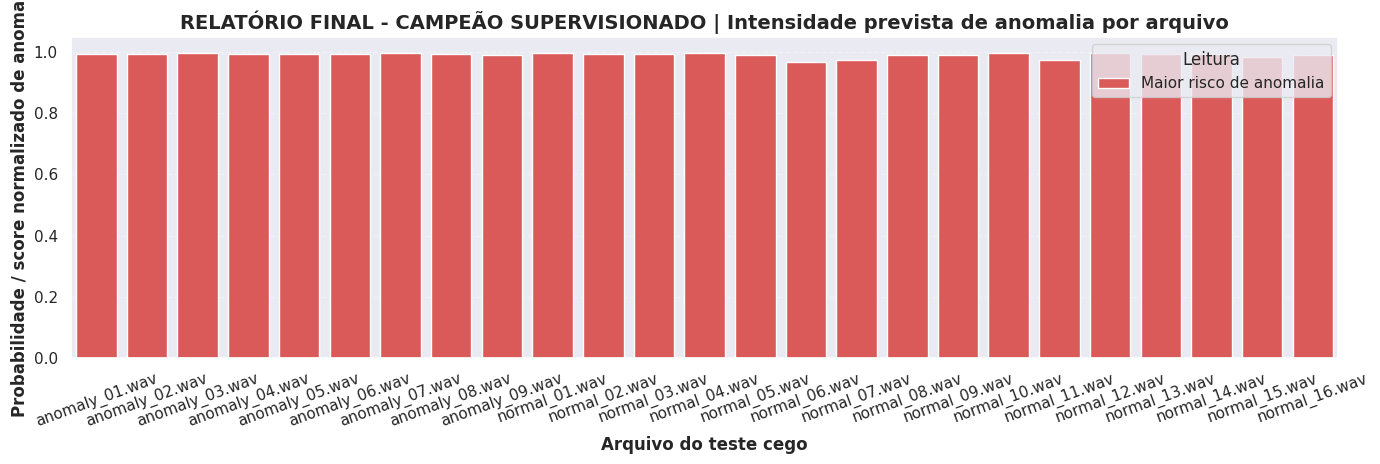


🧪 Frente 8.2 não foi promovida; a validação final seguirá com os não supervisionados anteriores.
🧪 Frente 8.3 não foi promovida; a validação final seguirá com a melhor seleção até a Frente 8.2.

🏆 Campeão não supervisionado: HHT + UKF | Mahalanobis (Não-Sup.) | Exp 4 (Híbrido Antigo) | Score DCASE Proxy=0.6236


Montando Exp 4 (Híbrido Antigo) para teste cego: 100%|██████████| 25/25 [00:09<00:00,  2.61fatia/s]

🛰️ Frente 7 | OE real inativo nesta configuração.

📏 Métricas no teste cego (RELATÓRIO FINAL - CAMPEÃO NÃO SUPERVISIONADO):
   Acurácia:          0.3600
   Precisão:          0.3600
   Recall:            1.0000
   F1-Score:          0.5294
   AUC-ROC:           0.4931
   pAUC@0.1 (proxy):  0.0417
   Score DCASE Proxy: 0.0768

 RELATÓRIO FINAL - CAMPEÃO NÃO SUPERVISIONADO
Métrica de seleção do campeão: Score DCASE Proxy
Frente DSP campeã: HHT + UKF
Experimento campeão: Exp 4 (Híbrido Antigo)
Modelo campeão: Mahalanobis (Não-Sup.)
Score de ranking: 0.6236
Limiar final: 11.464938 | Estratégia: max(gamma, empirical, mixup)
Gamma: 10.487763 | Empírico: 10.172638 | Mixup: 11.464938
FPR alvo: 0.10 | Gamma shape: 36.4764 | Gamma scale: 0.2362
------------------------------------------------------------------------
anomaly_01.wav: 🚨 ANOMALIA DETECTADA | Confiança: 43.98%
anomaly_02.wav: 🚨 ANOMALIA DETECTADA | Confiança: 51.27%
anomaly_03.wav: 🚨 ANOMALIA DETECTADA | Confiança: 96.40%
anomaly_04.

,Arquivo,Status,Confiança,Rótulo_Real
0,anomaly_01.wav,🚨 ANOMALIA DETECTADA,0.439822,1
1,anomaly_02.wav,🚨 ANOMALIA DETECTADA,0.512652,1
2,anomaly_03.wav,🚨 ANOMALIA DETECTADA,0.963999,1
3,anomaly_04.wav,🚨 ANOMALIA DETECTADA,0.479078,1
4,anomaly_05.wav,🚨 ANOMALIA DETECTADA,0.237683,1
5,anomaly_06.wav,🚨 ANOMALIA DETECTADA,0.793811,1
6,anomaly_07.wav,🚨 ANOMALIA DETECTADA,0.760492,1
7,anomaly_08.wav,🚨 ANOMALIA DETECTADA,0.587104,1
8,anomaly_09.wav,🚨 ANOMALIA DETECTADA,0.735200,1
9,normal_01.wav,🚨 ANOMALIA DETECTADA,0.471362,0


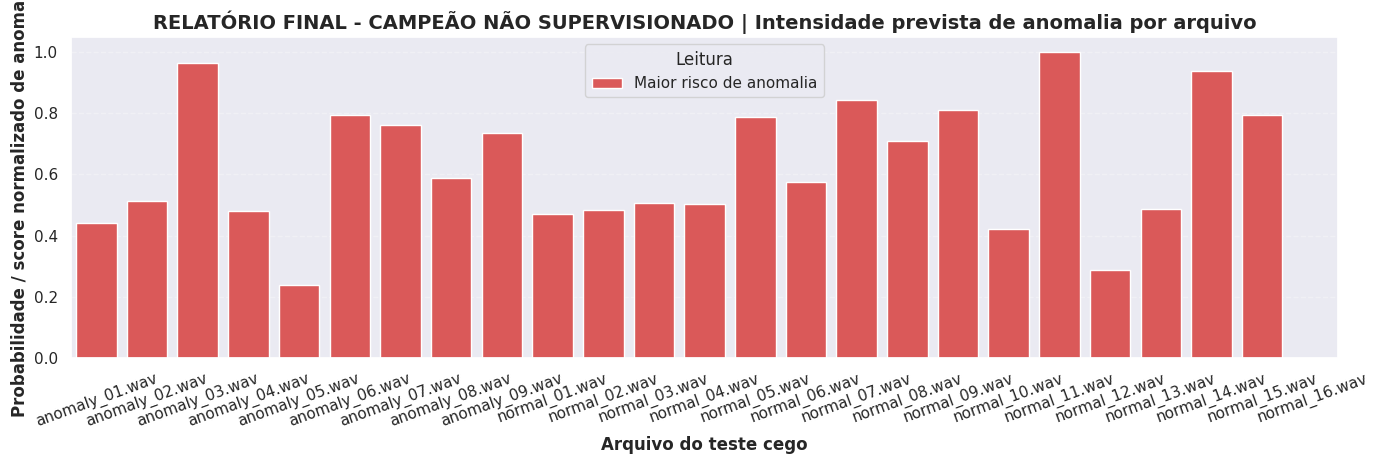

In [27]:
# 3. PASSO: Predição com os Modelos Campeões (Supervisionado e Não-Supervisionado)

MODELOS_SUPERVISIONADOS = globals().get('MODELOS_SUPERVISIONADOS', {'XGBoost', 'GRU'})
MODELOS_FRENTE8 = globals().get('MODELOS_FRENTE8', {'Isolation Forest (Não-Sup.)', 'Mahalanobis (Não-Sup.)'})
MODELOS_FRENTE82 = globals().get('MODELOS_FRENTE82', {'LSTM-AE (Não-Sup.)'})
MODELOS_FRENTE83 = globals().get('MODELOS_FRENTE83', {'VAE (Não-Sup.)'})
MODELOS_NAO_SUPERVISIONADOS = globals().get('MODELOS_NAO_SUPERVISIONADOS', {'GMM (Não-Sup.)', 'Tiny-AST', 'CNN + GMM (Não-Sup.)'} | MODELOS_FRENTE8 | MODELOS_FRENTE82 | MODELOS_FRENTE83)

device_validacao = device if 'device' in globals() else (get_best_device() if 'get_best_device' in globals() else torch.device('cpu'))
batch_validacao = int(globals().get('BATCH_SIZE', 16))
epochs_gru_validacao = int(globals().get('EPOCHS_GRU', 12))
epochs_ast_validacao = int(globals().get('EPOCHS_AST', 12))
embed_pool_validacao = int(globals().get('EMBED_POOL', 2))

if 'df_bench' not in globals():
    raise RuntimeError("Variável 'df_bench' não encontrada. Execute a célula do benchmarking antes desta validação final.")
if 'experimentos_por_frente' not in globals():
    raise RuntimeError("Variável 'experimentos_por_frente' não encontrada. Execute a etapa 1 antes desta validação final.")
if 'front_dataset_cache' not in globals():
    raise RuntimeError("Variável 'front_dataset_cache' não encontrada. Execute a etapa 1 antes desta validação final.")
if 'y_win' not in globals():
    raise RuntimeError("Variável 'y_win' não encontrada. Execute as células de preparação de dados antes desta validação final.")
if 'X_blind' not in globals() or len(X_blind) == 0:
    raise RuntimeError("A lista 'X_blind' está vazia. A pasta de teste precisa ser carregada antes da validação final.")
if df_bench.empty:
    raise RuntimeError("O DataFrame 'df_bench' está vazio. Nenhum modelo foi treinado com sucesso para a validação final.")

front_id_col = 'Frente DSP (ID)' if 'Frente DSP (ID)' in df_bench.columns else None
metrica_ranking_validacao = METRICA_RANKING_BENCHMARK if 'METRICA_RANKING_BENCHMARK' in globals() and METRICA_RANKING_BENCHMARK in df_bench.columns else 'F1-Score'

file_names_blind = blind_file_names if 'blind_file_names' in globals() and len(blind_file_names) == len(X_blind) else [f'Arquivo_{i + 1:02d}' for i in range(len(X_blind))]


def resolve_front_name_from_row(row):
    if front_id_col and front_id_col in row.index:
        return row[front_id_col]
    return globals().get('FRONT_DSP_REFERENCIA', globals().get('DSP_FRONT_ATIVO', 'hht'))


def resolve_front_label(front_name):
    return globals().get('DSP_FRONT_LABELS', {}).get(front_name, front_name)


def normalize_scores(scores):
    scores = np.asarray(scores, dtype=np.float32)
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)


def prepare_blind_dsp_signals(signals, front_name, sr=SR_TARGET):
    max_len = int(2.0 * sr)
    if 'process_signals_with_front' in globals():
        processed = process_signals_with_front(
            signals,
            front_name,
            sr=sr,
            max_len=max_len,
            desc_prefix='Preparando teste cego',
        )
        return [np.asarray(sig, dtype=np.float32) for sig in processed]

    blind_dsp = []
    dsp_func = globals().get('DSP_FRONT_OPTIONS', {}).get(front_name, apply_hht_denoising)

    for sig in tqdm(signals, desc=f"Preparando teste cego ({resolve_front_label(front_name)})", unit="arquivo"):
        try:
            signal_short = sig[:min(len(sig), max_len)].astype(np.float32)
            blind_dsp.append(np.asarray(dsp_func(signal_short, sr=sr), dtype=np.float32))
        except Exception:
            blind_dsp.append(sig[:min(len(sig), max_len)].astype(np.float32))

    return blind_dsp


def build_experiment_features(audio_segments, experiment_name, sr=SR_TARGET):
    if 'extract_all_experiment_features' not in globals():
        raise RuntimeError("Função 'extract_all_experiment_features' não encontrada. Execute a célula 10 antes da validação final.")

    features = []
    for audio_segment in tqdm(audio_segments, desc=f"Montando {experiment_name} para teste cego", unit="fatia"):
        feature_map = extract_all_experiment_features(audio_segment, sr=sr)
        features.append(feature_map[experiment_name])
    return np.array(features, dtype=np.float32)


def build_full_mixup_for_experiment(front_name, experiment_name):
    experimentos_front = experimentos_por_frente[front_name]
    reference = np.asarray(experimentos_front[experiment_name]['X'], dtype=np.float32)

    if not MIXUP_ENABLED:
        return np.empty((0,) + reference.shape[1:], dtype=np.float32)

    front_cache = front_dataset_cache.get(front_name)
    if front_cache is None:
        print(f"⚠️ Cache da frente {resolve_front_label(front_name)} não encontrado. O Mixup final será ignorado.")
        return np.empty((0,) + reference.shape[1:], dtype=np.float32)

    normal_signals = [
        np.asarray(sig, dtype=np.float32)
        for sig, label in zip(front_cache['signals'], front_cache['labels'])
        if int(label) == 0
    ]
    if len(normal_signals) == 0:
        return np.empty((0,) + reference.shape[1:], dtype=np.float32)

    X_norm_windows, _ = apply_sliding_window_to_list(
        normal_signals,
        np.zeros(len(normal_signals), dtype=np.int64),
        sr=SR_TARGET,
        window_size=2.0,
    )
    X_mix_audio_full, _, _ = create_mixup_dataset(
        X_norm_windows,
        sr=SR_TARGET,
        mixup_ratio=MIXUP_RATIO,
        alpha=MIXUP_ALPHA,
        max_samples=MIXUP_MAX_SAMPLES,
        seed=MIXUP_SEED + 101,
    )

    if len(X_mix_audio_full) == 0:
        return np.empty((0,) + reference.shape[1:], dtype=np.float32)
    return build_experiment_features(X_mix_audio_full, experiment_name, sr=SR_TARGET)


def resolve_unsupervised_models_for_final_validation():
    all_unsup = set(MODELOS_NAO_SUPERVISIONADOS)
    front82_models = set(MODELOS_FRENTE82)
    front83_models = set(MODELOS_FRENTE83)

    if 'MODELOS_NAO_SUPERVISIONADOS_VALIDACAO' in globals():
        return set(globals()['MODELOS_NAO_SUPERVISIONADOS_VALIDACAO'])

    metric = metrica_ranking_validacao
    selected = set(all_unsup) - front82_models - front83_models

    df_front82 = df_bench[df_bench['Modelo'].isin(front82_models)].sort_values(by=metric, ascending=False).head(1)
    df_previous_82 = df_bench[df_bench['Modelo'].isin(selected)].sort_values(by=metric, ascending=False).head(1)
    min_gain_82 = float(globals().get('FRONT82_MIN_GAIN', 0.0))

    if df_front82.empty:
        front82_promoted = False
        front82_delta = np.nan
    elif df_previous_82.empty:
        front82_promoted = True
        front82_delta = np.nan
    else:
        front82_delta = float(df_front82.iloc[0][metric] - df_previous_82.iloc[0][metric])
        front82_promoted = bool(front82_delta > min_gain_82)

    if front82_promoted:
        selected = set(selected) | front82_models

    df_front83 = df_bench[df_bench['Modelo'].isin(front83_models)].sort_values(by=metric, ascending=False).head(1)
    df_previous_83 = df_bench[df_bench['Modelo'].isin(selected)].sort_values(by=metric, ascending=False).head(1)
    min_gain_83 = float(globals().get('FRONT83_MIN_GAIN', 0.0))

    if df_front83.empty:
        front83_promoted = False
        front83_delta = np.nan
    elif df_previous_83.empty:
        front83_promoted = True
        front83_delta = np.nan
    else:
        front83_delta = float(df_front83.iloc[0][metric] - df_previous_83.iloc[0][metric])
        front83_promoted = bool(front83_delta > min_gain_83)

    if front83_promoted:
        selected = set(selected) | front83_models

    globals()['FRONT82_PROMOTED'] = bool(front82_promoted)
    globals()['FRONT82_DELTA_SCORE'] = float(front82_delta) if np.isfinite(front82_delta) else np.nan
    globals()['FRONT83_PROMOTED'] = bool(front83_promoted)
    globals()['FRONT83_DELTA_SCORE'] = float(front83_delta) if np.isfinite(front83_delta) else np.nan
    globals()['MODELOS_NAO_SUPERVISIONADOS_VALIDACAO'] = selected
    return selected


def fit_final_model(best_row):
    front_name = resolve_front_name_from_row(best_row)
    front_label = resolve_front_label(front_name)
    experimentos_front = experimentos_por_frente[front_name]
    best_exp_name = best_row['Experimento']
    best_model_type = best_row['Modelo']
    best_X_data = np.asarray(experimentos_front[best_exp_name]['X'], dtype=np.float32)
    best_mixup_full = build_full_mixup_for_experiment(front_name, best_exp_name)
    best_oe_real_full = np.asarray(
        experimentos_front[best_exp_name].get('X_oe_real_train', np.empty((0,), dtype=np.float32)),
        dtype=np.float32,
    )

    if best_model_type == 'XGBoost':
        X_sup, y_sup = merge_supervised_mixup(best_X_data, y_win, best_mixup_full)
        modelo = XGBClassifier(
            n_estimators=120,
            max_depth=4,
            learning_rate=0.08,
            random_state=42,
            n_jobs=CPU_THREADS,
            tree_method='hist',
            eval_metric='logloss'
        )
        modelo.fit(X_sup, y_sup)
        return {'tipo': best_model_type, 'experimento': best_exp_name, 'modelo': modelo, 'front_name': front_name, 'front_label': front_label}

    if best_model_type == 'GRU':
        X_seq = np.ascontiguousarray(best_X_data.squeeze(1))
        X_mix_seq = np.ascontiguousarray(best_mixup_full.squeeze(1)) if len(best_mixup_full) > 0 else np.empty((0,) + X_seq.shape[1:], dtype=np.float32)
        X_sup, y_sup = merge_supervised_mixup(X_seq, y_win, X_mix_seq)
        modelo = AnomalyGRU(input_dim=64, hidden_dim=64, num_layers=1, output_dim=2).to(device_validacao)
        opt = optim.Adam(modelo.parameters(), lr=0.005, weight_decay=1e-4)
        crit = nn.CrossEntropyLoss()
        loader = DataLoader(
            TensorDataset(torch.from_numpy(X_sup), torch.from_numpy(y_sup.astype(np.int64))),
            batch_size=batch_validacao,
            shuffle=True
        )

        modelo.train()
        for _ in range(epochs_gru_validacao):
            for batch_x, batch_y in loader:
                batch_x = batch_x.to(device_validacao)
                batch_y = batch_y.to(device_validacao)
                opt.zero_grad()
                logits = modelo(batch_x)
                loss = crit(logits, batch_y)
                loss.backward()
                opt.step()

        return {'tipo': best_model_type, 'experimento': best_exp_name, 'modelo': modelo, 'front_name': front_name, 'front_label': front_label}

    if best_model_type == 'GMM (Não-Sup.)':
        X_norm = best_X_data[y_win == 0]
        if len(X_norm) == 0:
            raise RuntimeError(f"Sem amostras normais para treinar o campeão não supervisionado em {best_exp_name}.")
        gmm = GaussianMixture(n_components=3, covariance_type='diag', reg_covar=1e-6, random_state=42)
        gmm.fit(X_norm)
        scores_train = -gmm.score_samples(X_norm)
        scores_mix = -gmm.score_samples(best_mixup_full) if len(best_mixup_full) > 0 else np.empty((0,), dtype=np.float32)
        scores_oe = -gmm.score_samples(best_oe_real_full) if len(best_oe_real_full) > 0 else np.empty((0,), dtype=np.float32)
        exposure_scores, exposure_label = merge_auxiliary_exposure_scores(
            ('mixup', scores_mix),
            ('oe_real', scores_oe),
        )
        threshold_info = compose_strict_threshold(
            scores_train,
            exposure_scores,
            target_fpr=THRESHOLD_TARGET_FPR,
            pseudo_label=exposure_label,
        )
        return {
            'tipo': best_model_type,
            'experimento': best_exp_name,
            'modelo': gmm,
            'threshold': threshold_info['threshold'],
            'threshold_info': threshold_info,
            'front_name': front_name,
            'front_label': front_label,
        }

    if best_model_type == 'Isolation Forest (Não-Sup.)':
        X_norm = best_X_data[y_win == 0]
        if len(X_norm) == 0:
            raise RuntimeError(f"Sem amostras normais para treinar o campeão não supervisionado em {best_exp_name}.")
        iso = IsolationForest(
            n_estimators=int(globals().get('FRONT8_IFOREST_TREES', 160)),
            contamination='auto',
            random_state=42,
            n_jobs=CPU_THREADS,
        )
        iso.fit(X_norm)
        scores_train = -iso.score_samples(X_norm)
        scores_mix = -iso.score_samples(best_mixup_full) if len(best_mixup_full) > 0 else np.empty((0,), dtype=np.float32)
        scores_oe = -iso.score_samples(best_oe_real_full) if len(best_oe_real_full) > 0 else np.empty((0,), dtype=np.float32)
        exposure_scores, exposure_label = merge_auxiliary_exposure_scores(
            ('mixup', scores_mix),
            ('oe_real', scores_oe),
        )
        threshold_info = compose_strict_threshold(
            scores_train,
            exposure_scores,
            target_fpr=THRESHOLD_TARGET_FPR,
            pseudo_label=exposure_label,
        )
        return {
            'tipo': best_model_type,
            'experimento': best_exp_name,
            'modelo': iso,
            'threshold': threshold_info['threshold'],
            'threshold_info': threshold_info,
            'front_name': front_name,
            'front_label': front_label,
        }

    if best_model_type == 'Mahalanobis (Não-Sup.)':
        X_norm = best_X_data[y_win == 0]
        if len(X_norm) == 0:
            raise RuntimeError(f"Sem amostras normais para treinar o campeão não supervisionado em {best_exp_name}.")
        mean_vec, precision = fit_mahalanobis_reference(
            X_norm,
            reg=float(globals().get('FRONT8_MAHAL_REG', 1e-3)),
        )
        scores_train = mahalanobis_scores(X_norm, mean_vec, precision)
        scores_mix = mahalanobis_scores(best_mixup_full, mean_vec, precision) if len(best_mixup_full) > 0 else np.empty((0,), dtype=np.float32)
        scores_oe = mahalanobis_scores(best_oe_real_full, mean_vec, precision) if len(best_oe_real_full) > 0 else np.empty((0,), dtype=np.float32)
        exposure_scores, exposure_label = merge_auxiliary_exposure_scores(
            ('mixup', scores_mix),
            ('oe_real', scores_oe),
        )
        threshold_info = compose_strict_threshold(
            scores_train,
            exposure_scores,
            target_fpr=THRESHOLD_TARGET_FPR,
            pseudo_label=exposure_label,
        )
        return {
            'tipo': best_model_type,
            'experimento': best_exp_name,
            'mean_vec': mean_vec,
            'precision': precision,
            'threshold': threshold_info['threshold'],
            'threshold_info': threshold_info,
            'front_name': front_name,
            'front_label': front_label,
        }

    if best_model_type == 'LSTM-AE (Não-Sup.)':
        X_norm_img = np.ascontiguousarray(best_X_data[y_win == 0])
        if len(X_norm_img) == 0:
            raise RuntimeError(f"Sem amostras normais para treinar o campeão não supervisionado em {best_exp_name}.")
        X_norm_seq = np.ascontiguousarray(X_norm_img.squeeze(1))
        X_mix_seq = np.ascontiguousarray(best_mixup_full.squeeze(1)) if len(best_mixup_full) > 0 else np.empty((0,) + X_norm_seq.shape[1:], dtype=np.float32)
        X_oe_seq = np.ascontiguousarray(best_oe_real_full.squeeze(1)) if len(best_oe_real_full) > 0 else np.empty((0,) + X_norm_seq.shape[1:], dtype=np.float32)

        modelo = LSTMAE(
            input_dim=X_norm_seq.shape[-1],
            hidden_dim=int(globals().get('FRONT82_LSTM_HIDDEN', 64)),
            num_layers=int(globals().get('FRONT82_LSTM_LAYERS', 1)),
        ).to(device_validacao)
        modelo = train_lstm_autoencoder(
            modelo,
            X_norm_seq,
            X_oe_real=X_oe_seq if len(X_oe_seq) > 0 else None,
            batch_size=batch_validacao,
            epochs=int(globals().get('FRONT82_EPOCHS', 8)),
            device=device_validacao,
            lr=0.001,
            weight_decay=1e-4,
            oe_weight=globals().get('OE_REAL_LOSS_WEIGHT', 0.15) if len(X_oe_seq) > 0 else 0.0,
            oe_margin=globals().get('OE_REAL_MARGIN', 0.08),
        )

        err_tr = reconstruction_errors_lstm(modelo, X_norm_seq, batch_validacao, device_validacao)
        err_mix = reconstruction_errors_lstm(modelo, X_mix_seq, batch_validacao, device_validacao) if len(X_mix_seq) > 0 else np.empty((0,), dtype=np.float32)
        err_oe = reconstruction_errors_lstm(modelo, X_oe_seq, batch_validacao, device_validacao) if len(X_oe_seq) > 0 else np.empty((0,), dtype=np.float32)
        exposure_scores, exposure_label = merge_auxiliary_exposure_scores(
            ('mixup', err_mix),
            ('oe_real', err_oe),
        )
        threshold_info = compose_strict_threshold(
            err_tr,
            exposure_scores,
            target_fpr=THRESHOLD_TARGET_FPR,
            pseudo_label=exposure_label,
        )
        return {
            'tipo': best_model_type,
            'experimento': best_exp_name,
            'modelo': modelo,
            'threshold': threshold_info['threshold'],
            'threshold_info': threshold_info,
            'front_name': front_name,
            'front_label': front_label,
        }

    if best_model_type == 'VAE (Não-Sup.)':
        X_norm = np.ascontiguousarray(best_X_data[y_win == 0])
        if len(X_norm) == 0:
            raise RuntimeError(f"Sem amostras normais para treinar o campeão não supervisionado em {best_exp_name}.")

        modelo = ConvVAE(
            input_channels=int(X_norm.shape[1]),
            input_h=int(X_norm.shape[-2]),
            input_w=int(X_norm.shape[-1]),
            latent_dim=int(globals().get('FRONT83_LATENT_DIM', 24)),
            base_channels=16,
        ).to(device_validacao)
        modelo = train_vae_autoencoder(
            modelo,
            X_norm,
            X_oe_real=np.ascontiguousarray(best_oe_real_full) if len(best_oe_real_full) > 0 else None,
            batch_size=batch_validacao,
            epochs=int(globals().get('FRONT83_EPOCHS', 6)),
            device=device_validacao,
            lr=0.001,
            weight_decay=1e-4,
            beta=float(globals().get('FRONT83_BETA', 0.002)),
            oe_weight=globals().get('OE_REAL_LOSS_WEIGHT', 0.15) if len(best_oe_real_full) > 0 else 0.0,
            oe_margin=globals().get('OE_REAL_MARGIN', 0.08),
        )

        err_tr = reconstruction_errors_vae(modelo, X_norm, batch_validacao, device_validacao)
        err_mix = reconstruction_errors_vae(modelo, np.ascontiguousarray(best_mixup_full), batch_validacao, device_validacao) if len(best_mixup_full) > 0 else np.empty((0,), dtype=np.float32)
        err_oe = reconstruction_errors_vae(modelo, np.ascontiguousarray(best_oe_real_full), batch_validacao, device_validacao) if len(best_oe_real_full) > 0 else np.empty((0,), dtype=np.float32)
        exposure_scores, exposure_label = merge_auxiliary_exposure_scores(
            ('mixup', err_mix),
            ('oe_real', err_oe),
        )
        threshold_info = compose_strict_threshold(
            err_tr,
            exposure_scores,
            target_fpr=THRESHOLD_TARGET_FPR,
            pseudo_label=exposure_label,
        )
        return {
            'tipo': best_model_type,
            'experimento': best_exp_name,
            'modelo': modelo,
            'threshold': threshold_info['threshold'],
            'threshold_info': threshold_info,
            'front_name': front_name,
            'front_label': front_label,
        }

    if best_model_type == 'Tiny-AST':
        X_norm = np.ascontiguousarray(best_X_data[y_win == 0])
        if len(X_norm) == 0:
            raise RuntimeError(f"Sem amostras normais para treinar o campeão não supervisionado em {best_exp_name}.")

        modelo = TinyAST(num_mels=64, time_steps=64).to(device_validacao)
        modelo = train_tinyast_autoencoder(
            modelo,
            X_norm,
            X_oe_real=np.ascontiguousarray(best_oe_real_full) if len(best_oe_real_full) > 0 else None,
            batch_size=batch_validacao,
            epochs=epochs_ast_validacao,
            device=device_validacao,
            lr=0.001,
            weight_decay=1e-4,
            oe_weight=globals().get('OE_REAL_LOSS_WEIGHT', 0.15) if len(best_oe_real_full) > 0 else 0.0,
            oe_margin=globals().get('OE_REAL_MARGIN', 0.08),
        )

        err_tr = reconstruction_errors(modelo, X_norm, batch_validacao, device_validacao)
        err_mix = reconstruction_errors(modelo, np.ascontiguousarray(best_mixup_full), batch_validacao, device_validacao) if len(best_mixup_full) > 0 else np.empty((0,), dtype=np.float32)
        err_oe = reconstruction_errors(modelo, np.ascontiguousarray(best_oe_real_full), batch_validacao, device_validacao) if len(best_oe_real_full) > 0 else np.empty((0,), dtype=np.float32)
        exposure_scores, exposure_label = merge_auxiliary_exposure_scores(
            ('mixup', err_mix),
            ('oe_real', err_oe),
        )
        threshold_info = compose_strict_threshold(
            err_tr,
            exposure_scores,
            target_fpr=THRESHOLD_TARGET_FPR,
            pseudo_label=exposure_label,
        )
        return {
            'tipo': best_model_type,
            'experimento': best_exp_name,
            'modelo': modelo,
            'threshold': threshold_info['threshold'],
            'threshold_info': threshold_info,
            'front_name': front_name,
            'front_label': front_label,
        }

    if best_model_type == 'CNN + GMM (Não-Sup.)':
        X_norm = np.ascontiguousarray(best_X_data[y_win == 0])
        if len(X_norm) == 0:
            raise RuntimeError(f"Sem amostras normais para treinar o campeão não supervisionado em {best_exp_name}.")

        encoder_model = TinyAST(num_mels=64, time_steps=64).to(device_validacao)
        encoder_model = train_tinyast_autoencoder(
            encoder_model,
            X_norm,
            X_oe_real=np.ascontiguousarray(best_oe_real_full) if len(best_oe_real_full) > 0 else None,
            batch_size=batch_validacao,
            epochs=epochs_ast_validacao,
            device=device_validacao,
            lr=0.001,
            weight_decay=1e-4,
            oe_weight=globals().get('OE_REAL_LOSS_WEIGHT', 0.15) if len(best_oe_real_full) > 0 else 0.0,
            oe_margin=globals().get('OE_REAL_MARGIN', 0.08),
        )

        embeds_train = extract_embeddings(encoder_model, X_norm, batch_validacao, device_validacao, embed_pool_validacao)
        gmm = GaussianMixture(n_components=3, covariance_type='diag', reg_covar=1e-6, random_state=42)
        gmm.fit(embeds_train)
        scores_train = -gmm.score_samples(embeds_train)

        if len(best_mixup_full) > 0:
            embeds_mix = extract_embeddings(encoder_model, np.ascontiguousarray(best_mixup_full), batch_validacao, device_validacao, embed_pool_validacao)
            scores_mix = -gmm.score_samples(embeds_mix)
        else:
            scores_mix = np.empty((0,), dtype=np.float32)

        if len(best_oe_real_full) > 0:
            embeds_oe = extract_embeddings(encoder_model, np.ascontiguousarray(best_oe_real_full), batch_validacao, device_validacao, embed_pool_validacao)
            scores_oe = -gmm.score_samples(embeds_oe)
        else:
            scores_oe = np.empty((0,), dtype=np.float32)

        exposure_scores, exposure_label = merge_auxiliary_exposure_scores(
            ('mixup', scores_mix),
            ('oe_real', scores_oe),
        )
        threshold_info = compose_strict_threshold(
            scores_train,
            exposure_scores,
            target_fpr=THRESHOLD_TARGET_FPR,
            pseudo_label=exposure_label,
        )
        return {
            'tipo': best_model_type,
            'experimento': best_exp_name,
            'modelo': encoder_model,
            'gmm': gmm,
            'threshold': threshold_info['threshold'],
            'threshold_info': threshold_info,
            'front_name': front_name,
            'front_label': front_label,
        }

    raise ValueError(f"Modelo campeão '{best_model_type}' não suportado para validação final.")


def predict_with_final_model(artefato, X_blind_final):
    model_type = artefato['tipo']

    if model_type == 'XGBoost':
        preds = artefato['modelo'].predict(X_blind_final)
        probs = artefato['modelo'].predict_proba(X_blind_final)[:, 1]
        return preds, probs

    if model_type == 'GRU':
        X_seq = np.ascontiguousarray(X_blind_final.squeeze(1))
        return predict_gru_batches(artefato['modelo'], X_seq, batch_validacao, device_validacao)

    if model_type == 'GMM (Não-Sup.)':
        scores = -artefato['modelo'].score_samples(X_blind_final)
        preds = (scores > artefato['threshold']).astype(int)
        probs = normalize_scores(scores)
        return preds, probs

    if model_type == 'Isolation Forest (Não-Sup.)':
        scores = -artefato['modelo'].score_samples(X_blind_final)
        preds = (scores > artefato['threshold']).astype(int)
        probs = normalize_scores(scores)
        return preds, probs

    if model_type == 'Mahalanobis (Não-Sup.)':
        scores = mahalanobis_scores(X_blind_final, artefato['mean_vec'], artefato['precision'])
        preds = (scores > artefato['threshold']).astype(int)
        probs = normalize_scores(scores)
        return preds, probs

    if model_type == 'LSTM-AE (Não-Sup.)':
        X_seq = np.ascontiguousarray(X_blind_final.squeeze(1))
        errs = reconstruction_errors_lstm(artefato['modelo'], X_seq, batch_validacao, device_validacao)
        preds = (errs > artefato['threshold']).astype(int)
        probs = normalize_scores(errs)
        return preds, probs

    if model_type == 'VAE (Não-Sup.)':
        errs = reconstruction_errors_vae(artefato['modelo'], np.ascontiguousarray(X_blind_final), batch_validacao, device_validacao)
        preds = (errs > artefato['threshold']).astype(int)
        probs = normalize_scores(errs)
        return preds, probs

    if model_type == 'Tiny-AST':
        errs = reconstruction_errors(artefato['modelo'], np.ascontiguousarray(X_blind_final), batch_validacao, device_validacao)
        preds = (errs > artefato['threshold']).astype(int)
        probs = normalize_scores(errs)
        return preds, probs

    if model_type == 'CNN + GMM (Não-Sup.)':
        embeds = extract_embeddings(artefato['modelo'], np.ascontiguousarray(X_blind_final), batch_validacao, device_validacao, embed_pool_validacao)
        scores = -artefato['gmm'].score_samples(embeds)
        preds = (scores > artefato['threshold']).astype(int)
        probs = normalize_scores(scores)
        return preds, probs

    raise ValueError(f"Predição não suportada para o modelo '{model_type}'.")


def report_predictions(titulo, best_row, artefato, preds, probs):
    df_relatorio = pd.DataFrame({
        'Arquivo': file_names_blind,
        'Predição': preds,
        'Confiança_Anomalia': probs,
    })
    df_relatorio['Status'] = np.where(df_relatorio['Predição'] == 1, '🚨 ANOMALIA DETECTADA', '✅ OPERAÇÃO NORMAL')
    df_relatorio['Confiança'] = np.where(
        df_relatorio['Predição'] == 1,
        df_relatorio['Confiança_Anomalia'],
        1 - df_relatorio['Confiança_Anomalia']
    )

    if 'OE real ativo' in best_row.index:
        print(f"🛰️ Frente 7 | OE real {'ATIVO' if bool(best_row['OE real ativo']) else 'inativo'} nesta configuração.")

    if 'y_blind' in globals() and len(y_blind) == len(df_relatorio):
        blind_auc = roc_auc_score(y_blind, probs) if len(np.unique(y_blind)) > 1 else 0.0
        blind_pauc = calc_dcase_pauc(y_blind, probs, max_fpr=0.1) if len(np.unique(y_blind)) > 1 else 0.0
        blind_proxy = harmonic_mean_safe([max(blind_auc, 1e-9), max(blind_pauc, 1e-9)])
        df_relatorio['Rótulo_Real'] = y_blind
        print(f"\n📏 Métricas no teste cego ({titulo}):")
        print(f"   Acurácia:          {accuracy_score(y_blind, preds):.4f}")
        print(f"   Precisão:          {precision_score(y_blind, preds, zero_division=0):.4f}")
        print(f"   Recall:            {recall_score(y_blind, preds, zero_division=0):.4f}")
        print(f"   F1-Score:          {f1_score(y_blind, preds, zero_division=0):.4f}")
        print(f"   AUC-ROC:           {blind_auc:.4f}")
        print(f"   pAUC@0.1 (proxy):  {blind_pauc:.4f}")
        print(f"   Score DCASE Proxy: {blind_proxy:.4f}")

    print("\n" + "=" * 72)
    print(f" {titulo}")
    print("=" * 72)
    print(f"Métrica de seleção do campeão: {metrica_ranking_validacao}")
    print(f"Frente DSP campeã: {artefato.get('front_label', resolve_front_label(resolve_front_name_from_row(best_row)))}")
    print(f"Experimento campeão: {best_row['Experimento']}")
    print(f"Modelo campeão: {best_row['Modelo']}")
    print(f"Score de ranking: {best_row[metrica_ranking_validacao]:.4f}")
    if 'threshold_info' in artefato:
        tinfo = artefato['threshold_info']
        print(f"Limiar final: {tinfo['threshold']:.6f} | Estratégia: {tinfo['strategy']}")
        print(f"Gamma: {tinfo['gamma_threshold']:.6f} | Empírico: {tinfo['empirical_threshold']:.6f} | Mixup: {tinfo['mixup_threshold'] if np.isfinite(tinfo['mixup_threshold']) else float('nan'):.6f}")
        print(f"FPR alvo: {tinfo['target_fpr']:.2f} | Gamma shape: {tinfo['gamma_shape']:.4f} | Gamma scale: {tinfo['gamma_scale']:.4f}")
    print("-" * 72)
    for _, row in df_relatorio.iterrows():
        print(f"{row['Arquivo']}: {row['Status']} | Confiança: {row['Confiança']:.2%}")
    print("=" * 72)

    display(df_relatorio[['Arquivo', 'Status', 'Confiança'] + (['Rótulo_Real'] if 'Rótulo_Real' in df_relatorio.columns else [])])

    fig, ax = plt.subplots(figsize=(14, 4.8))
    df_plot = df_relatorio.copy()
    df_plot['Leitura'] = np.where(df_plot['Predição'] == 1, 'Maior risco de anomalia', 'Maior proximidade de normalidade')
    sns.barplot(
        data=df_plot,
        x='Arquivo',
        y='Confiança_Anomalia',
        hue='Leitura',
        palette={'Maior risco de anomalia': '#ef4444', 'Maior proximidade de normalidade': '#22c55e'},
        ax=ax,
    )
    ax.set_title(f'{titulo} | Intensidade prevista de anomalia por arquivo', fontsize=14, fontweight='bold')
    ax.set_xlabel('Arquivo do teste cego', fontweight='bold')
    ax.set_ylabel('Probabilidade / score normalizado de anomalia', fontweight='bold')
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, axis='y', linestyle='--', alpha=0.30)
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()
    return df_relatorio


print("\n⚙️ Preparando o teste cego para os modelos campeões...")
blind_dsp_cache = {}
blind_window_cache = {}
blind_feature_cache = {}

def get_blind_base_for_front(front_name):
    if front_name not in blind_window_cache:
        blind_dsp_cache[front_name] = prepare_blind_dsp_signals(X_blind, front_name, sr=SR_TARGET)
        blind_window_cache[front_name], _ = apply_sliding_window_to_list(
            blind_dsp_cache[front_name],
            np.zeros(len(blind_dsp_cache[front_name]), dtype=np.int64),
            sr=SR_TARGET,
            window_size=2.0
        )
    return blind_window_cache[front_name]


def get_blind_matrix_for_experiment(front_name, exp_name):
    cache_key = (front_name, exp_name)
    if cache_key not in blind_feature_cache:
        blind_feature_cache[cache_key] = build_experiment_features(get_blind_base_for_front(front_name), exp_name, sr=SR_TARGET)
    return blind_feature_cache[cache_key]


MODELOS_NAO_SUPERVISIONADOS_VALIDACAO = resolve_unsupervised_models_for_final_validation()
campeao_supervisionado = df_bench[df_bench['Modelo'].isin(MODELOS_SUPERVISIONADOS)].sort_values(by=metrica_ranking_validacao, ascending=False).head(1)
campeao_nao_supervisionado = df_bench[df_bench['Modelo'].isin(MODELOS_NAO_SUPERVISIONADOS_VALIDACAO)].sort_values(by=metrica_ranking_validacao, ascending=False).head(1)

if campeao_supervisionado.empty:
    print("\n⚠️ Nenhum campeão supervisionado foi encontrado em df_bench.")
else:
    best_sup = campeao_supervisionado.iloc[0]
    front_sup = resolve_front_name_from_row(best_sup)
    print(f"\n🏆 Campeão supervisionado: {resolve_front_label(front_sup)} | {best_sup['Modelo']} | {best_sup['Experimento']} | {metrica_ranking_validacao}={best_sup[metrica_ranking_validacao]:.4f}")
    artefato_sup = fit_final_model(best_sup)
    X_blind_sup = get_blind_matrix_for_experiment(front_sup, best_sup['Experimento'])
    preds_sup, probs_sup = predict_with_final_model(artefato_sup, X_blind_sup)
    df_validacao_supervisionado = report_predictions("RELATÓRIO FINAL - CAMPEÃO SUPERVISIONADO", best_sup, artefato_sup, preds_sup, probs_sup)

if campeao_nao_supervisionado.empty:
    print("\n⚠️ Nenhum campeão não supervisionado foi encontrado em df_bench.")
else:
    best_unsup = campeao_nao_supervisionado.iloc[0]
    front_unsup = resolve_front_name_from_row(best_unsup)
    if bool(globals().get('FRONT82_PROMOTED', False)):
        print("\n🧪 Frente 8.2 foi PROMOVIDA para a validação final nesta execução.")
    elif len(MODELOS_FRENTE82) > 0:
        print("\n🧪 Frente 8.2 não foi promovida; a validação final seguirá com os não supervisionados anteriores.")
    if bool(globals().get('FRONT83_PROMOTED', False)):
        print("🧪 Frente 8.3 foi PROMOVIDA para a validação final nesta execução.")
    elif len(MODELOS_FRENTE83) > 0:
        print("🧪 Frente 8.3 não foi promovida; a validação final seguirá com a melhor seleção até a Frente 8.2.")
    print(f"\n🏆 Campeão não supervisionado: {resolve_front_label(front_unsup)} | {best_unsup['Modelo']} | {best_unsup['Experimento']} | {metrica_ranking_validacao}={best_unsup[metrica_ranking_validacao]:.4f}")
    artefato_unsup = fit_final_model(best_unsup)
    X_blind_unsup = get_blind_matrix_for_experiment(front_unsup, best_unsup['Experimento'])
    preds_unsup, probs_unsup = predict_with_final_model(artefato_unsup, X_blind_unsup)
    df_validacao_nao_supervisionado = report_predictions("RELATÓRIO FINAL - CAMPEÃO NÃO SUPERVISIONADO", best_unsup, artefato_unsup, preds_unsup, probs_unsup)
